In [1]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'
from matplotlib import pyplot as plt

from joblib import load
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import re

import os
from tqdm import tqdm 

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_act import ADModel_act
from ADModel_abund import ADModel_abund
from ADModel_three_state import ADModel_three_state_abund
from ADModel_two_state import ADModel_two_state_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode


os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [2]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['pdf.fonttype'] = 42

In [3]:
simple_model_results = pd.read_csv('results/results_simple_abund_test_LeakyReLU.csv')
simple_model_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  simple_model_results["model_name"]]

bootstrap_results = pd.read_csv('results/results_simple_abund_bootstraps_leakyrelu.csv')
bootstrap_results['bootstrap_number'] = [int(re.search("BOOTSTRAP_(\d+)", model.removeprefix("../../"))[1]) for model in  bootstrap_results["model_name"]]
bootstrap_results['seed'] = [int(re.search("seed(\d+)", model.removeprefix("../../"))[1]) for model in  bootstrap_results["model_name"]]


In [4]:
# Running the two-state biophysical model on the data

# Biophysical model parameters
size = (1,40,20)
hill_value = 1
relu = False
# relu = True
outchannel = 1

# Function to read in weights
def load_model_get_weights(row, layer1='conv1.weight', layer2="linear1.weight", two_state=False, abund_k = False): 
    """
    Parameters
    ----------

    row : row of results data frame
    layer1 : name of convolutional layer
    layer2 : name of linear layer
    two_state : whether this is a simple or two state model (TO DO: ADD abundance)
    abund_k : if this is two state, whether we are reading in the abundance weights
    """

    model = row["model_name"].removeprefix("../../")
    kernel_size = row["kernel_size"]

    if two_state: 
        abund_k_two = row["abund_k"]
        activity_fun = row["activity_fun"]
        loaded_model = ADModel_two_state_abund(size,activity_fun, kernel_size, relu=relu, abund_k=abund_k_two)
    else: 
        loaded_model = ADModel_abund(size, kernel_size)
    loaded_model.load_state_dict(torch.load(f"{model}.pth"))

    loaded_model.eval()
    model_state_dict = loaded_model.state_dict()
    width = model_state_dict[layer1].shape[0] * model_state_dict[layer1].shape[2]
    conv_weight = model_state_dict[layer1].detach().numpy().reshape(width,20)

    if abund_k:
        linear_weights_size = (40 - abund_k_two + 1)
    else:
        linear_weights_size = (40 - kernel_size + 1)
    linear_weights = model_state_dict[layer2].detach().numpy().reshape(linear_weights_size)

    return loaded_model, conv_weight, linear_weights

def get_weights_array(results_table, k_size, num_bootstraps=25, num_seeds=30, two_state=False, layer1=None, layer2=None, abund_k=False):
    """
    After we read in our weights, we want to store them in a numpy array where:
    - first dimension = number of shuffles
    - second dimension = number of seeds
    - third/fourth dimension = shape of the weights
    """

    # Defining our table of interest: If we want to look at the abundance weights
    if abund_k:
        index_col = 'abund_k'
    else:
        index_col = 'kernel_size'
    results_table = results_table[results_table[index_col] == k_size].copy()
    
    # Creating arrays to save weights
    conv_weight_arr = np.zeros((num_bootstraps, num_seeds, k_size, 20))
    linear_weight_arr = np.zeros((num_bootstraps, num_seeds, (40 - k_size + 1)))

    # If there is more than one bootstrap (i.e. not real weights), sort by bootstrap number and seed
    # Else sort by seeds
    if num_bootstraps > 1:
        results_table = results_table.sort_values(["seed", "bootstrap_number"]).reset_index()
    else:
        results_table = results_table.sort_values("seed").reset_index()

    # Assign an index to each seed
    seeds_dict = {s : i for i, s in enumerate(results_table['seed'].unique())}

    # Loop through every model in the table of the correct size
    for index in tqdm(results_table.index):

        # Get correct row
        row = results_table.loc[index]
        
        # Check if there is a bootstrap column
        if num_bootstraps > 1:    
            shuffle_number = row['bootstrap_number']
        else:
            shuffle_number = 1
        
        if shuffle_number > num_bootstraps:
            print("here")
            break

        # Get seed index
        seed_index = seeds_dict[row['seed']]
        
        # Default to conv1 and linear1
        if (layer1 == None) and (layer2 == None):
            _, weights, linear_weights = load_model_get_weights(row, two_state=two_state)

        # Can pass specific layers
        else:
            _, weights, linear_weights = load_model_get_weights(row, layer1, layer2, two_state=two_state, abund_k=abund_k)

        # Save in the correct array 
        # First dim : bootstrap
        # Second dim : Seed
        # Third/fourth dim : Weights
        conv_weight_arr[shuffle_number -1, seed_index, :, :] = weights #.reshape(100, )
        linear_weight_arr[shuffle_number - 1, seed_index, :] = linear_weights

    return conv_weight_arr, linear_weight_arr

# Need to define our test statistics

# A. Cosine similarity between weights
# def cosine_similarity(shuffled_conv_arr, real_conv_arr, real_linear_arr):
#     num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
#     # aa_num = 1

#     num_iterations = int(num_seeds * (num_seeds-1) / 2)
#     shuffle_cos_similarities = np.zeros((num_shuffles, num_iterations, aa_nums))
    

#     for aa in range(aa_nums): 
#         for shuffle_num in range(num_shuffles):
#             a = 0
#             for i in range(num_seeds - 1):
#                 for j in range(i+1, num_seeds):
#                     vector1 = shuffled_conv_arr[shuffle_num, i, :, aa]#.flatten()
#                     vector2 = shuffled_conv_arr[shuffle_num, j, :, aa]#.flatten()
                    
#                     sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
#                     shuffle_cos_similarities[shuffle_num, a, aa] = sim
#                     a += 1


#     similarities_real = np.zeros((1, 435, aa_nums))

#     # Which seeds had negative weights
#     neg_weight_filter = (real_linear_arr > 0).all(axis=2)

#     # Options: Flip sign or analyze separately
#     real_conv_arr_flipped = real_conv_arr.copy()
#     real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]

#     for aa in range(aa_nums): 
#         a=0
#         for i in range(num_seeds - 1):
#             for j in range(i+1, num_seeds):
#                 vector1 = real_conv_arr_flipped[0, i, :, aa] #.flatten()
#                 vector2 = real_conv_arr_flipped[0, j, :, aa] #.flatten()
                
#                 sim = np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))  
#                 similarities_real[0, a, aa] = sim
#                 a+=1
        
#     return shuffle_cos_similarities, similarities_real


# B. Sum of weights
def weight_sum(shuffled_conv_arr, real_conv_arr, real_linear_arr):
    num_shuffles, num_seeds, kernel_size, aa_nums = shuffled_conv_arr.shape
    # aa_num = 1

    shuffled_row_sums = shuffled_conv_arr[:, :, :, :].sum(axis=2)

    # Which seeds had negative weights
    neg_weight_filter = (real_linear_arr > 0).all(axis=2)
    print(neg_weight_filter)

    # Options: Flip sign or analyze separately
    real_conv_arr_flipped = real_conv_arr.copy()
    real_conv_arr_flipped[~ neg_weight_filter, :, :] = -1 * real_conv_arr_flipped[~ neg_weight_filter, :, :]
    shuffled_real_sums = real_conv_arr_flipped[:, :, :, :].sum(axis=2)

    return shuffled_row_sums, shuffled_real_sums

# PLOTTING FUNCTIONS
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Blue, White, Red
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any

# Looking at the weight sums for K=5 --> Repeat for all convolutional filters
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}


def boxplot_linear_weights(seed_linear_arr, bootstrap_linear_arr):
    fig, ax = plt.subplots(figsize=(5, 2.5))

    # For varried seed
    bplot1 = ax.boxplot(seed_linear_arr[0],
                        widths=0.3,
                        positions=np.arange(0.85, bootstrap_linear_arr.shape[-1] + .85, 1),
                        patch_artist=True, 
                        boxprops=dict(facecolor='orange', color='orange'), 
                        flierprops=dict(markersize=2, marker='.'),
                        medianprops=dict(color='black'), 
                        label="")

    # For varried 
    bplot2 = ax.boxplot(bootstrap_linear_arr[:, 0], 
                        widths=0.3,
                        positions=np.arange(1.15, bootstrap_linear_arr.shape[-1] + 1.15, 1), 
                        patch_artist=True, 
                        boxprops=dict(facecolor='teal', color='teal'), 
                        flierprops=dict(markersize=2, marker='.'), 
                        medianprops=dict(color='black')
                        )

    ax.set_ylabel("Linear weight")
    ax.hlines(0, 0.5, 1.5, color='black', linestyles='--')

    ax.set_xticks(np.arange(1, bootstrap_linear_arr.shape[-1] + 1, 2), np.arange(1, bootstrap_linear_arr.shape[-1] + 1, 2))

    sns.despine()

def boxplot_conv_weights(seed_test_stat_arr, bootstrap_test_stat_arr):

    fig, ax = plt.subplots(figsize=(5, 2.5))

    means = np.mean(seed_test_stat_arr, axis=1)
    sorted_indicies = np.argsort(means)[0]

    # For varried seed
    bplot1 = ax.boxplot(seed_test_stat_arr.squeeze(0)[:, sorted_indicies],
                        patch_artist=True, 
                        boxprops=dict(facecolor='orange', color='orange'), 
                        flierprops=dict(markersize=2, marker='.'),
                        medianprops=dict(color='black'))

    # For varried 
    bplot2 = ax.boxplot(bootstrap_test_stat_arr.squeeze(1)[:, sorted_indicies], 
                positions=np.arange(1.5, 21.5, 1), 
                patch_artist=True, 
                boxprops=dict(facecolor='teal', color='teal'), 
                flierprops=dict(markersize=2, marker='.'), 
                medianprops=dict(color='black')
                )

    new_order = [aa_order[i] for i in sorted_indicies]
    ax.set_xticks(range(1, 21), new_order)

    for xtic in ax.get_xticklabels():
        if xtic.get_text() in colors.keys(): 
            xtic.set_color(colors[xtic.get_text()])

    ax.set_ylabel("Convolutional filter weight sum")
    ax.hlines(0, 0.5, 20.5, color='black', linestyles='--')

    sns.despine()

def seed_conv_confidence_interval_plot(seed_conv_arr):
    low = np.percentile(seed_conv_arr, (100-95)/2, axis=1)
    median = np.mean(seed_conv_arr,axis=1)
    high = np.percentile(seed_conv_arr, 100- (100-95)/2, axis=1)

    mean = np.mean(seed_conv_arr,axis=1)
    variance = np.var(seed_conv_arr, axis=1)

    print(mean.shape, variance.shape)
    lim = 1
    fig, axs = plt.subplots(1, 3, figsize=(10, 10), sharey=True)
    im1 = axs[0].imshow(low.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[1].imshow(median.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[2].imshow(high.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)

    # im1 = axs[0].imshow((mean - variance).squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    # axs[1].imshow(mean.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    # axs[2].imshow((mean + variance).squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)

    axs[0].set_yticks(range(len(aa_order)), aa_order)  # Label x-axis with column names


    for ytic in axs[0].get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])

    axs[0].tick_params(axis='x', which='major', labelsize=15) 
    axs[0].tick_params(axis='y', which='major', labelsize=15) 

    axs[1].tick_params(axis='x', which='major', labelsize=15)
    axs[2].tick_params(axis='x', which='major', labelsize=15)

    fig.colorbar(im1, ax=axs, location='bottom')

def bootstrap_conv_confidence_interval_plot(boostrap_conv_arr):
    low = np.percentile(boostrap_conv_arr, (100-95)/2, axis=0)
    mean = np.mean(boostrap_conv_arr,axis=0)
    high = np.percentile(boostrap_conv_arr, 100- (100-95)/2, axis=0)

    lim = 1
    fig, axs = plt.subplots(1, 3, figsize=(10, 10), sharey=True)
    im1 = axs[0].imshow(low.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[1].imshow(mean.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    axs[2].imshow(high.squeeze(0).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)

    axs[0].set_yticks(range(len(aa_order)), aa_order)  # Label x-axis with column names


    for ytic in axs[0].get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])

    axs[0].tick_params(axis='x', which='major', labelsize=15) 
    axs[0].tick_params(axis='y', which='major', labelsize=15) 

    axs[1].tick_params(axis='x', which='major', labelsize=15)
    axs[2].tick_params(axis='x', which='major', labelsize=15)

    fig.colorbar(im1, ax=axs, location='bottom')




In [7]:
def run_analysis(k, seed=None, outfile_name = ""):
    seed_conv_arr, seed_linear_arr = get_weights_array(simple_model_results, k_size=k, num_bootstraps=1, num_seeds=30, two_state=False)
    if seed is not None: 
        boostrap_conv_arr, bootstrap_linear_arr = get_weights_array(bootstrap_results[bootstrap_results['seed'] == seed], k_size=k, num_bootstraps=200, num_seeds=1, two_state=False)
    else:
        boostrap_conv_arr, bootstrap_linear_arr = get_weights_array(bootstrap_results, k_size=k, num_bootstraps=200, num_seeds=1, two_state=False)

    np.save(f"saved_weights/simple_abund_{outfile_name}_bootstrap_conv_arr.npy", boostrap_conv_arr)
    np.save(f"saved_weights/simple_abund_{outfile_name}_bootstrap_linear_arr.npy", bootstrap_linear_arr)

    bootstrap_test_stat_arr = boostrap_conv_arr.sum(axis=2) 
    seed_test_stat_arr = seed_conv_arr.sum(axis=2)

    print("Bootstrap variance", np.var(boostrap_conv_arr, axis=0).mean())
    print("Seed variance", np.var(seed_conv_arr, axis=1).mean())

    # PLOTTING THE LINEAR WEIGHTS
    boxplot_linear_weights(seed_linear_arr, bootstrap_linear_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_abund_boxplot_linear_weights.pdf", format='pdf', bbox_inches='tight')
    
    # Plotting boxplot for conv weight sum
    boxplot_conv_weights(seed_test_stat_arr, bootstrap_test_stat_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_abund_boxplot_conv_weights.pdf", format='pdf', bbox_inches='tight')

    # Plotting 95% CI
    seed_conv_confidence_interval_plot(seed_conv_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_abund_seed_conv_percentile.pdf", format='pdf', bbox_inches='tight')

    # Plotting 95% CI
    bootstrap_conv_confidence_interval_plot(boostrap_conv_arr)
    plt.savefig(f"figures/for_revision/{outfile_name}_abund_bootstrap_conv_percentile.pdf", format='pdf', bbox_inches='tight')


# K = 5

100%|██████████| 200/200 [00:00<00:00, 966.19it/s]


Bootstrap variance 0.0037452330935716428
Seed variance 0.004208282056992659


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 5, 20) (1, 5, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


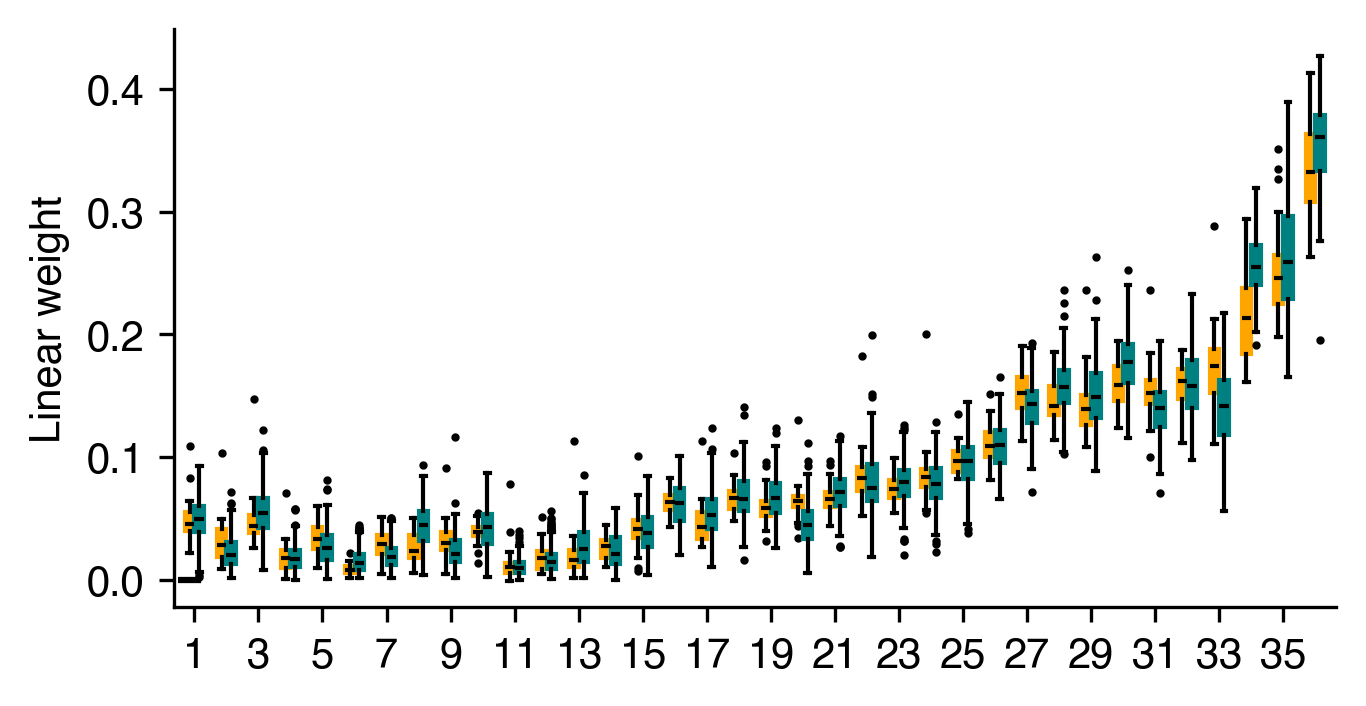

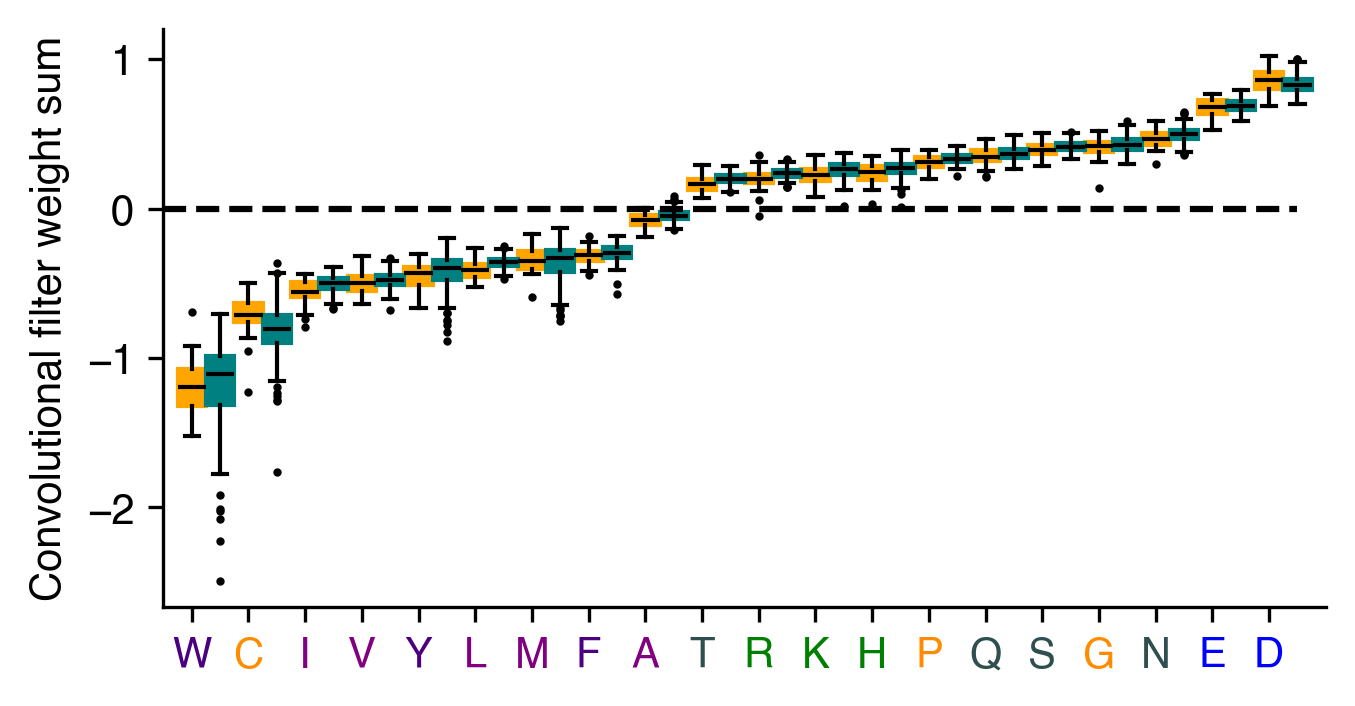

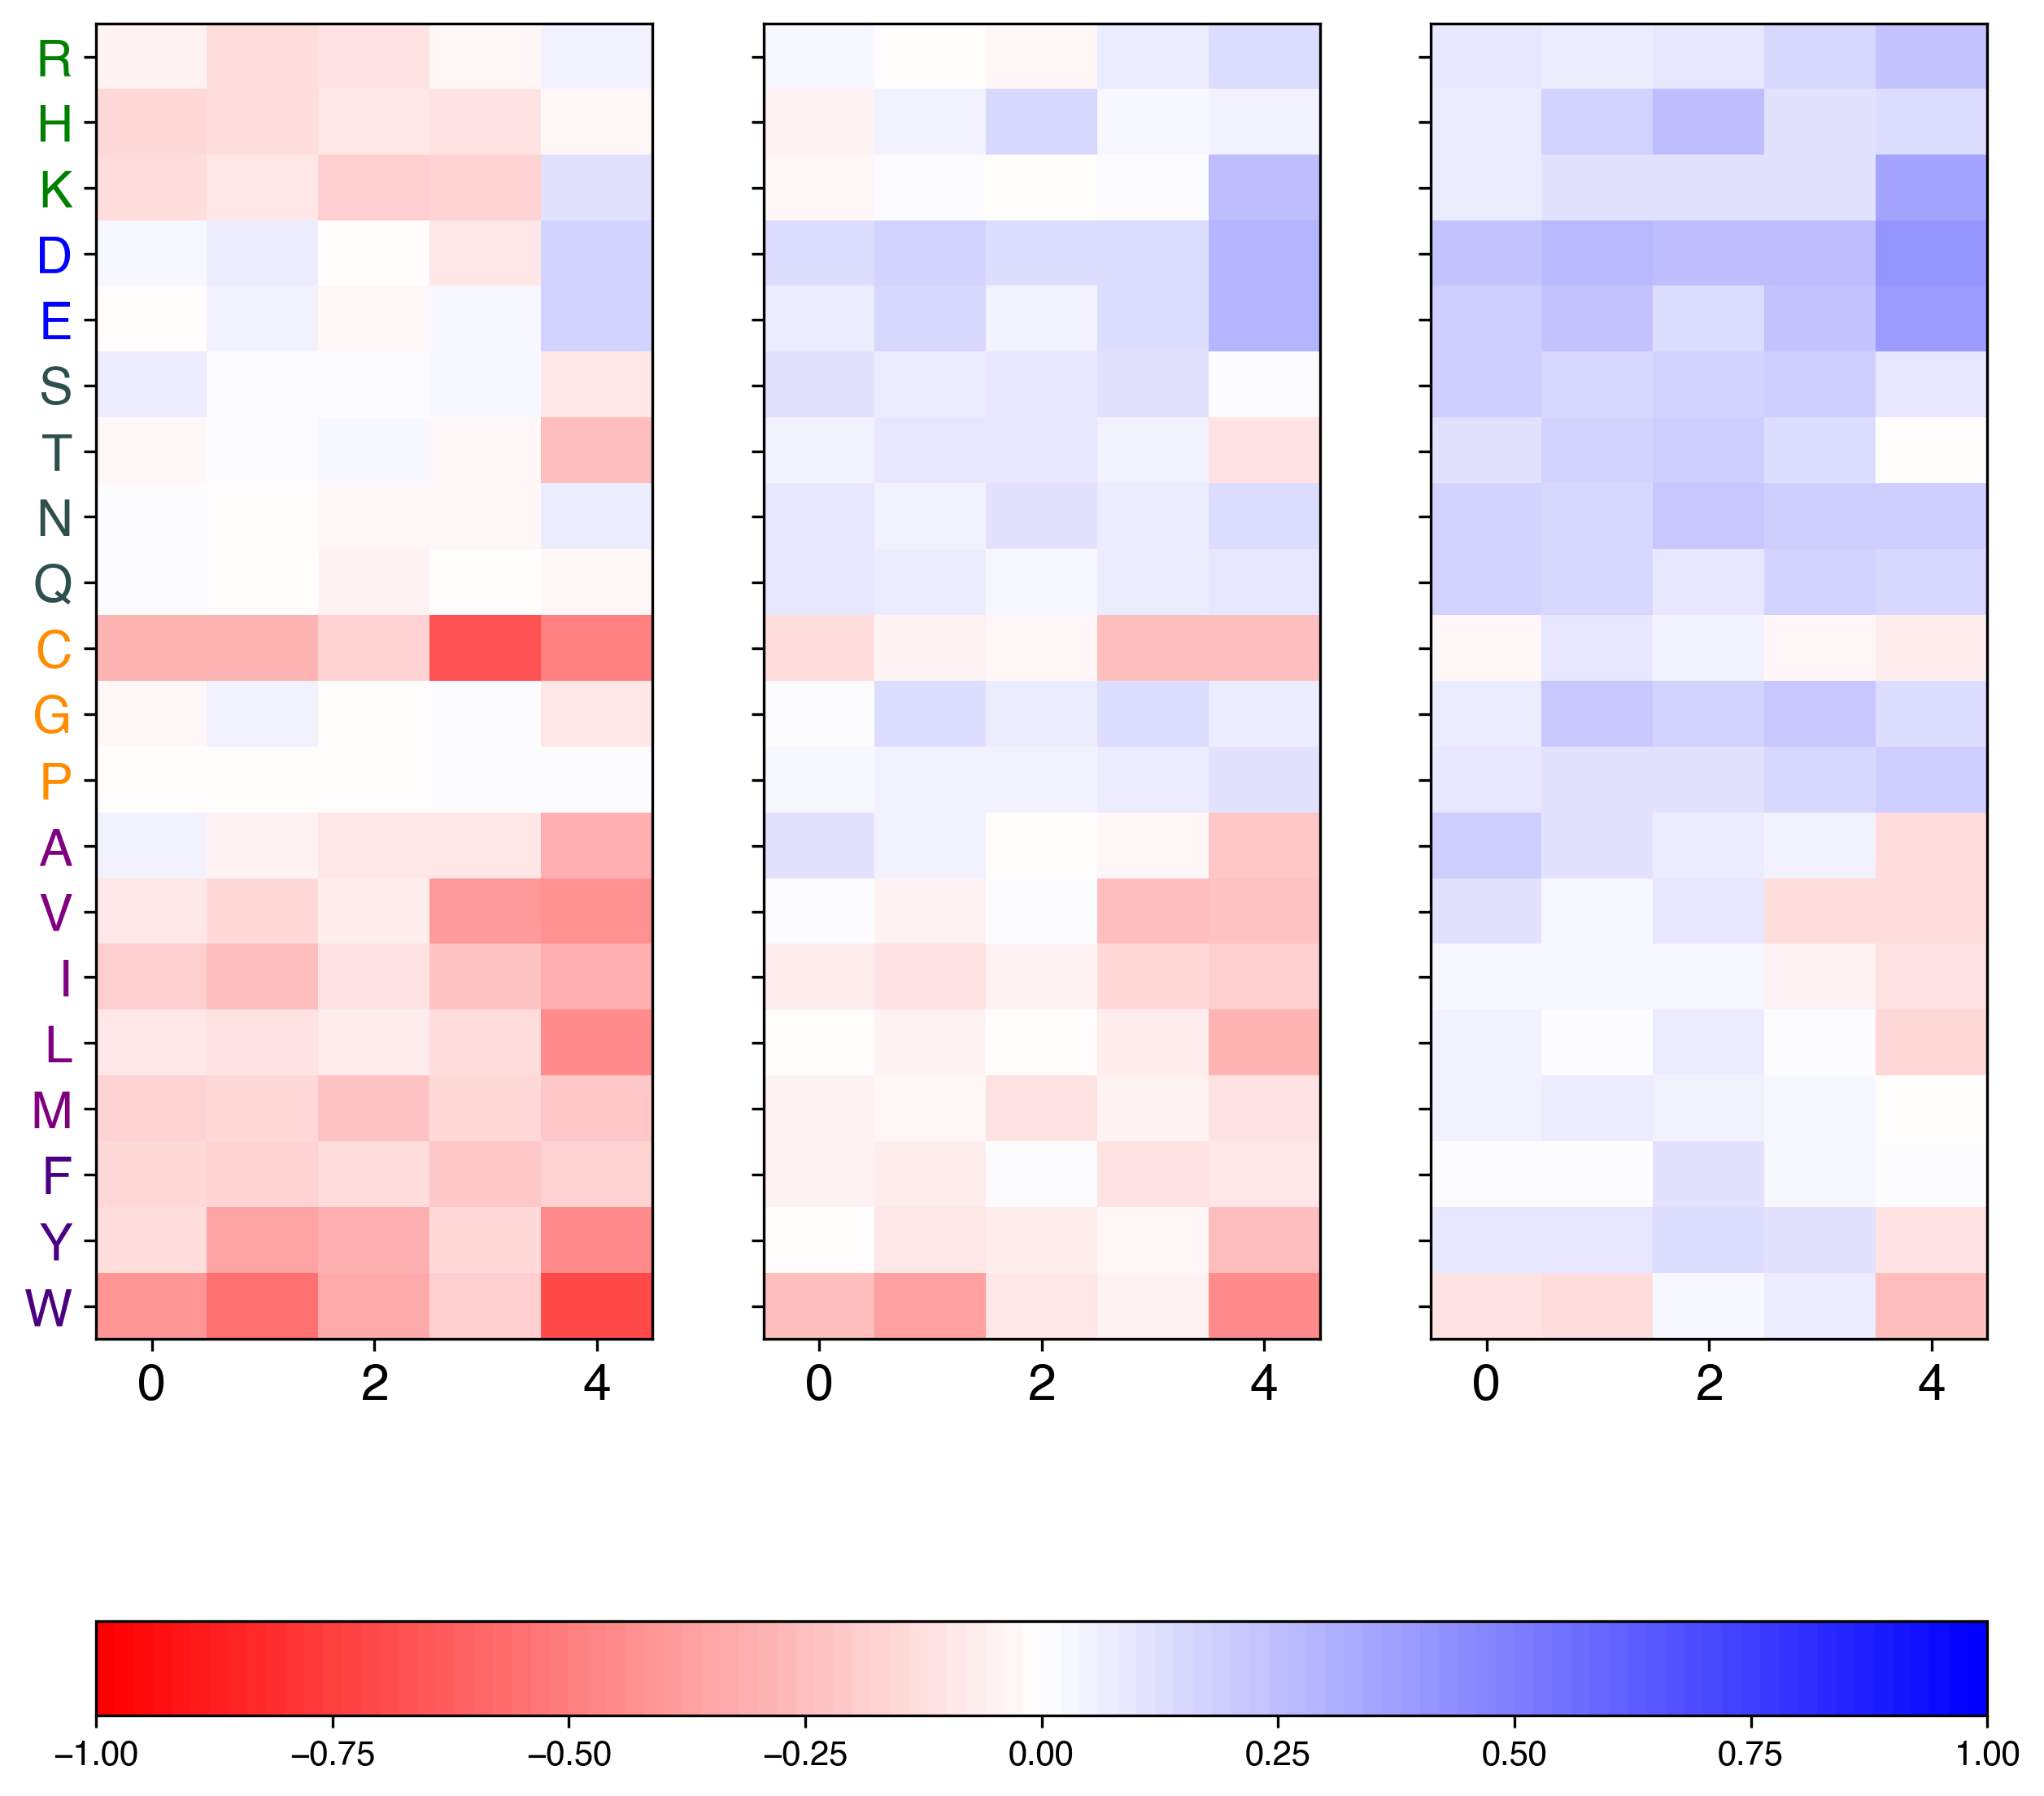

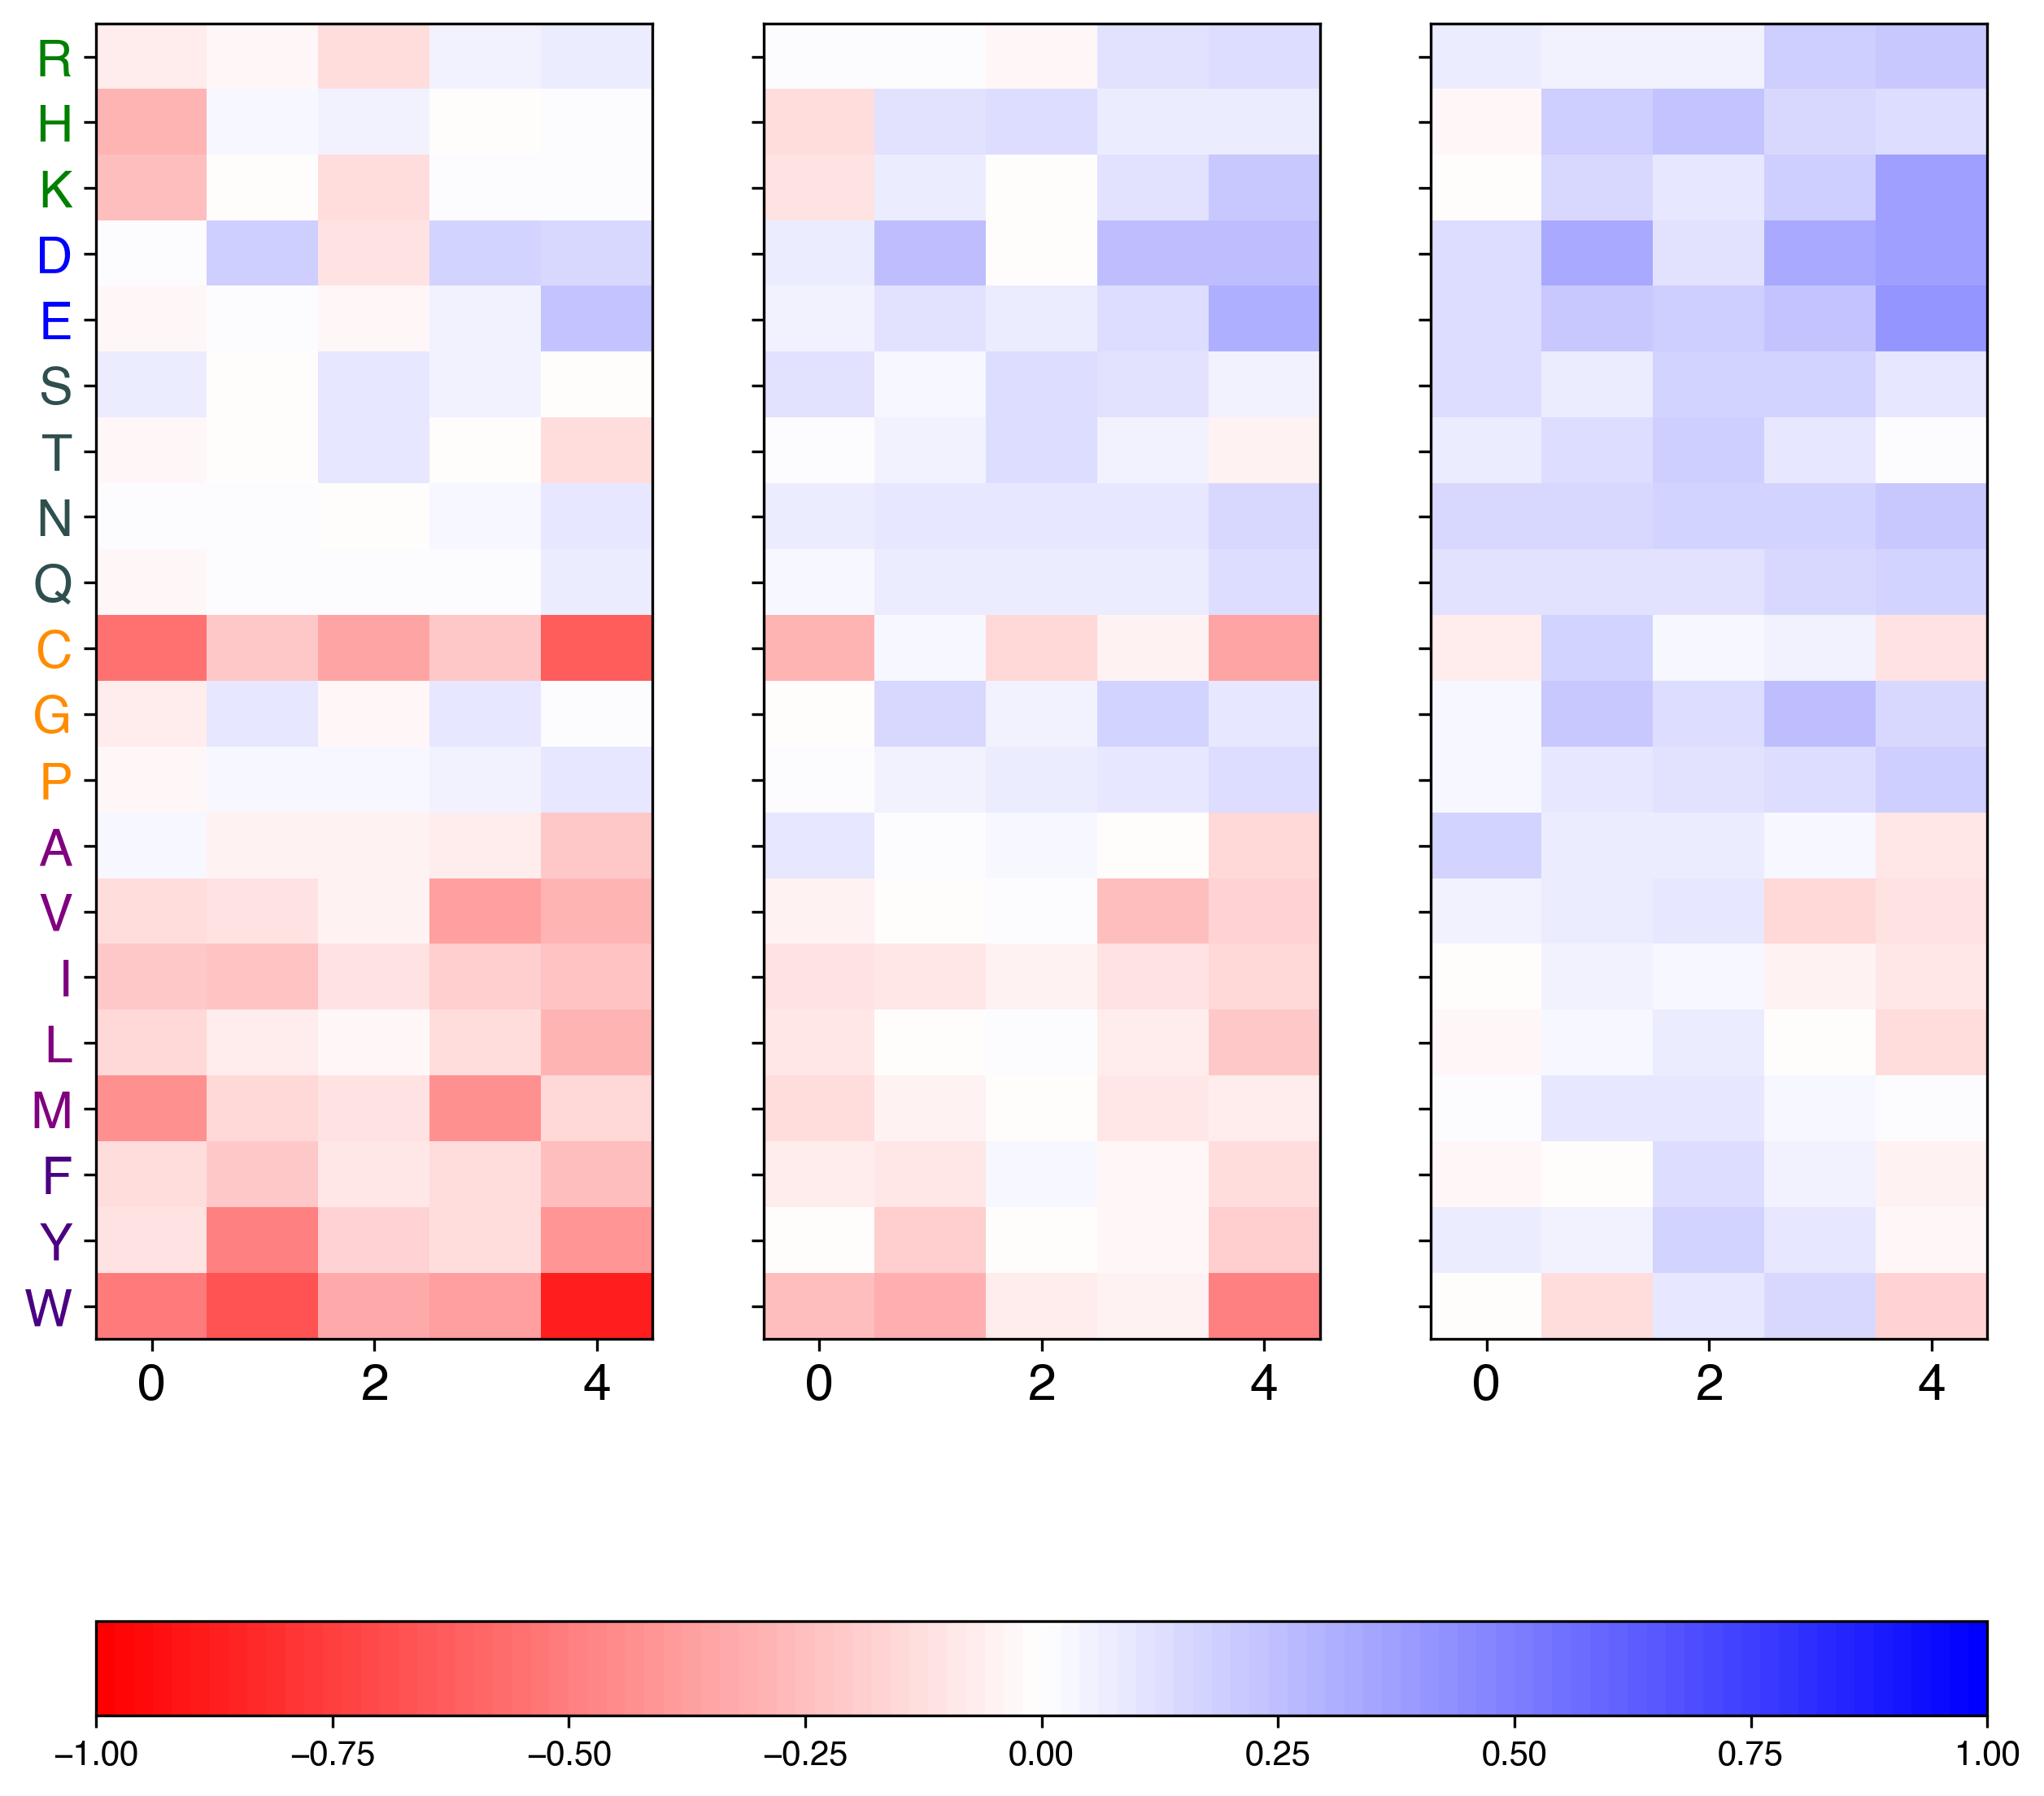

In [8]:
# comparison_subset
orig_aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]
aa_order = ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

run_analysis(5, outfile_name="k5")

# K = 10

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:00<00:00, 664.74it/s]


Bootstrap variance 0.005100905377477224
Seed variance 0.005393943107155206


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 10, 20) (1, 10, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


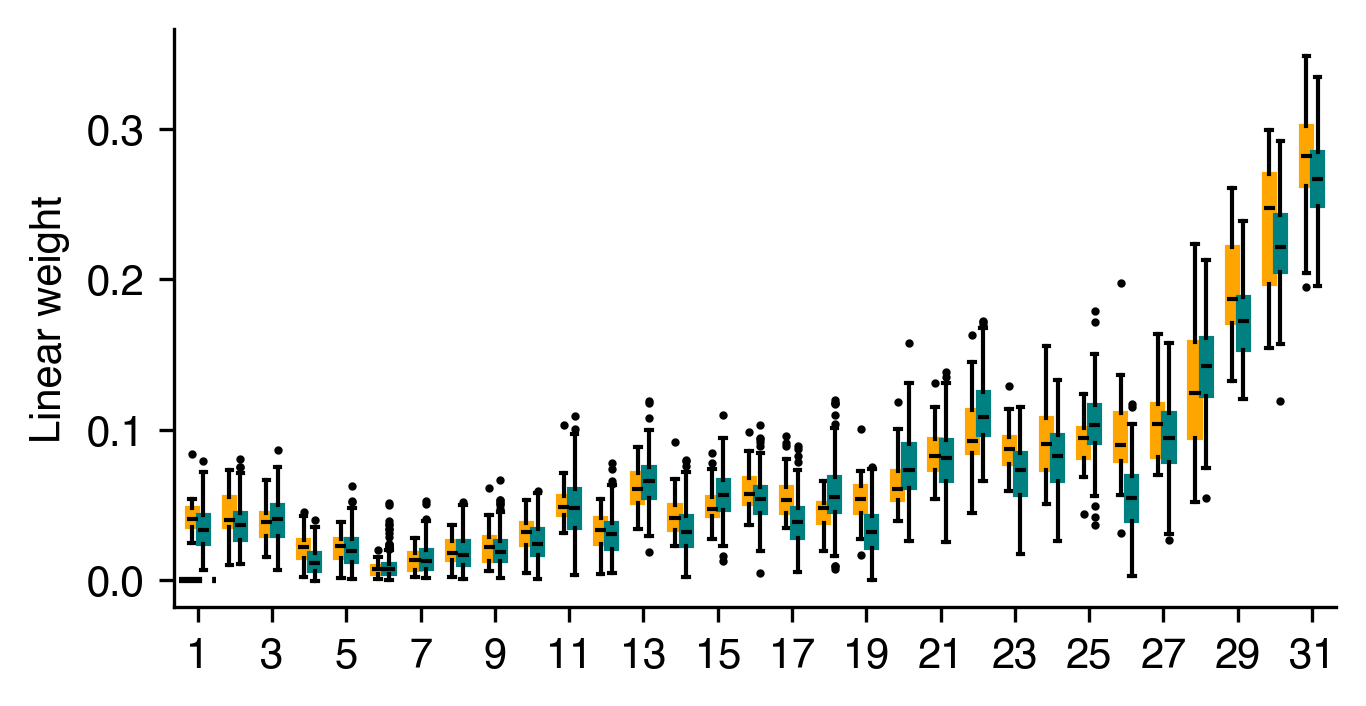

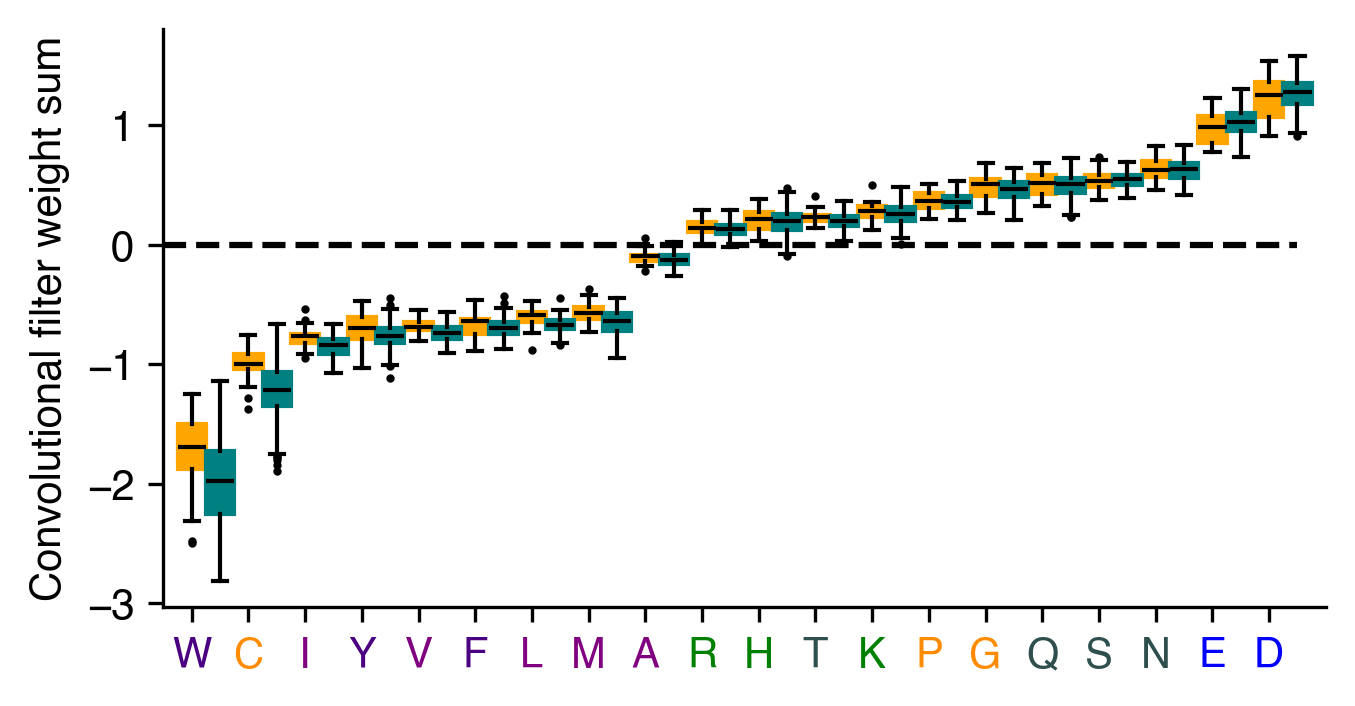

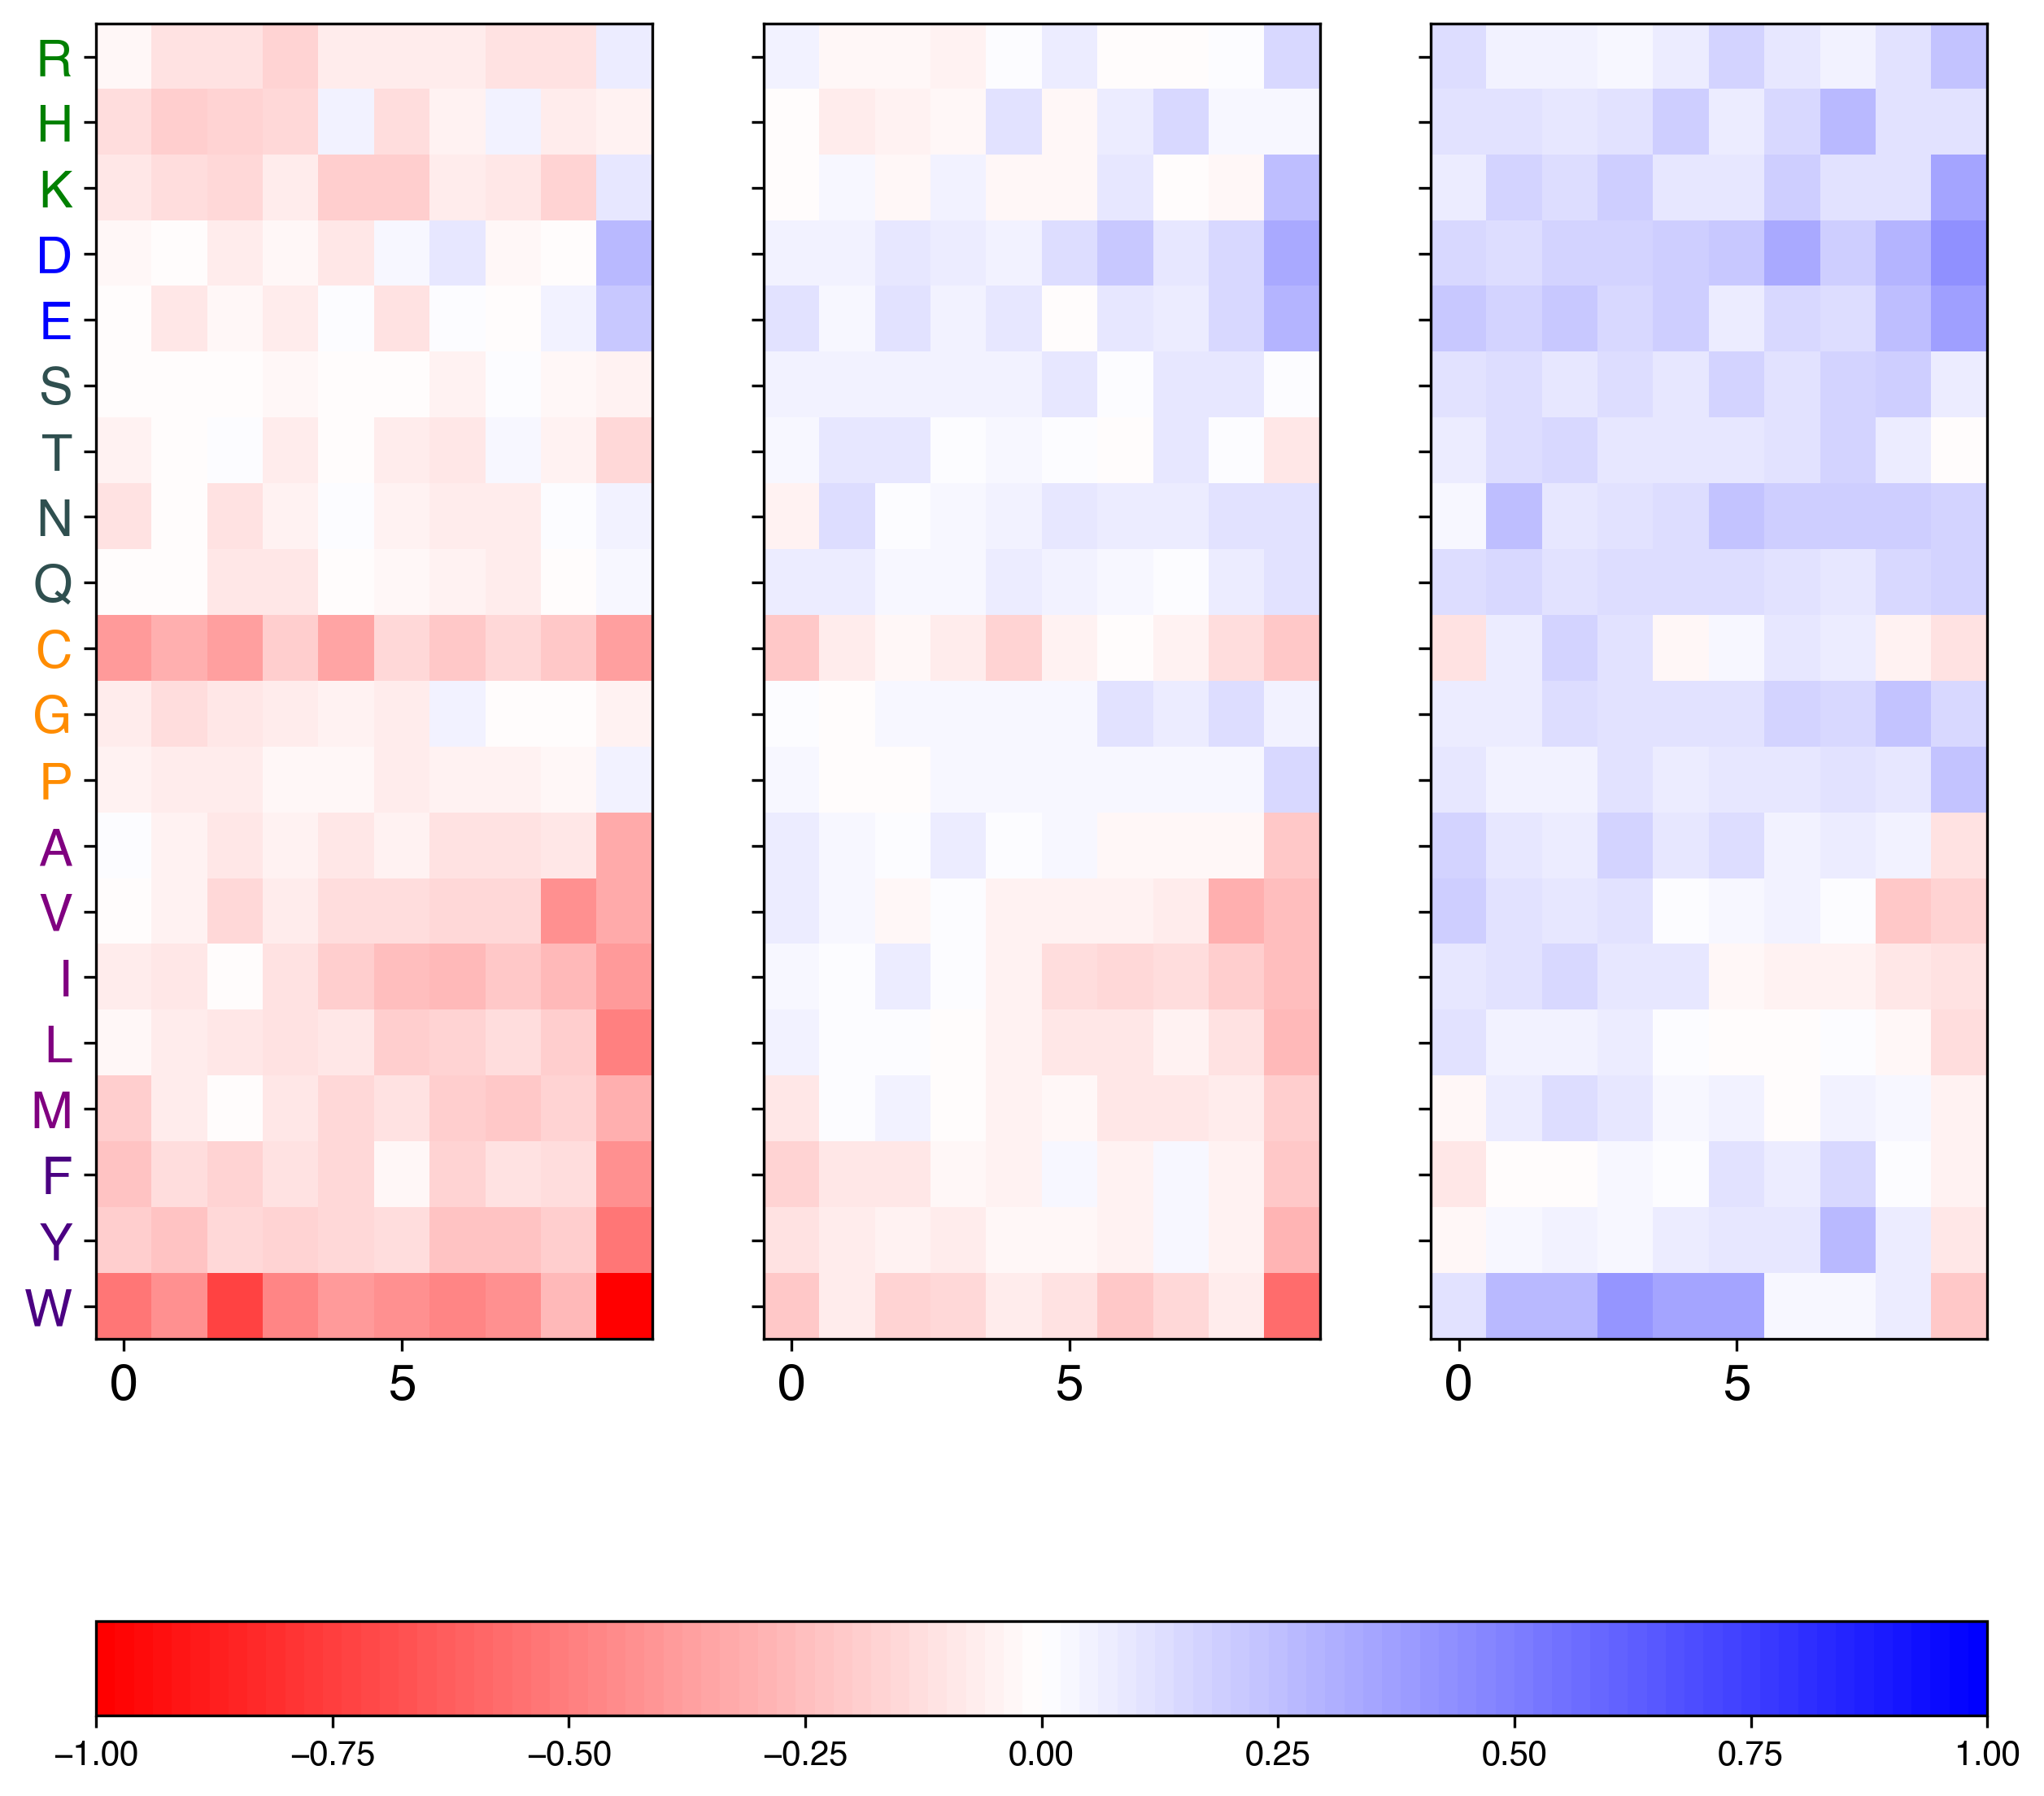

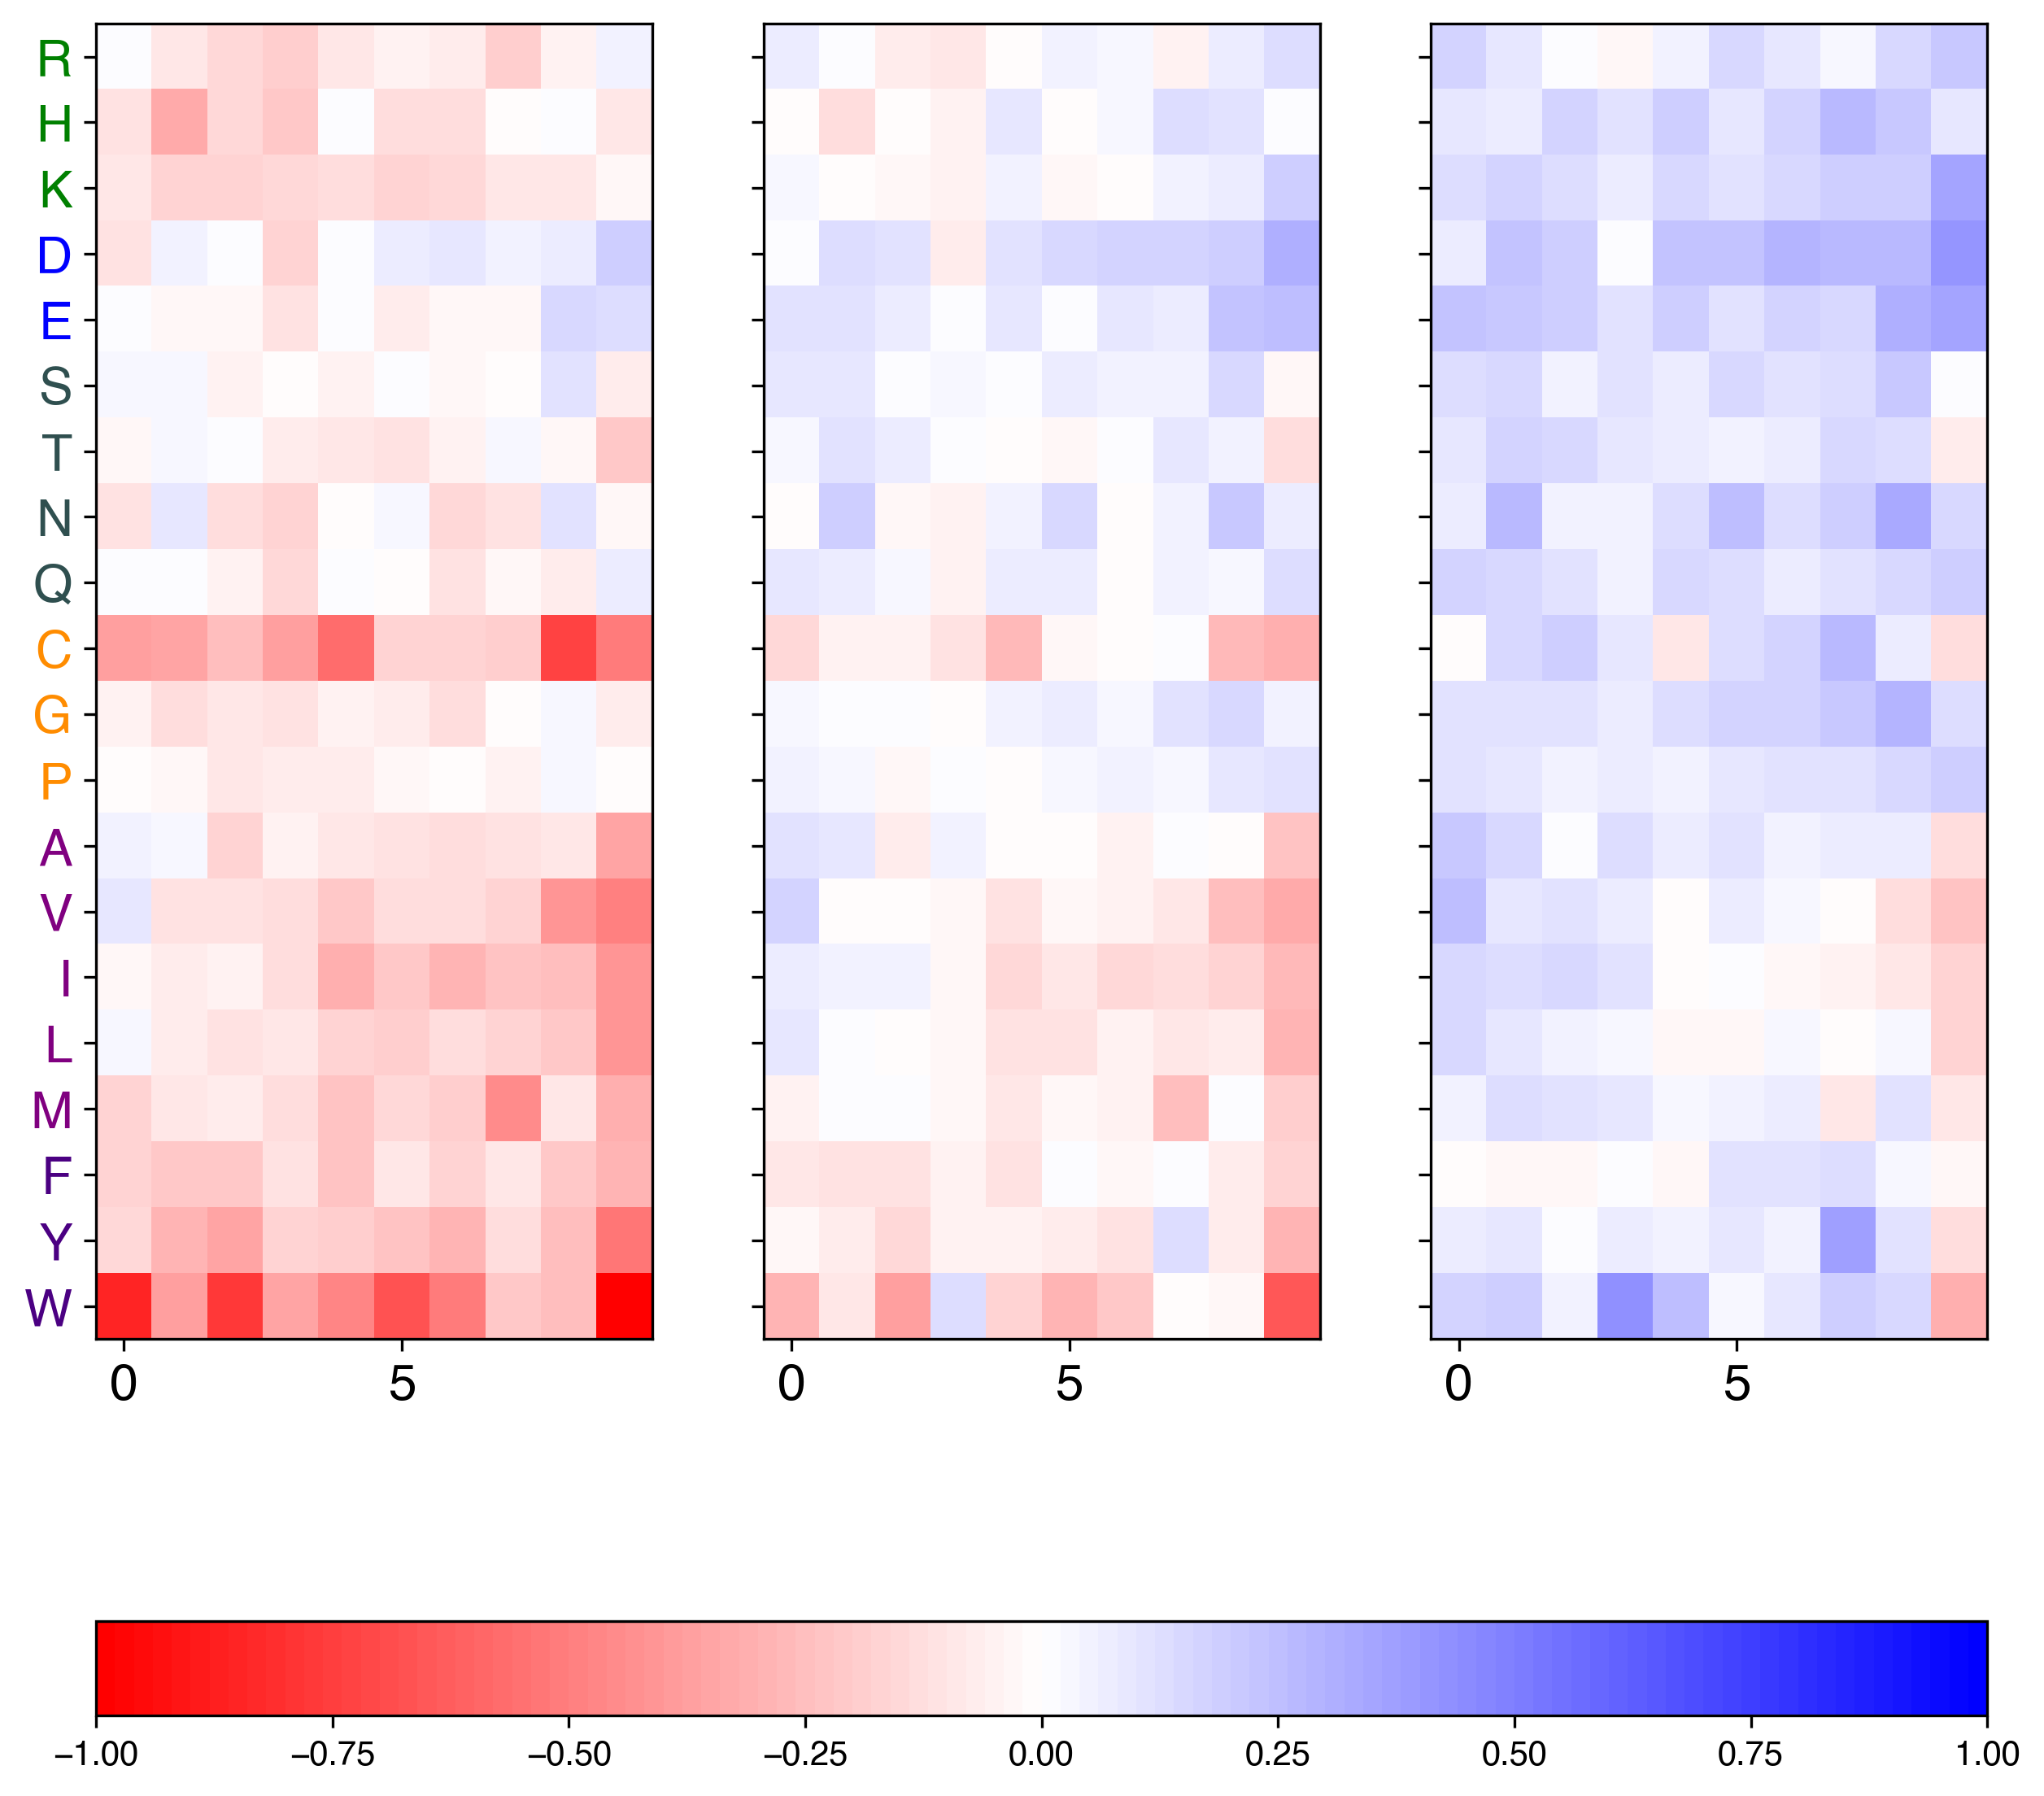

In [9]:
# comparison_subset
run_analysis(10, outfile_name="k10")

# Kernel size 15

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:00<00:00, 717.11it/s]


Bootstrap variance 0.00469607456018845
Seed variance 0.005152813266820552


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 15, 20) (1, 15, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


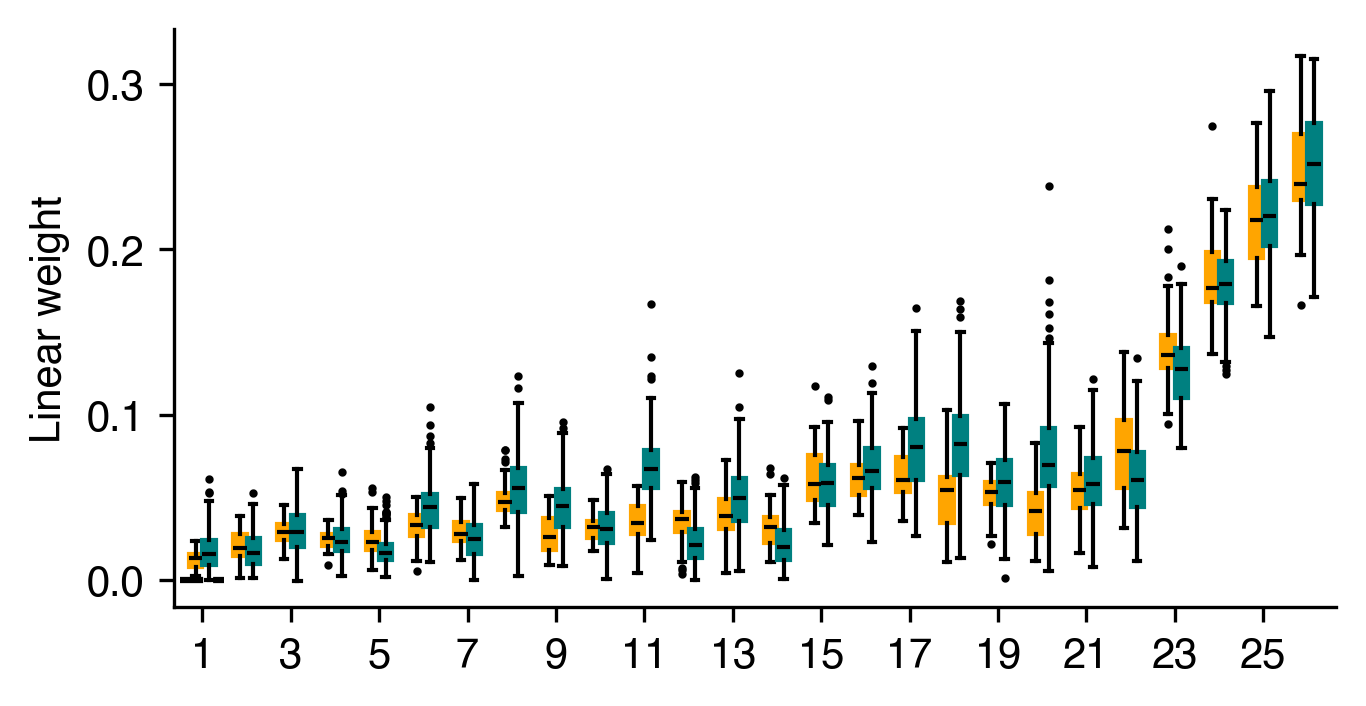

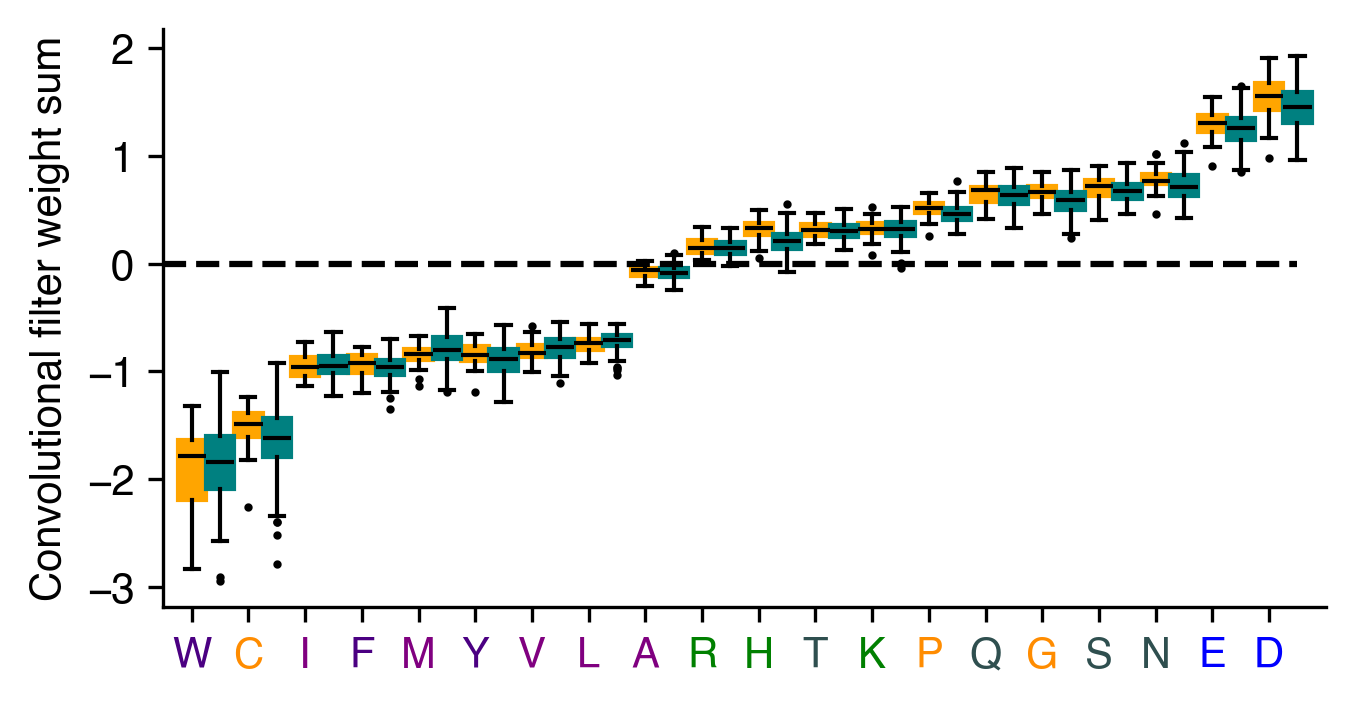

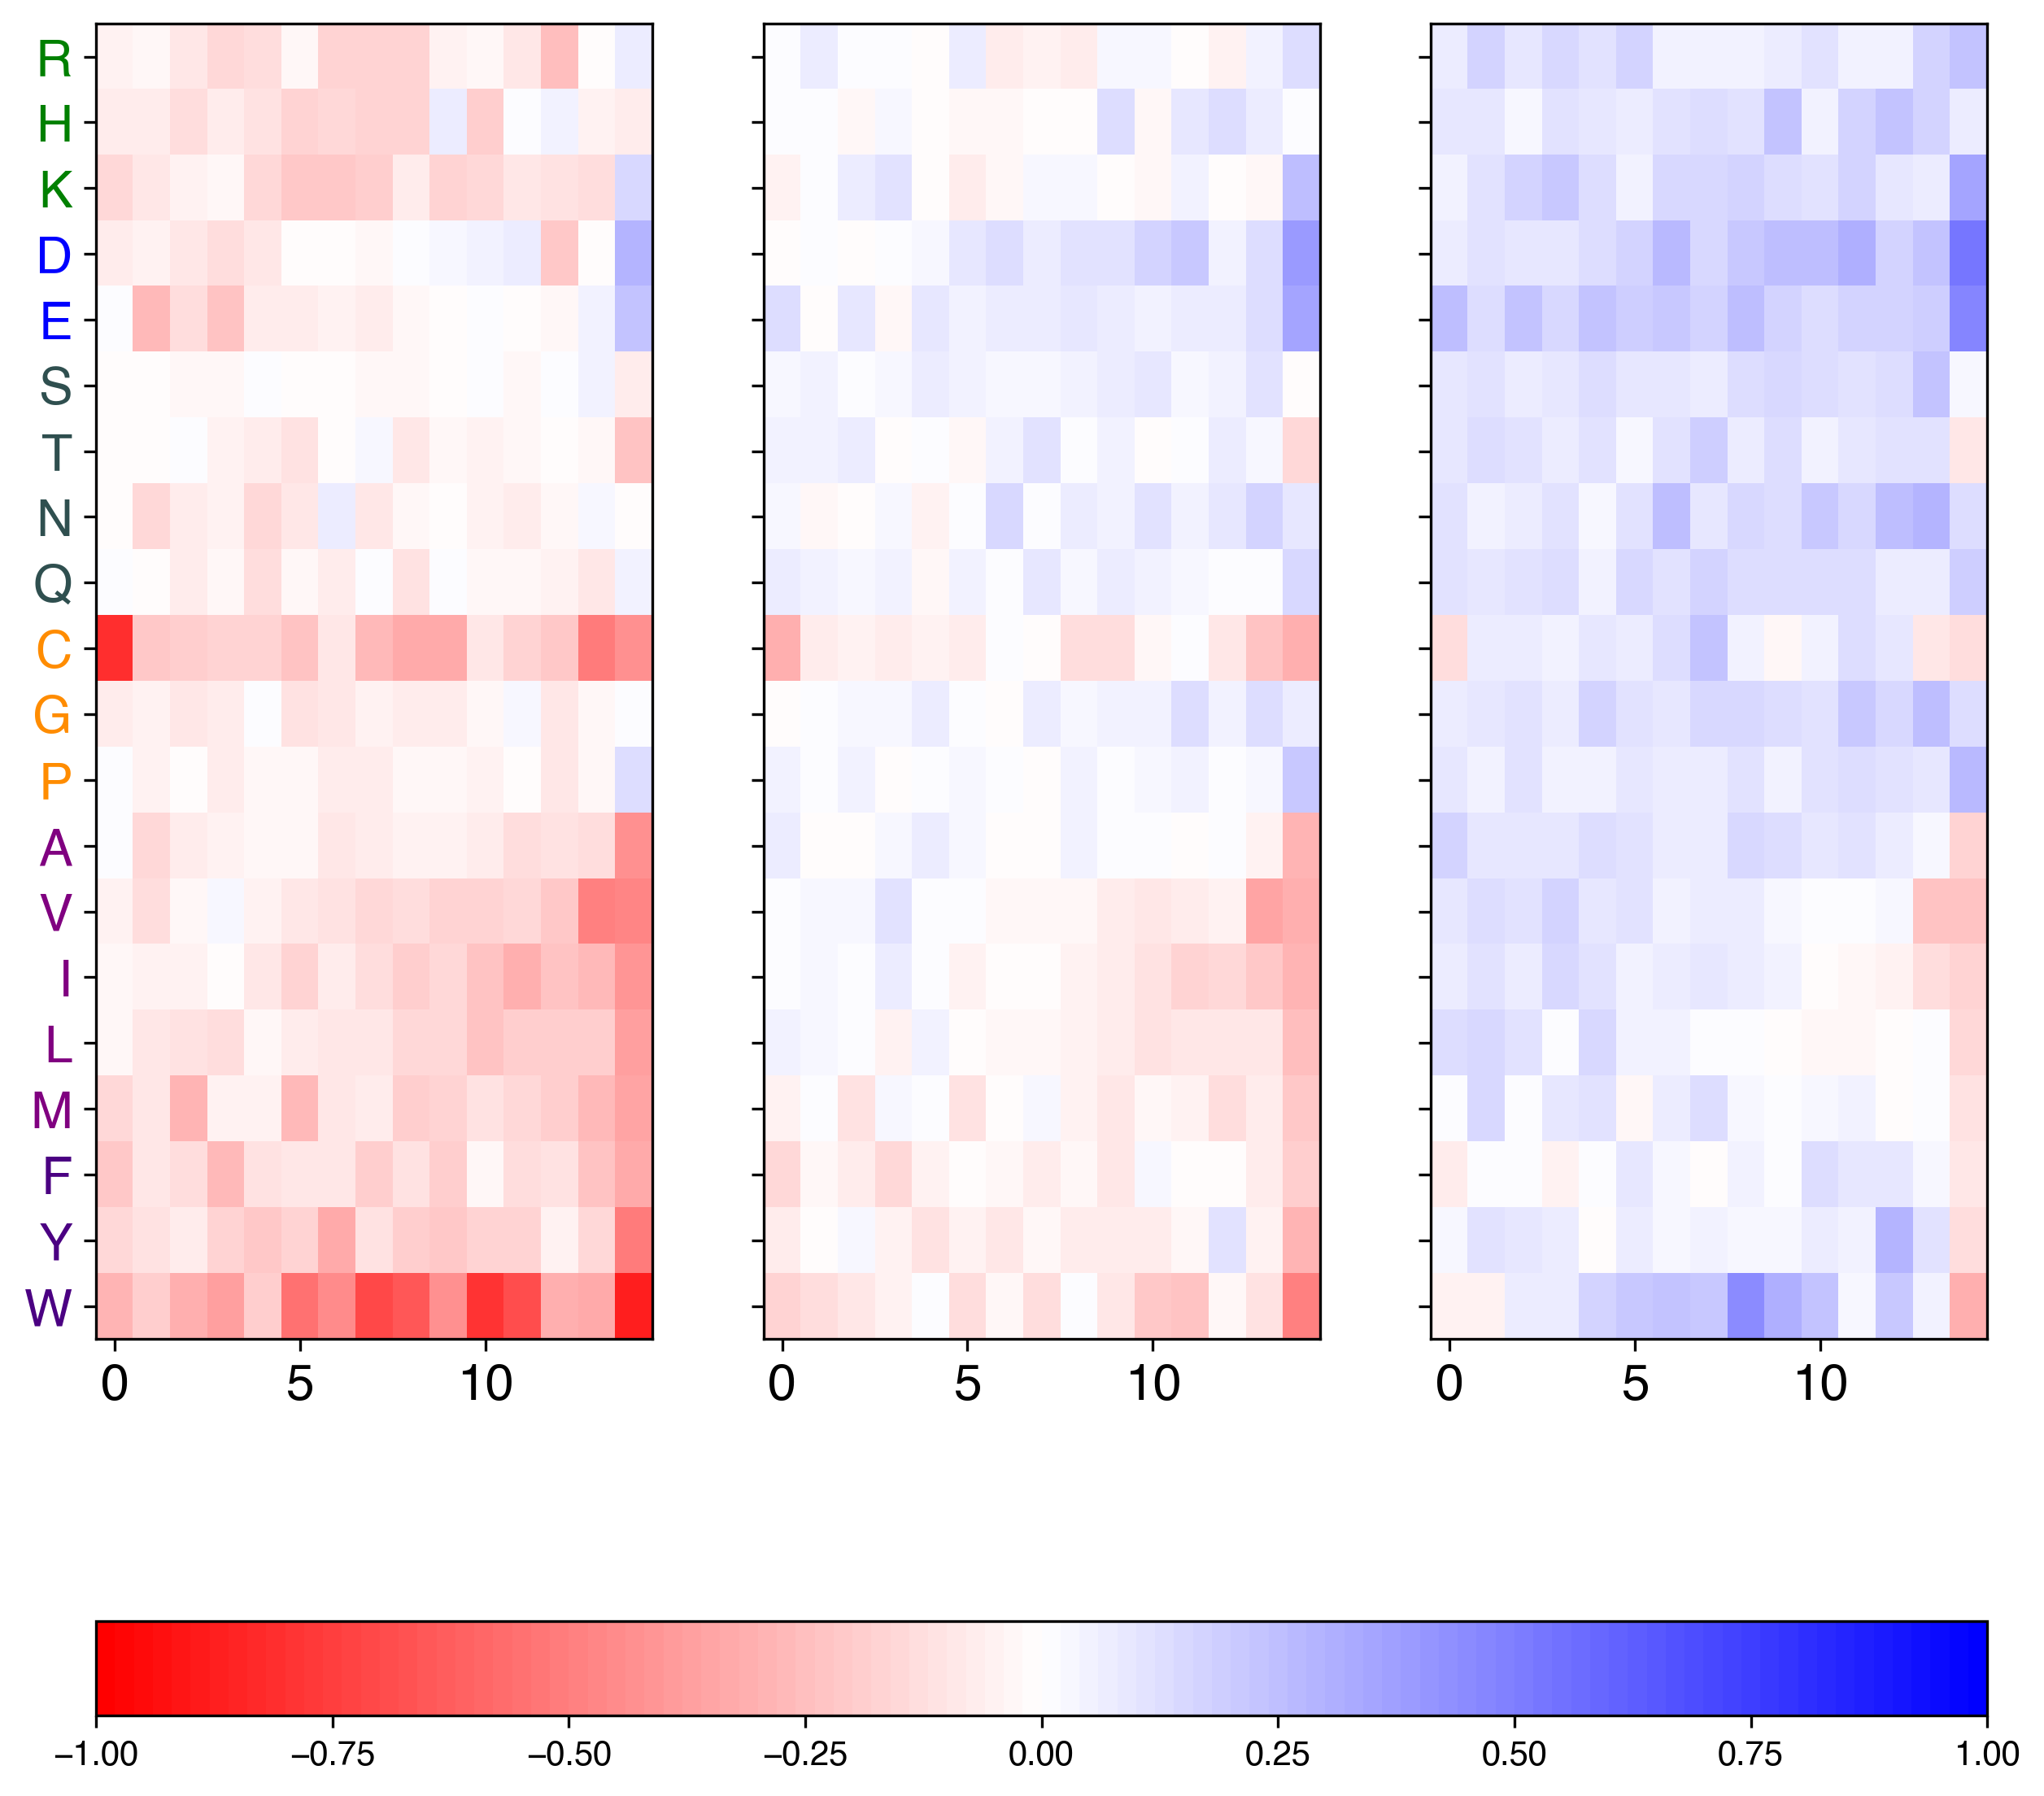

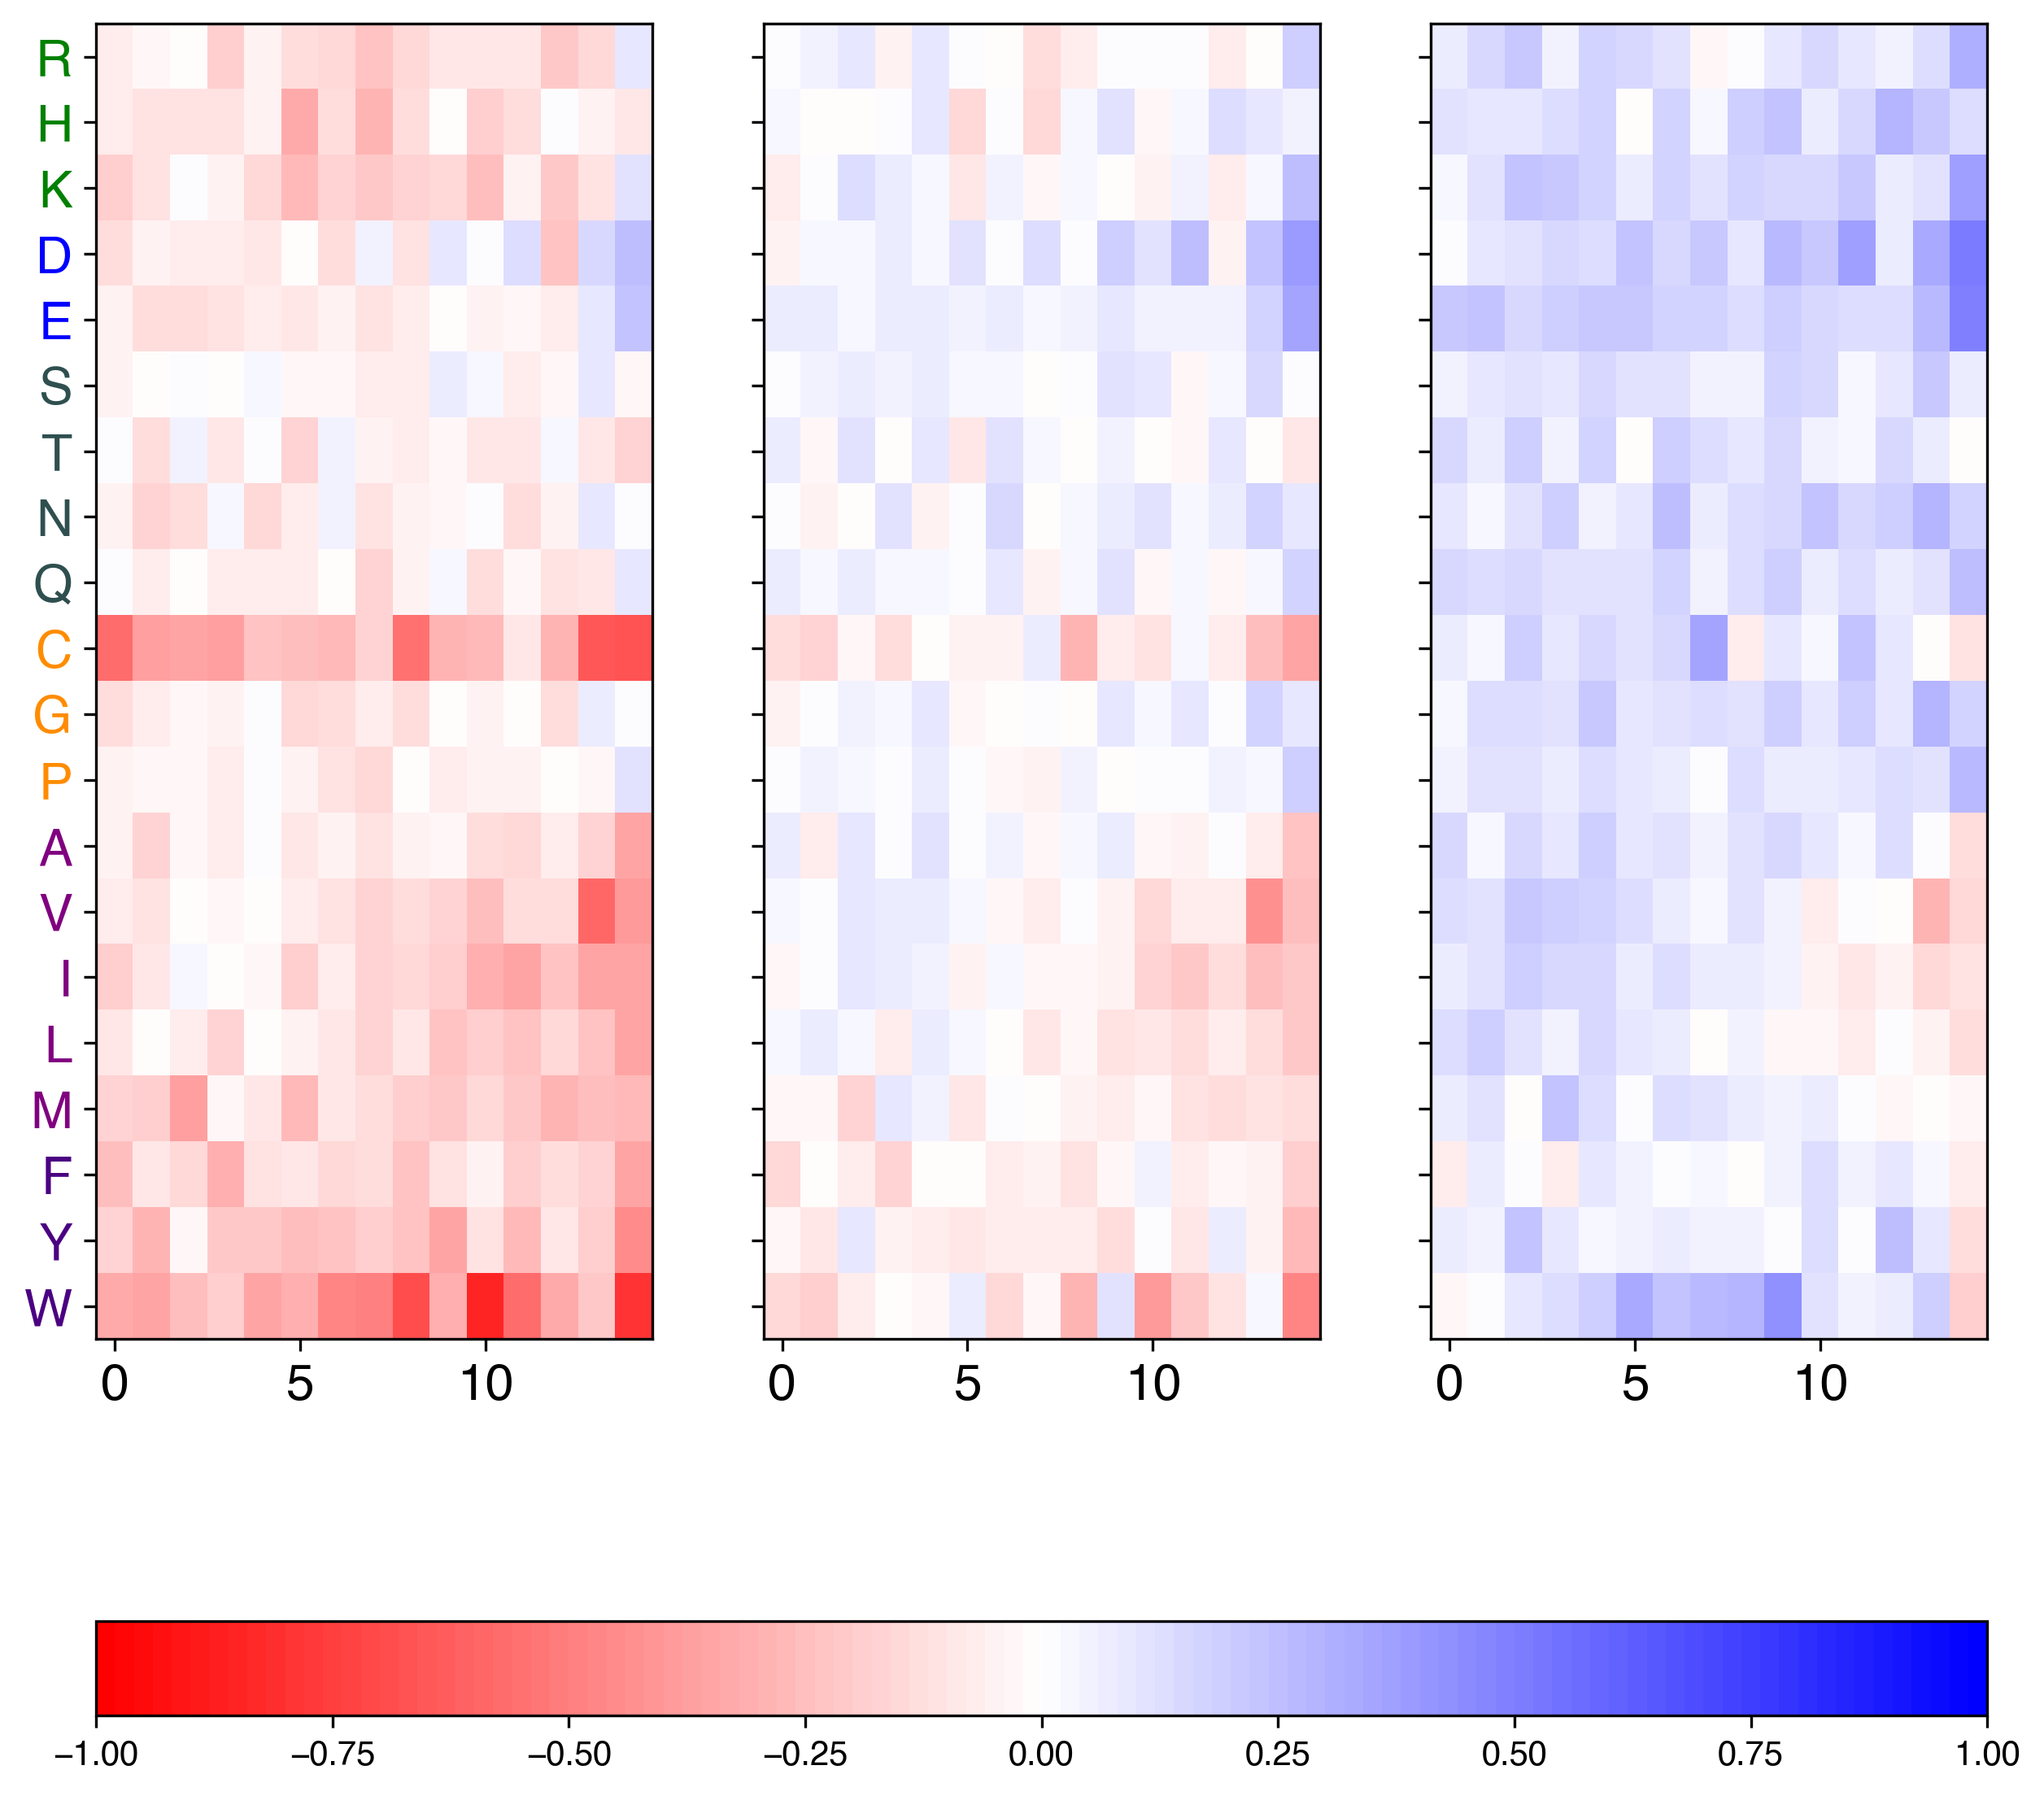

In [10]:
run_analysis(15, outfile_name="k15")

# Kernel size 20

100%|██████████| 200/200 [00:00<00:00, 686.18it/s]


Bootstrap variance 0.005666982996041709
Seed variance 0.004975444042510706


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 20, 20) (1, 20, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


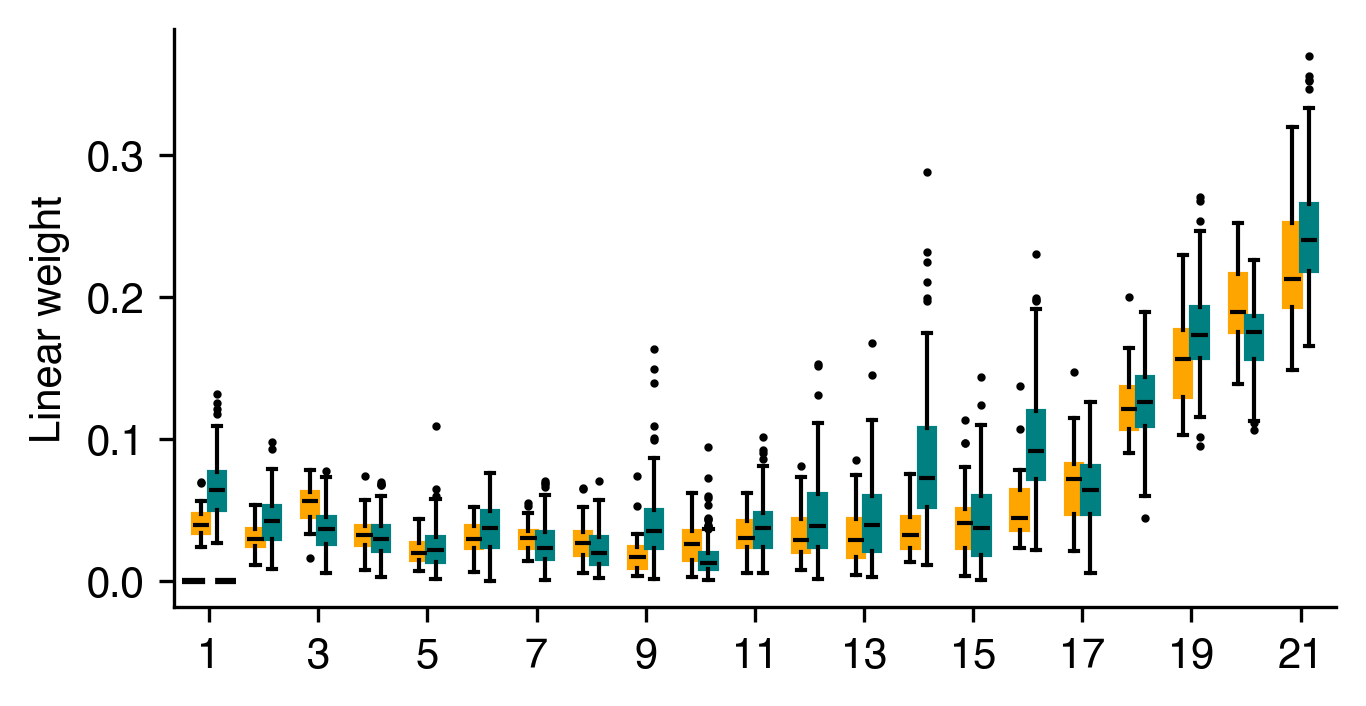

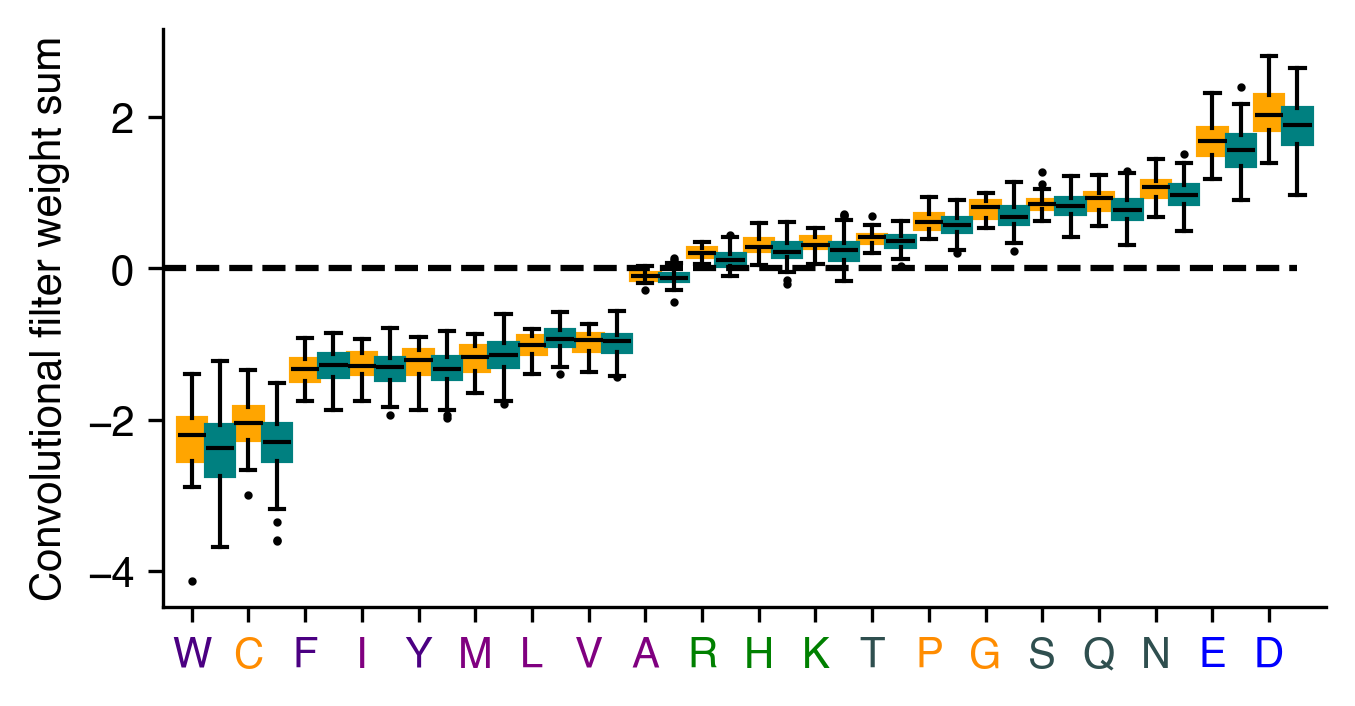

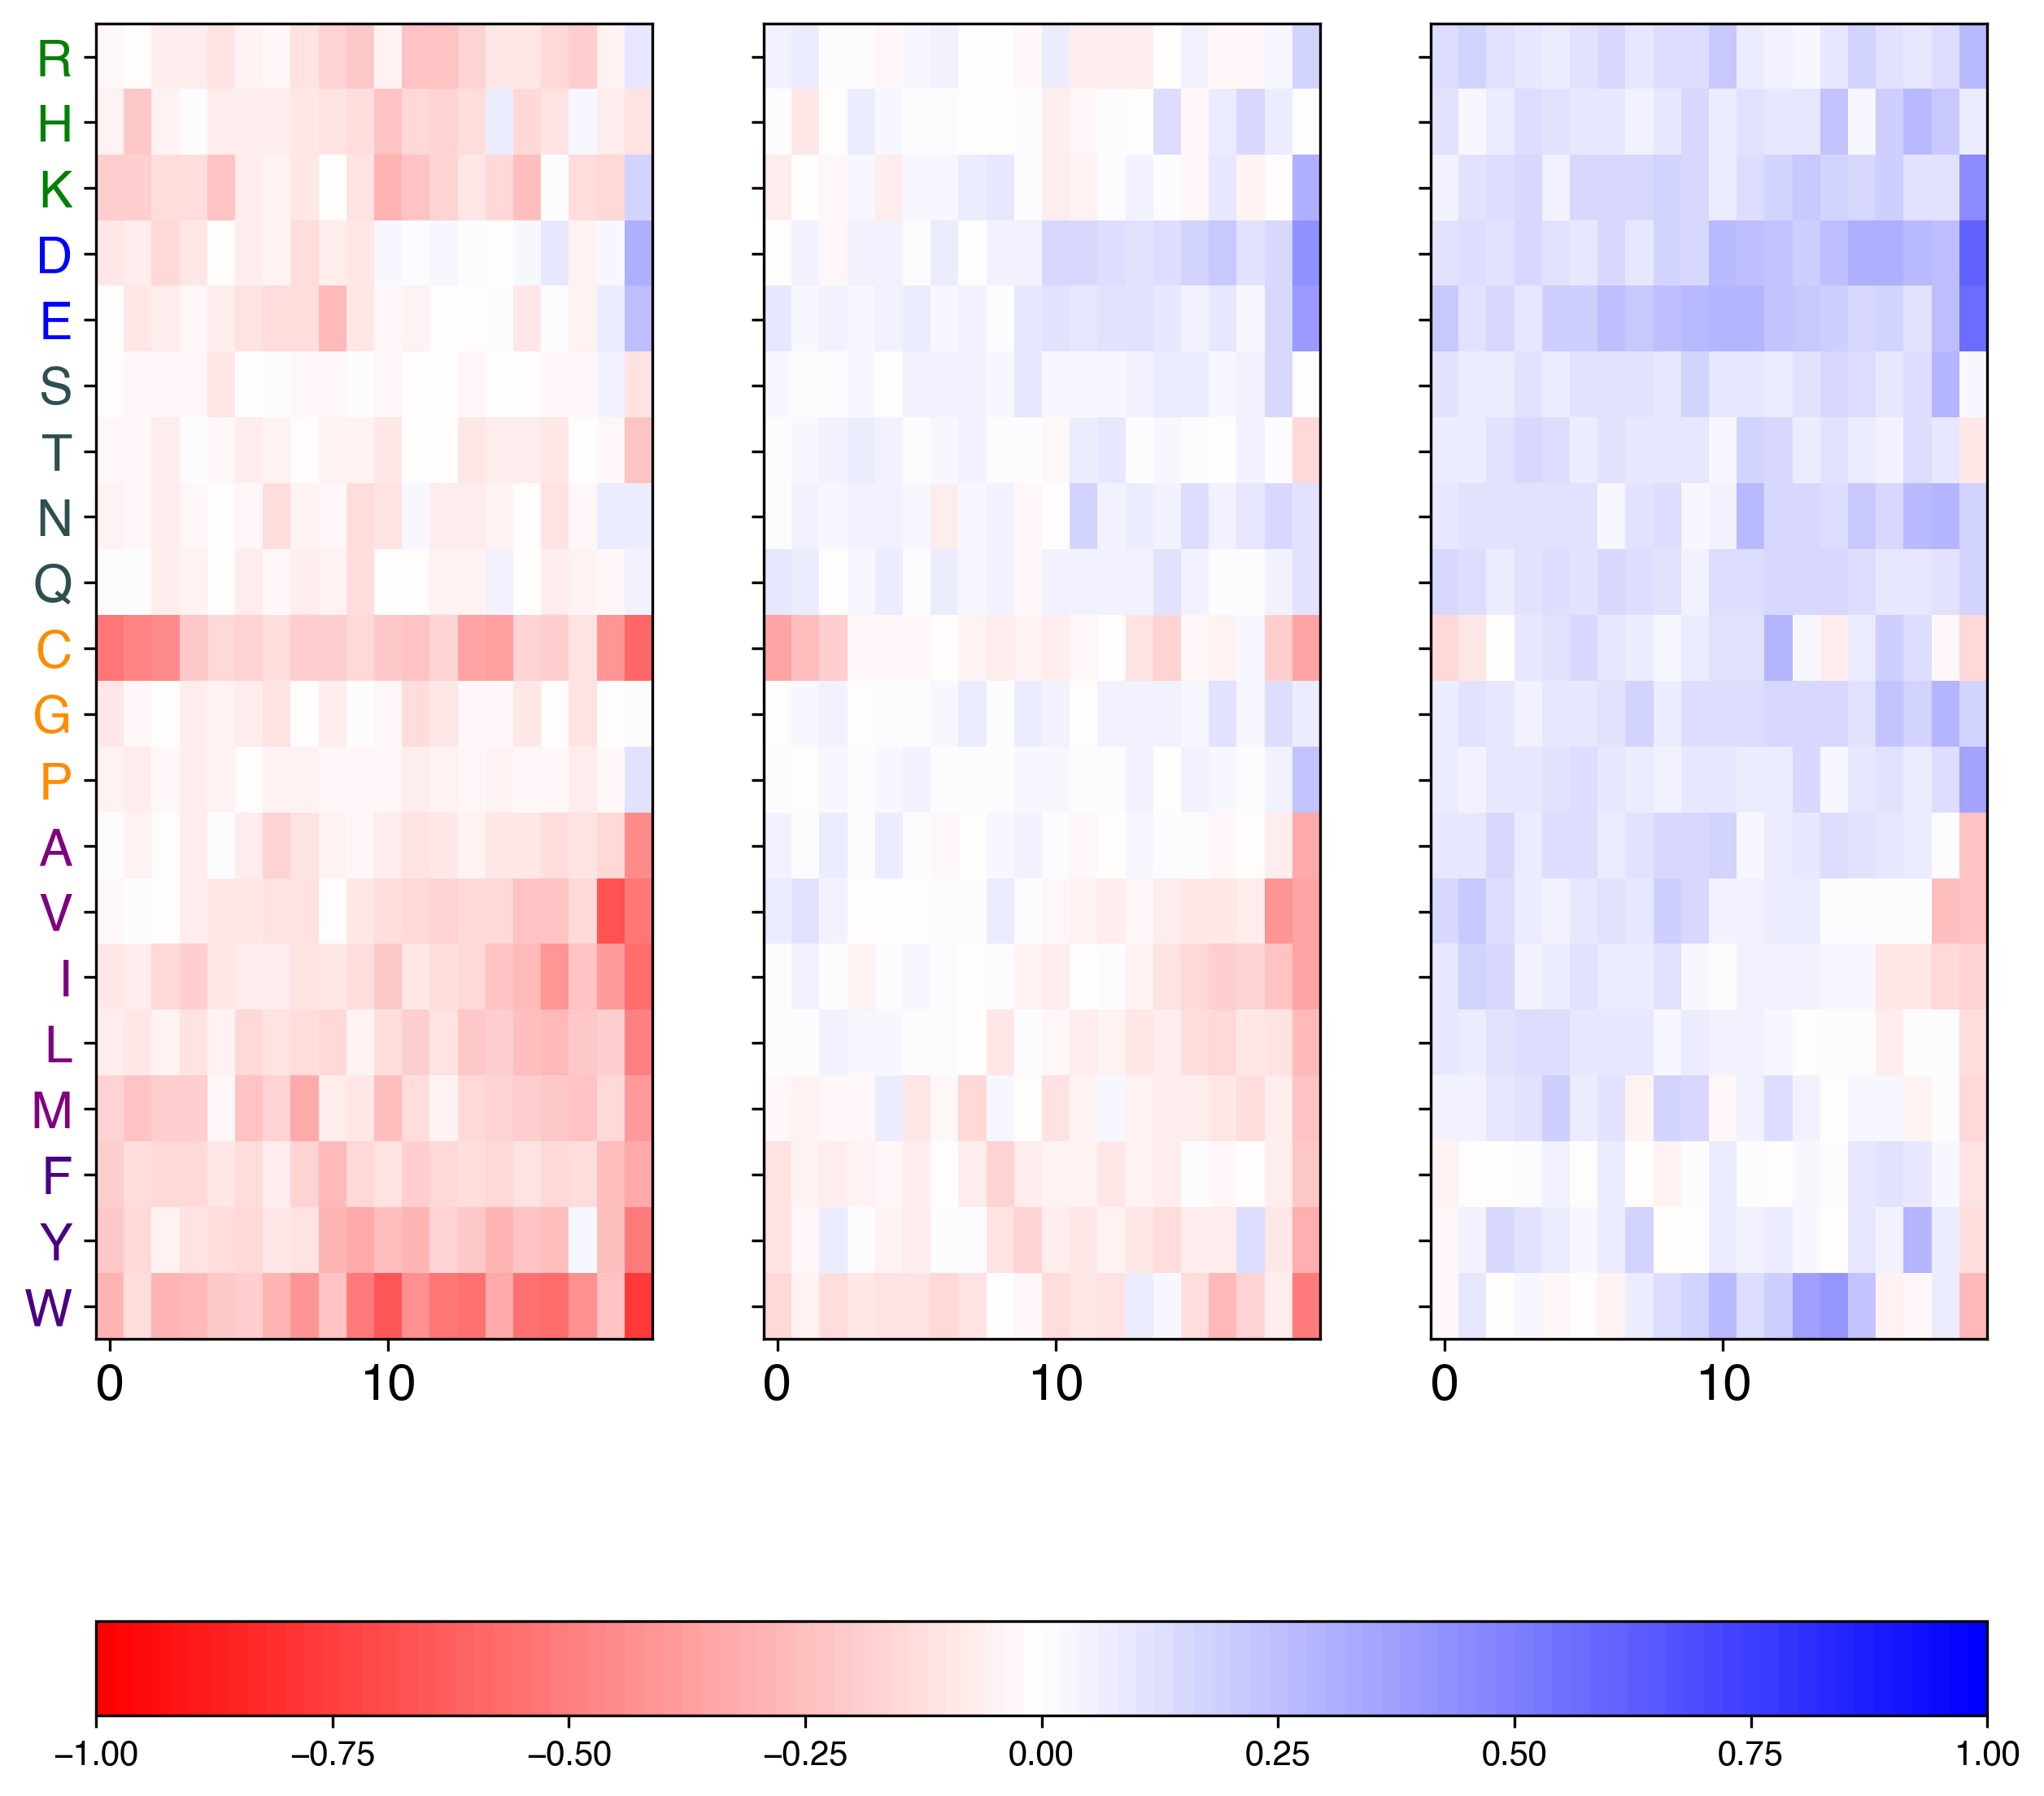

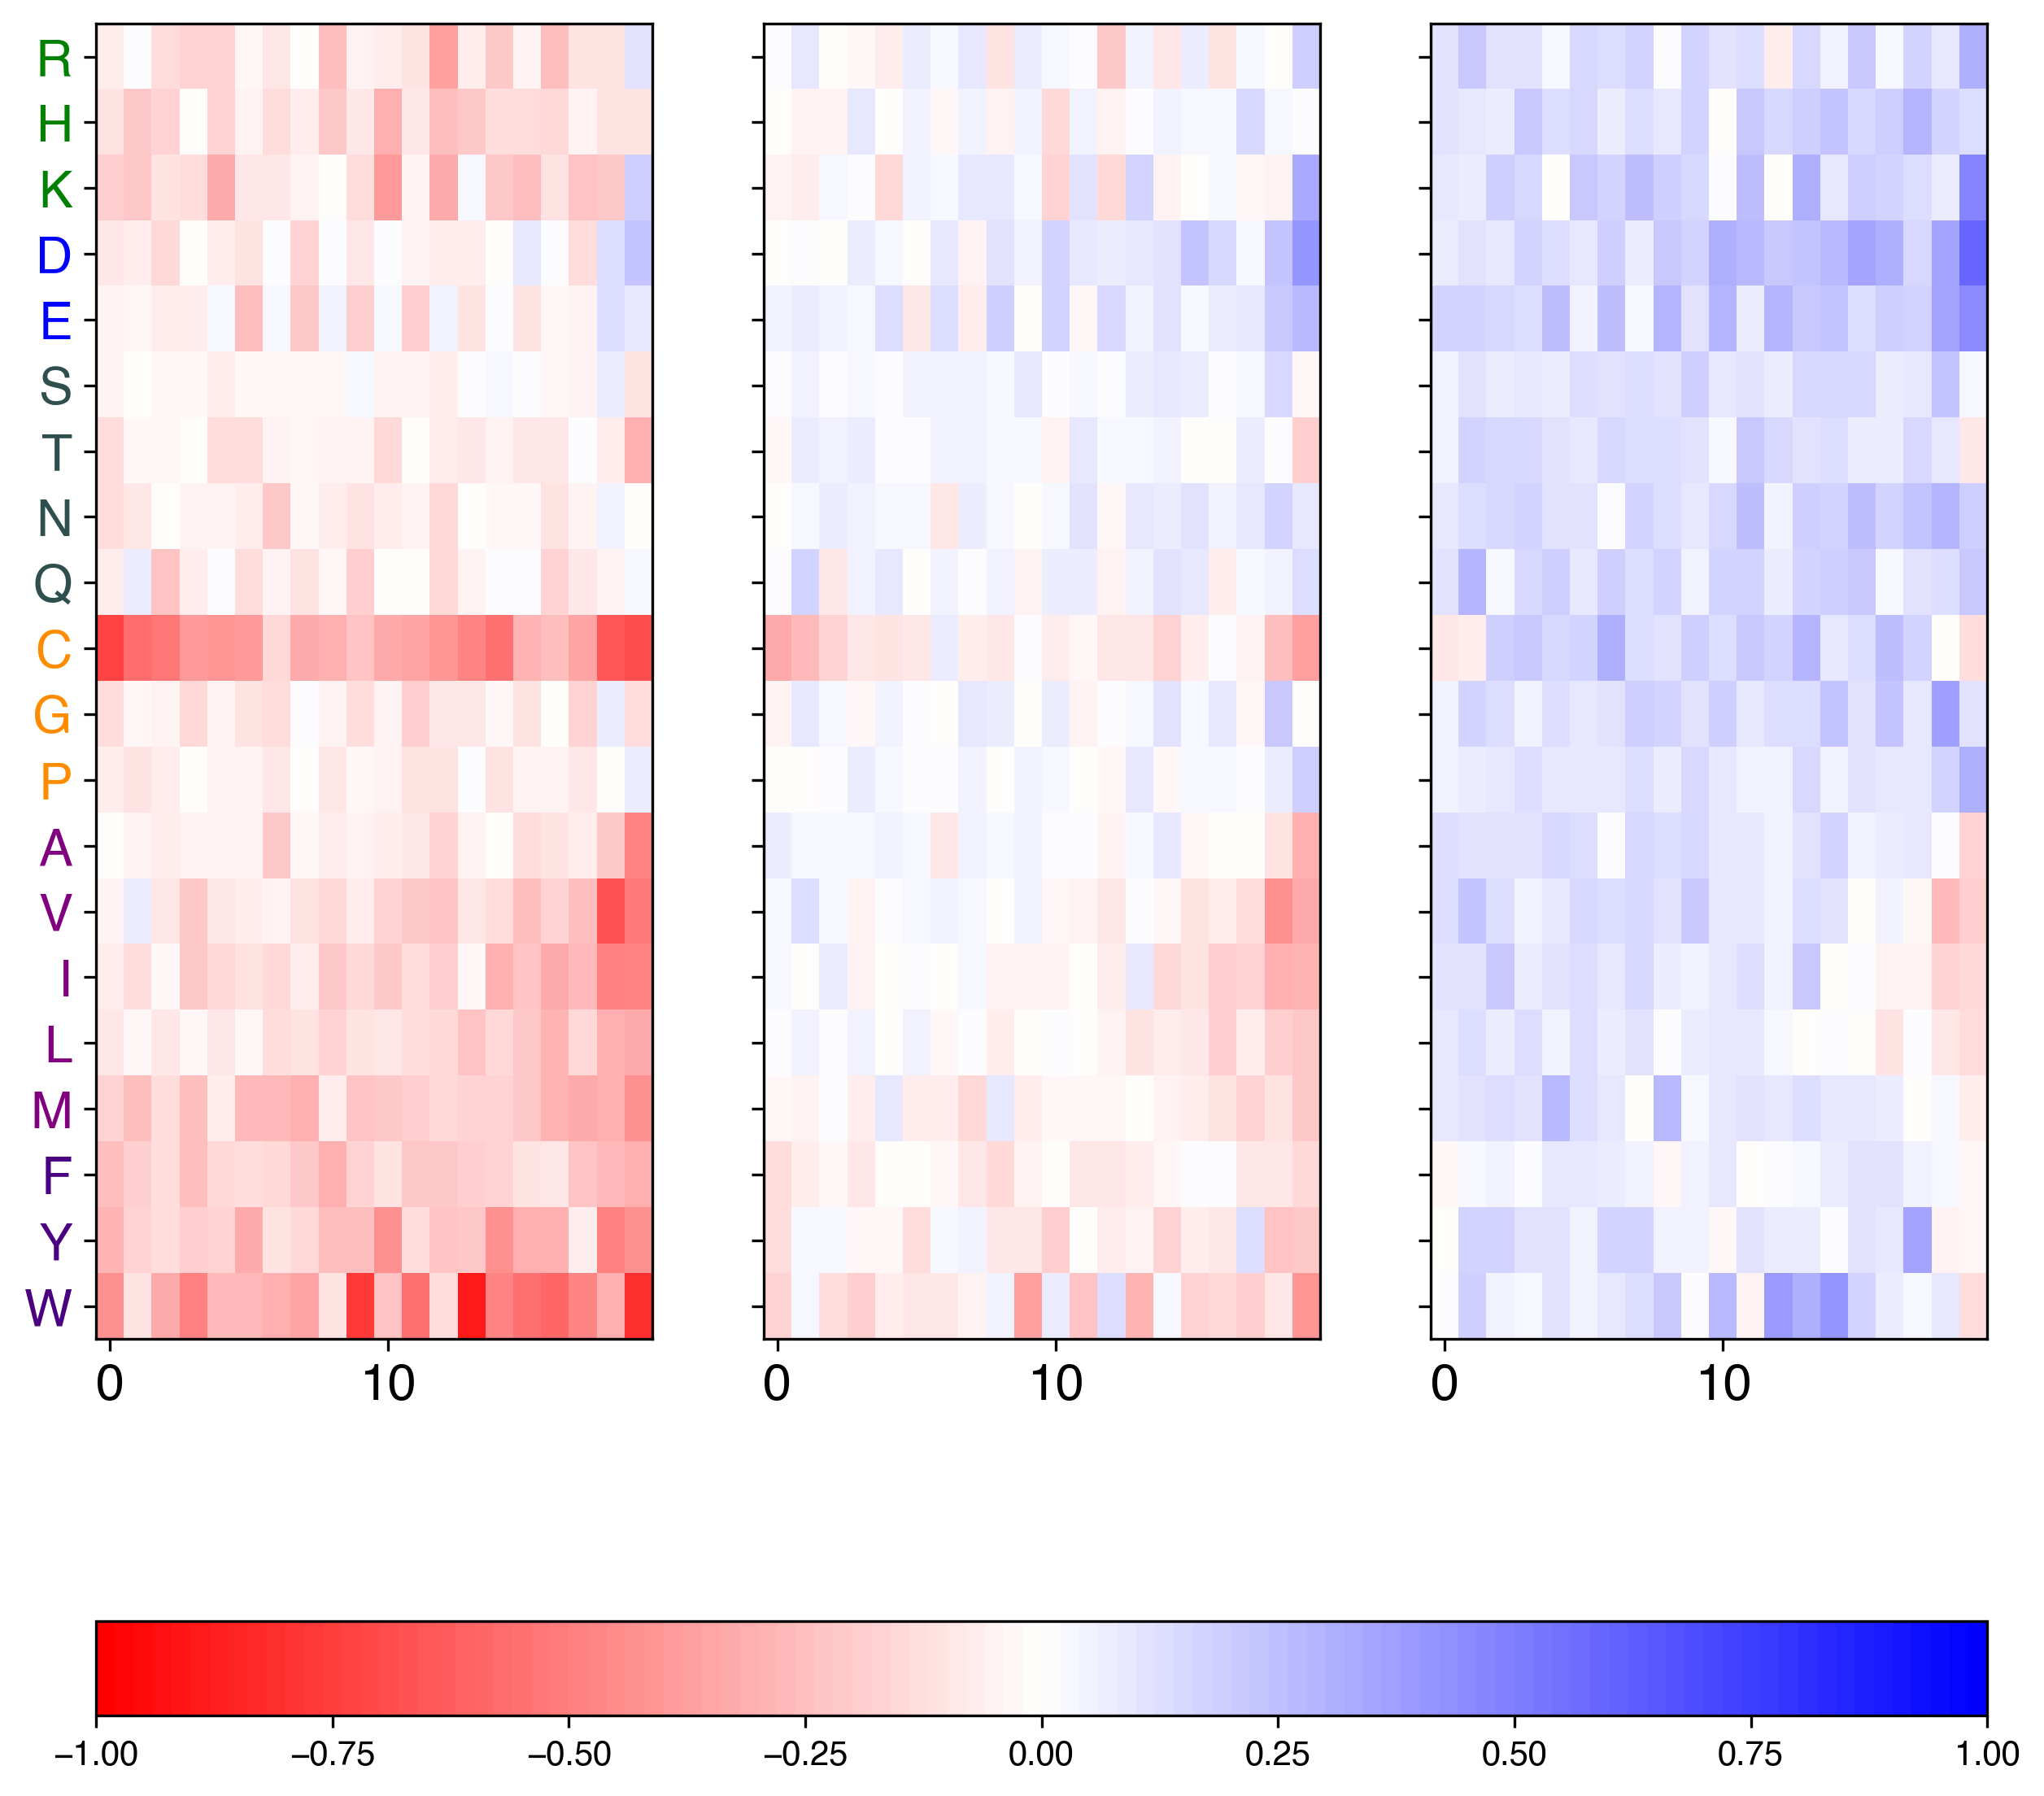

In [11]:
run_analysis(20, outfile_name="k20")

# Kernel size of 30

100%|██████████| 200/200 [00:00<00:00, 698.06it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Bootstrap variance 0.002878178346419005
Seed variance 0.004660815778493274


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 30, 20) (1, 30, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


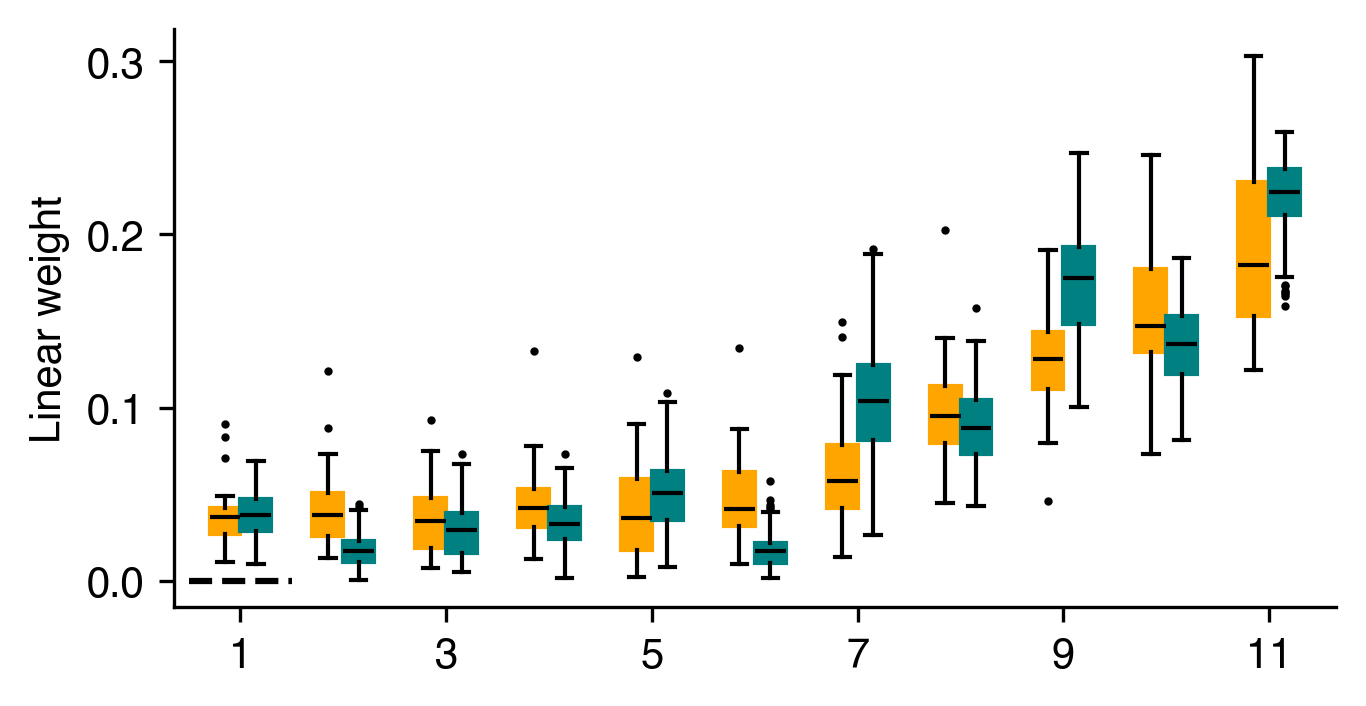

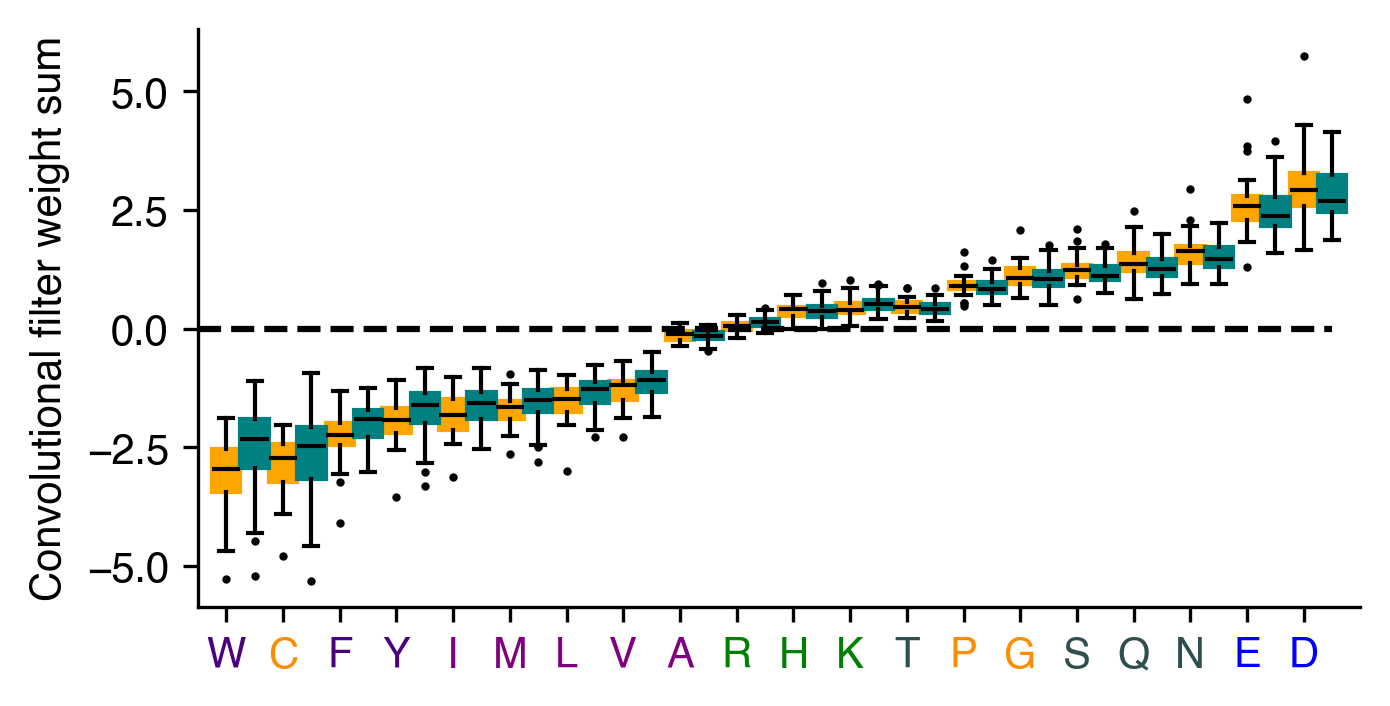

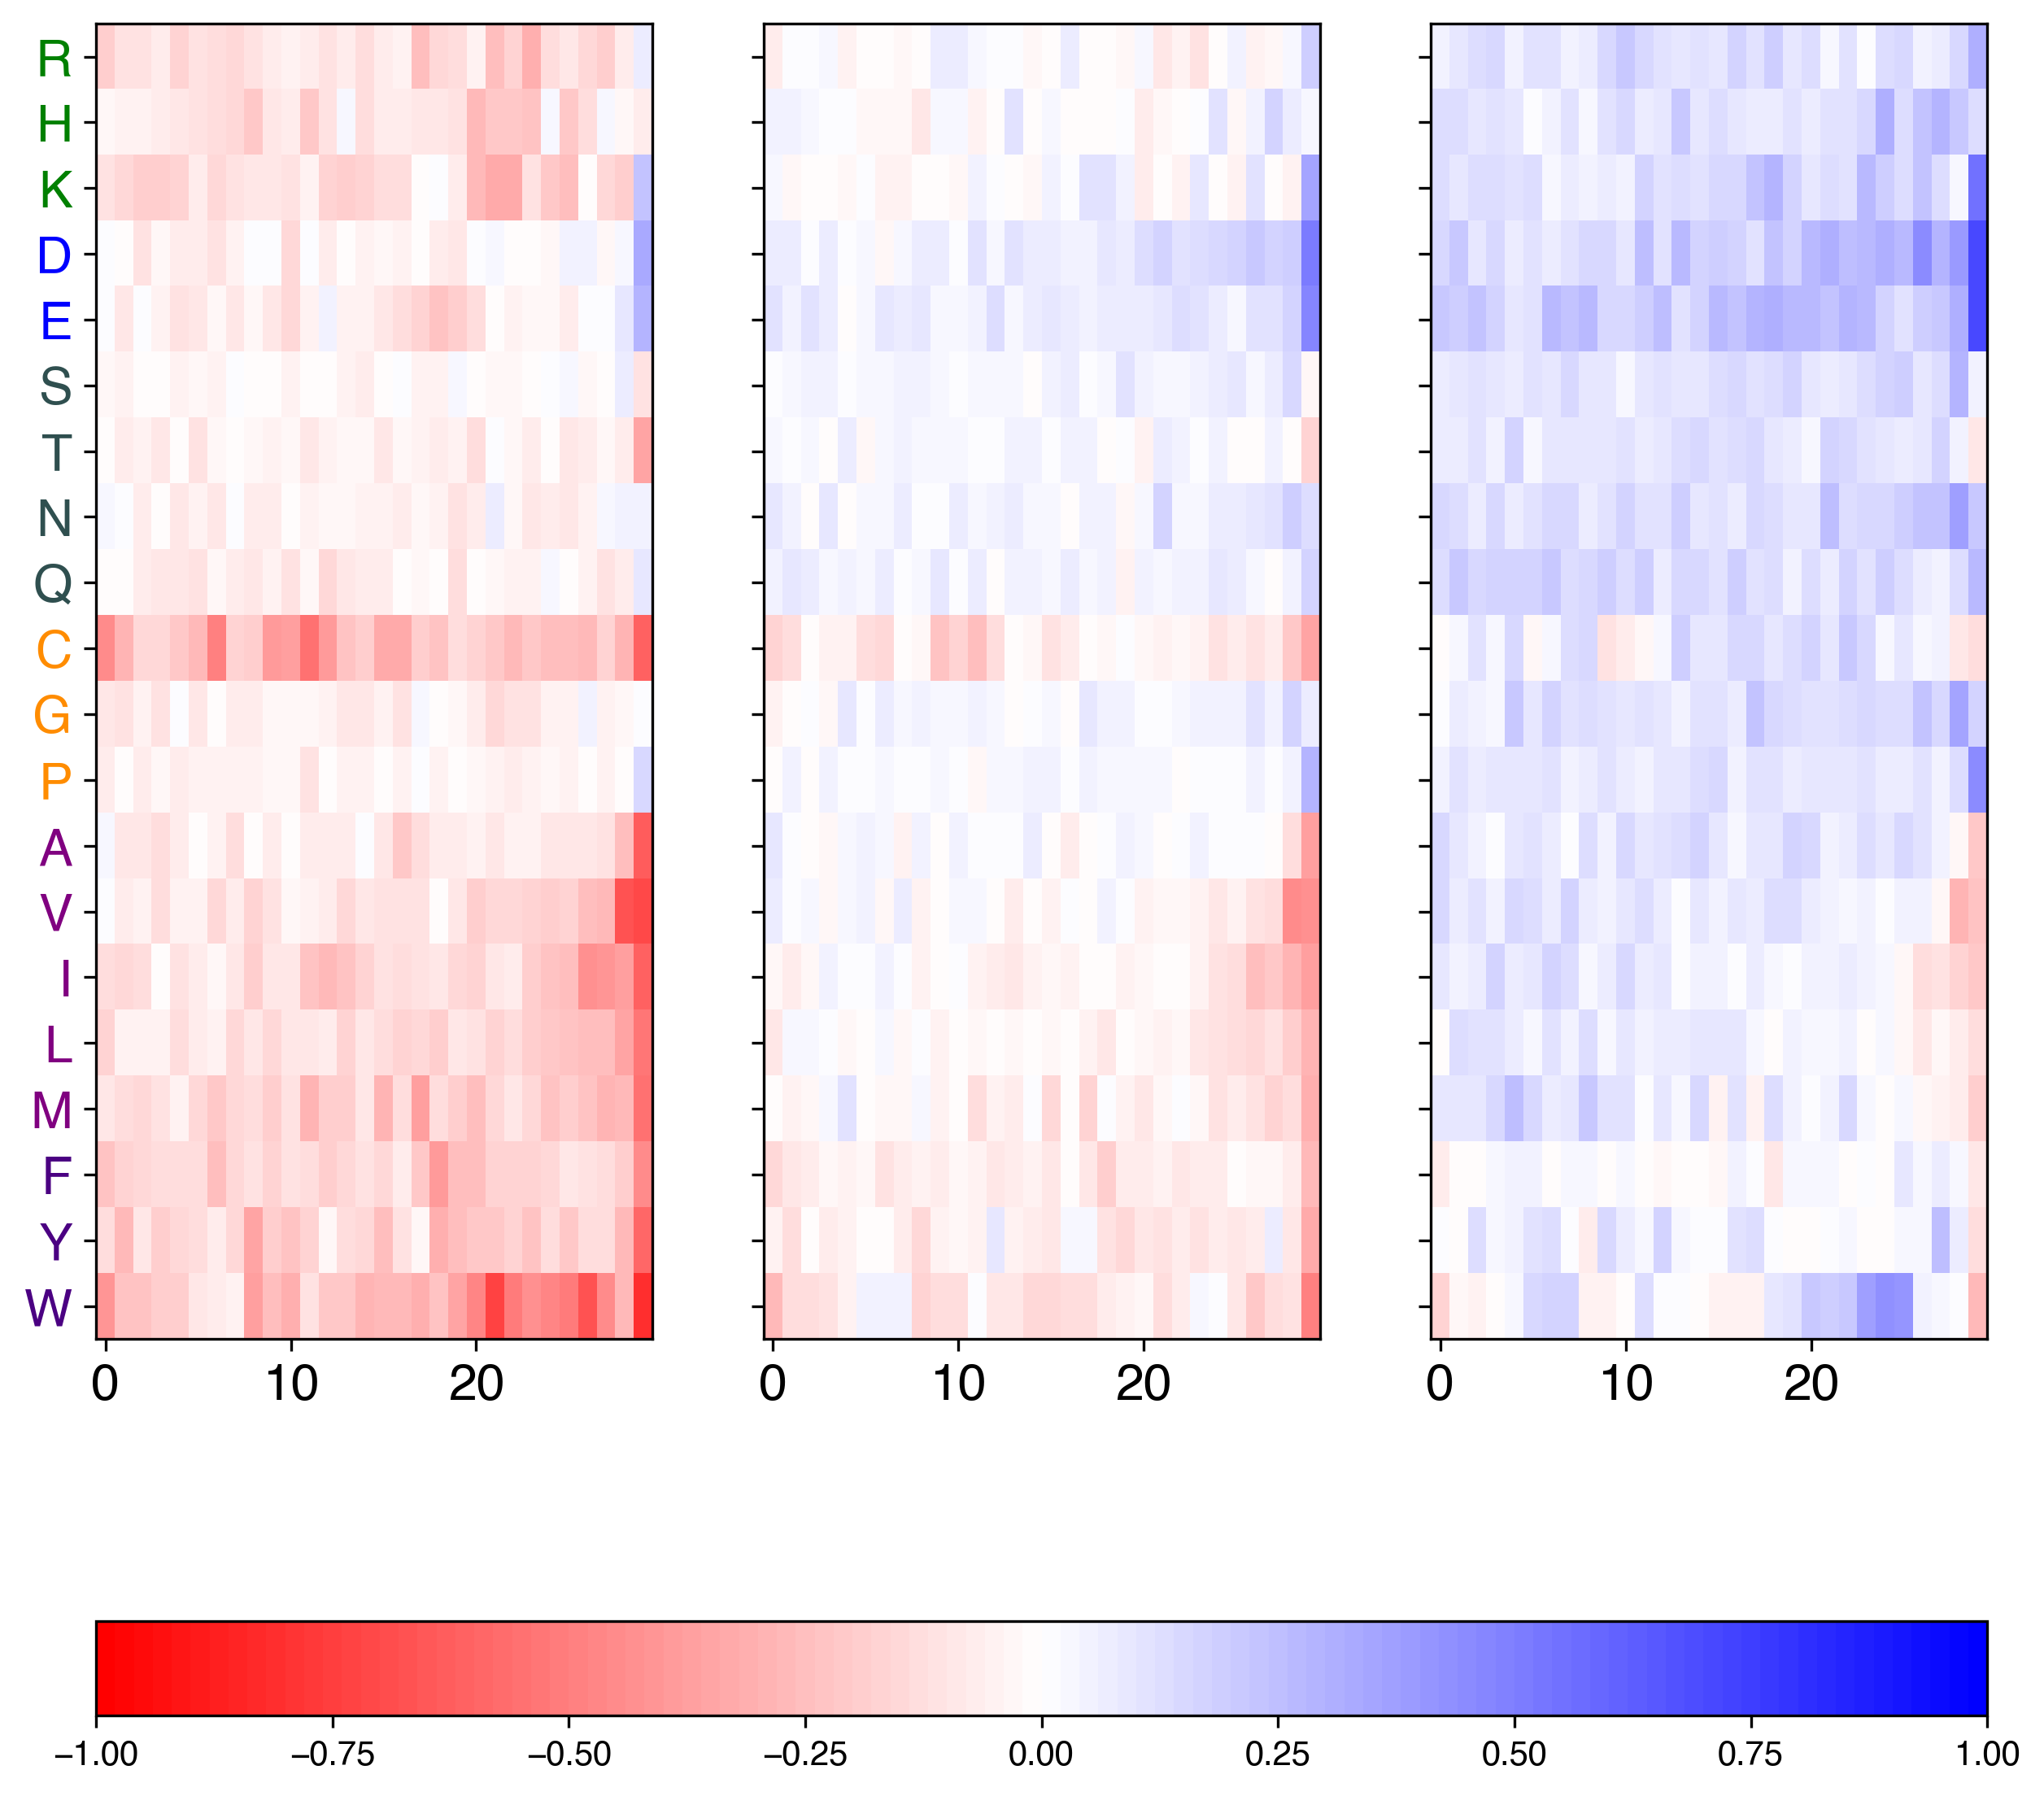

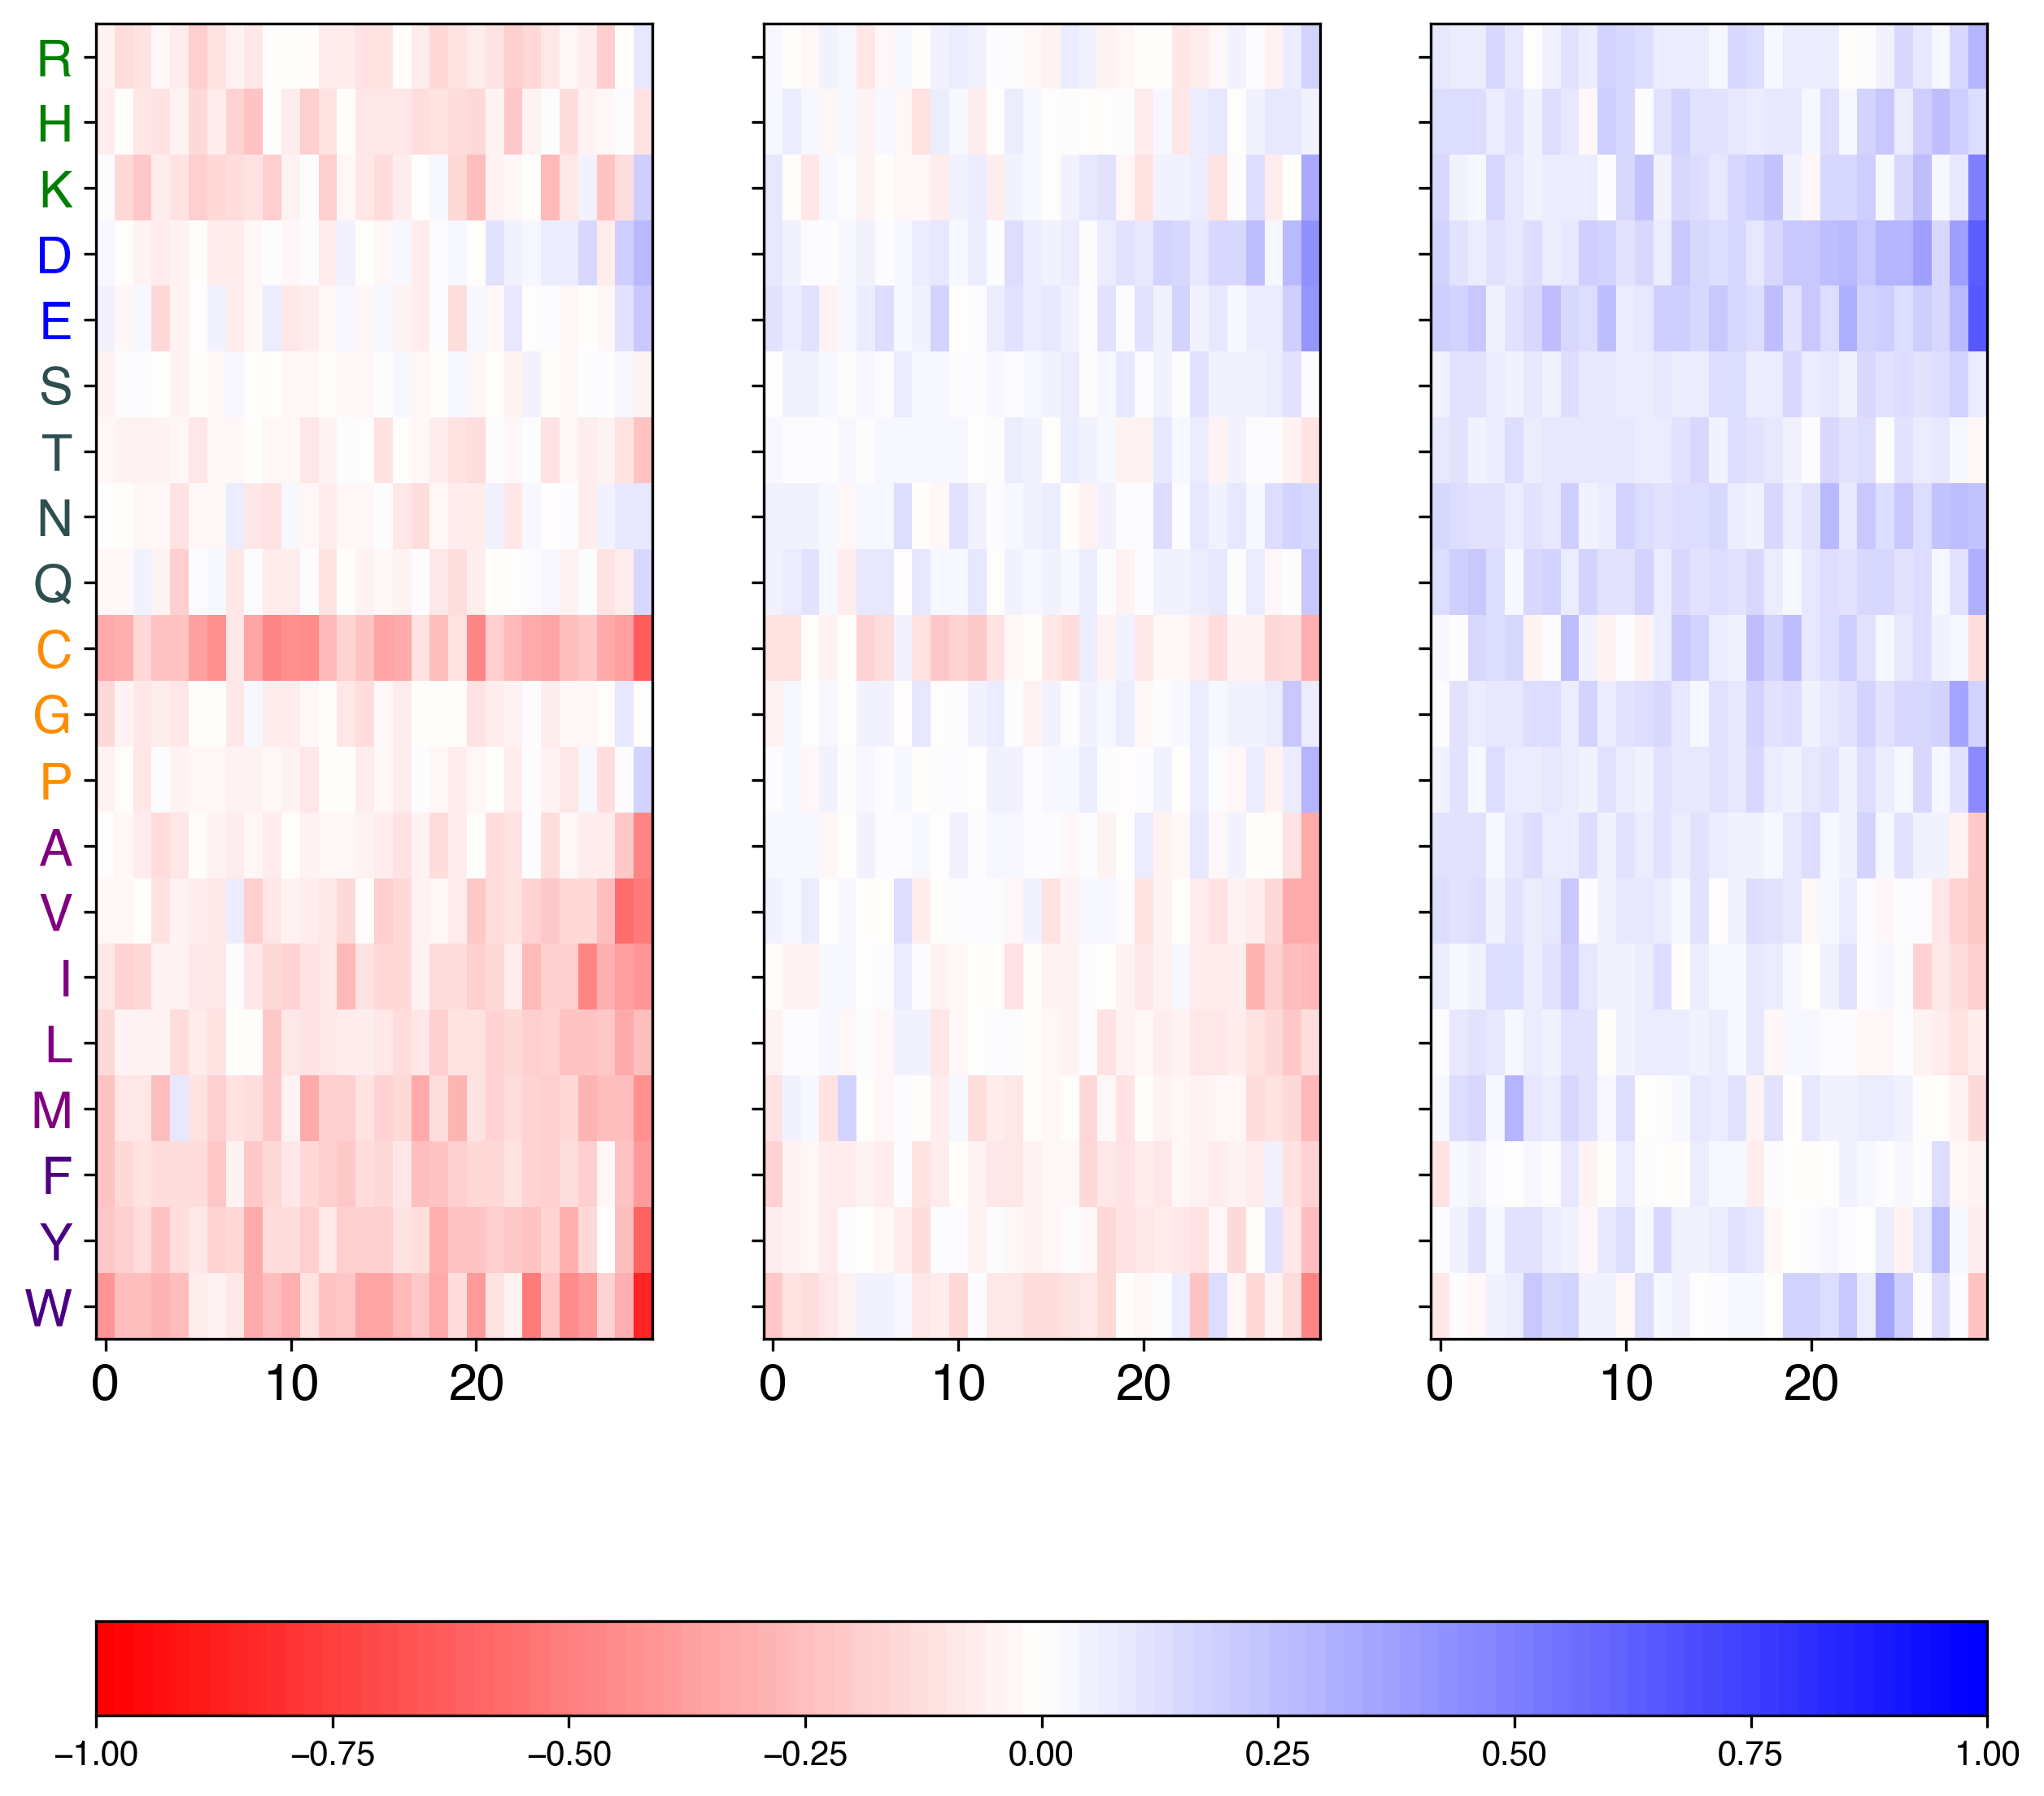

In [12]:
run_analysis(30, outfile_name="k30")

# K = 40

100%|██████████| 200/200 [00:00<00:00, 584.19it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Bootstrap variance 0.0018511367534104976
Seed variance 0.09269402829284594


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(1, 40, 20) (1, 40, 20)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


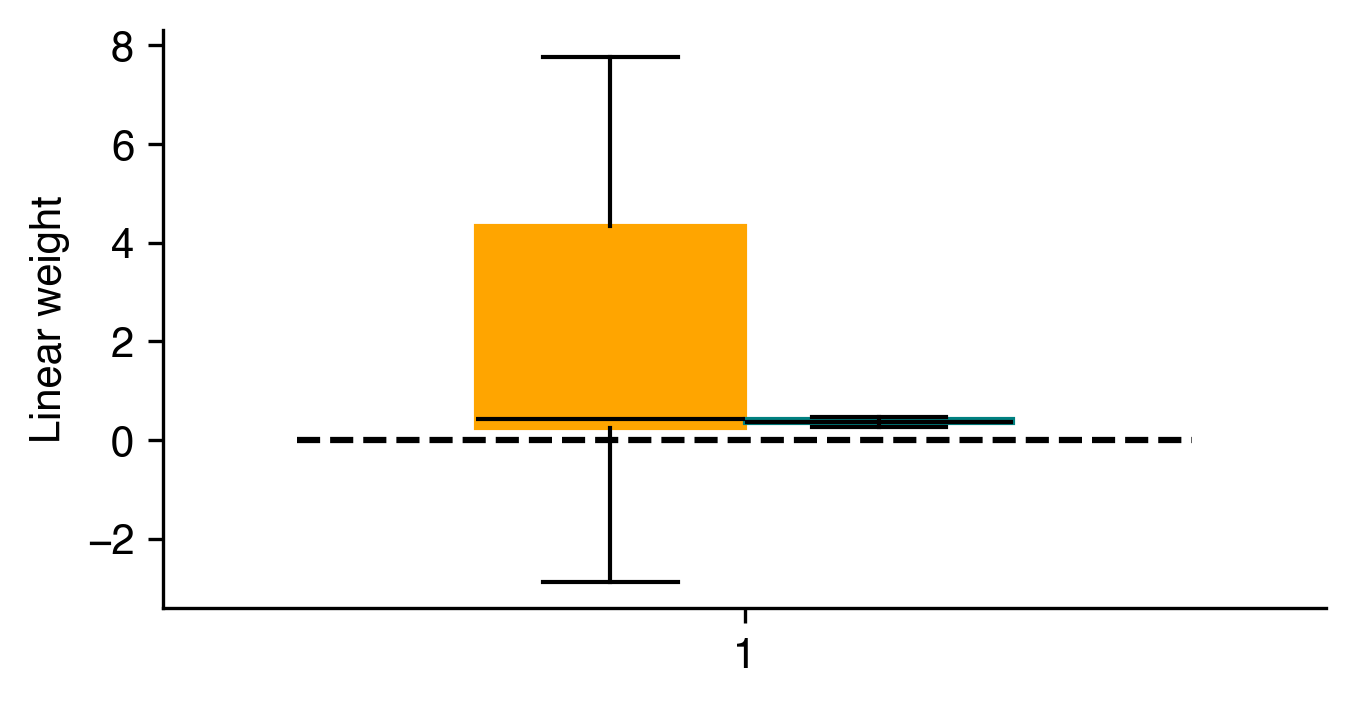

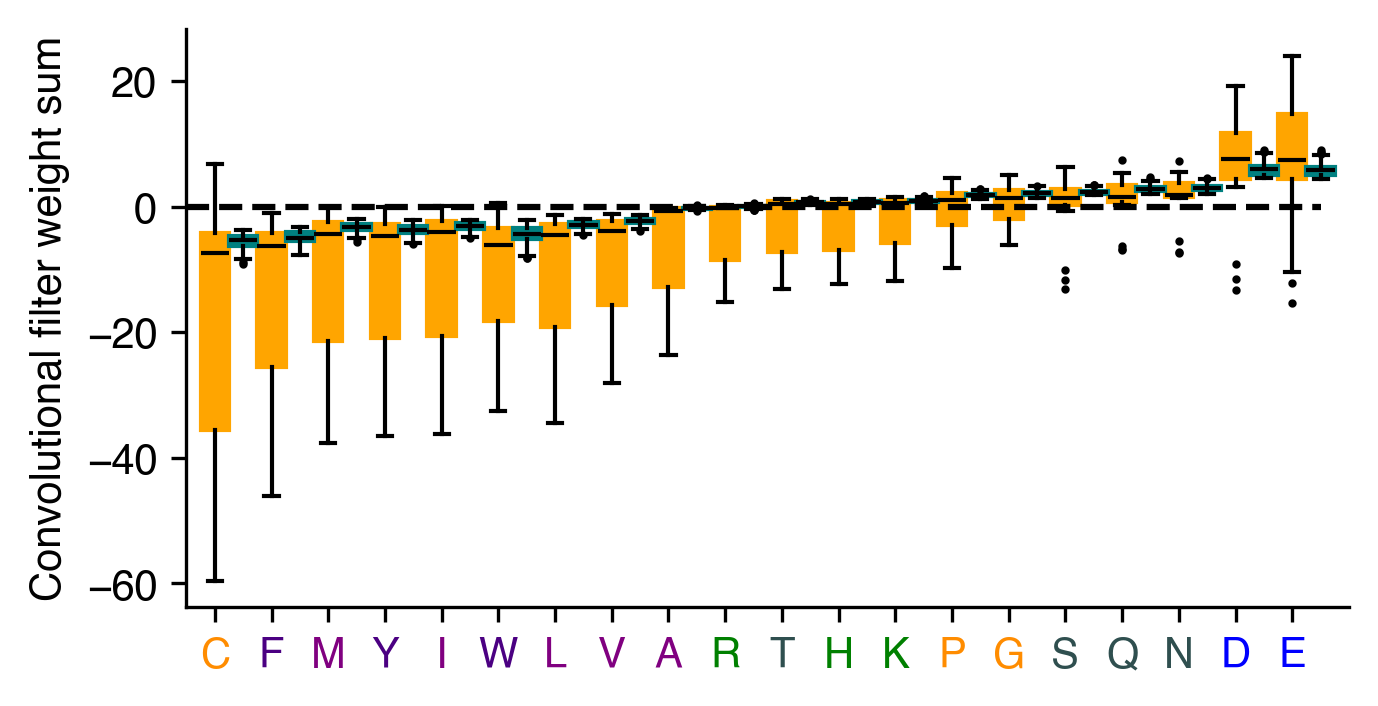

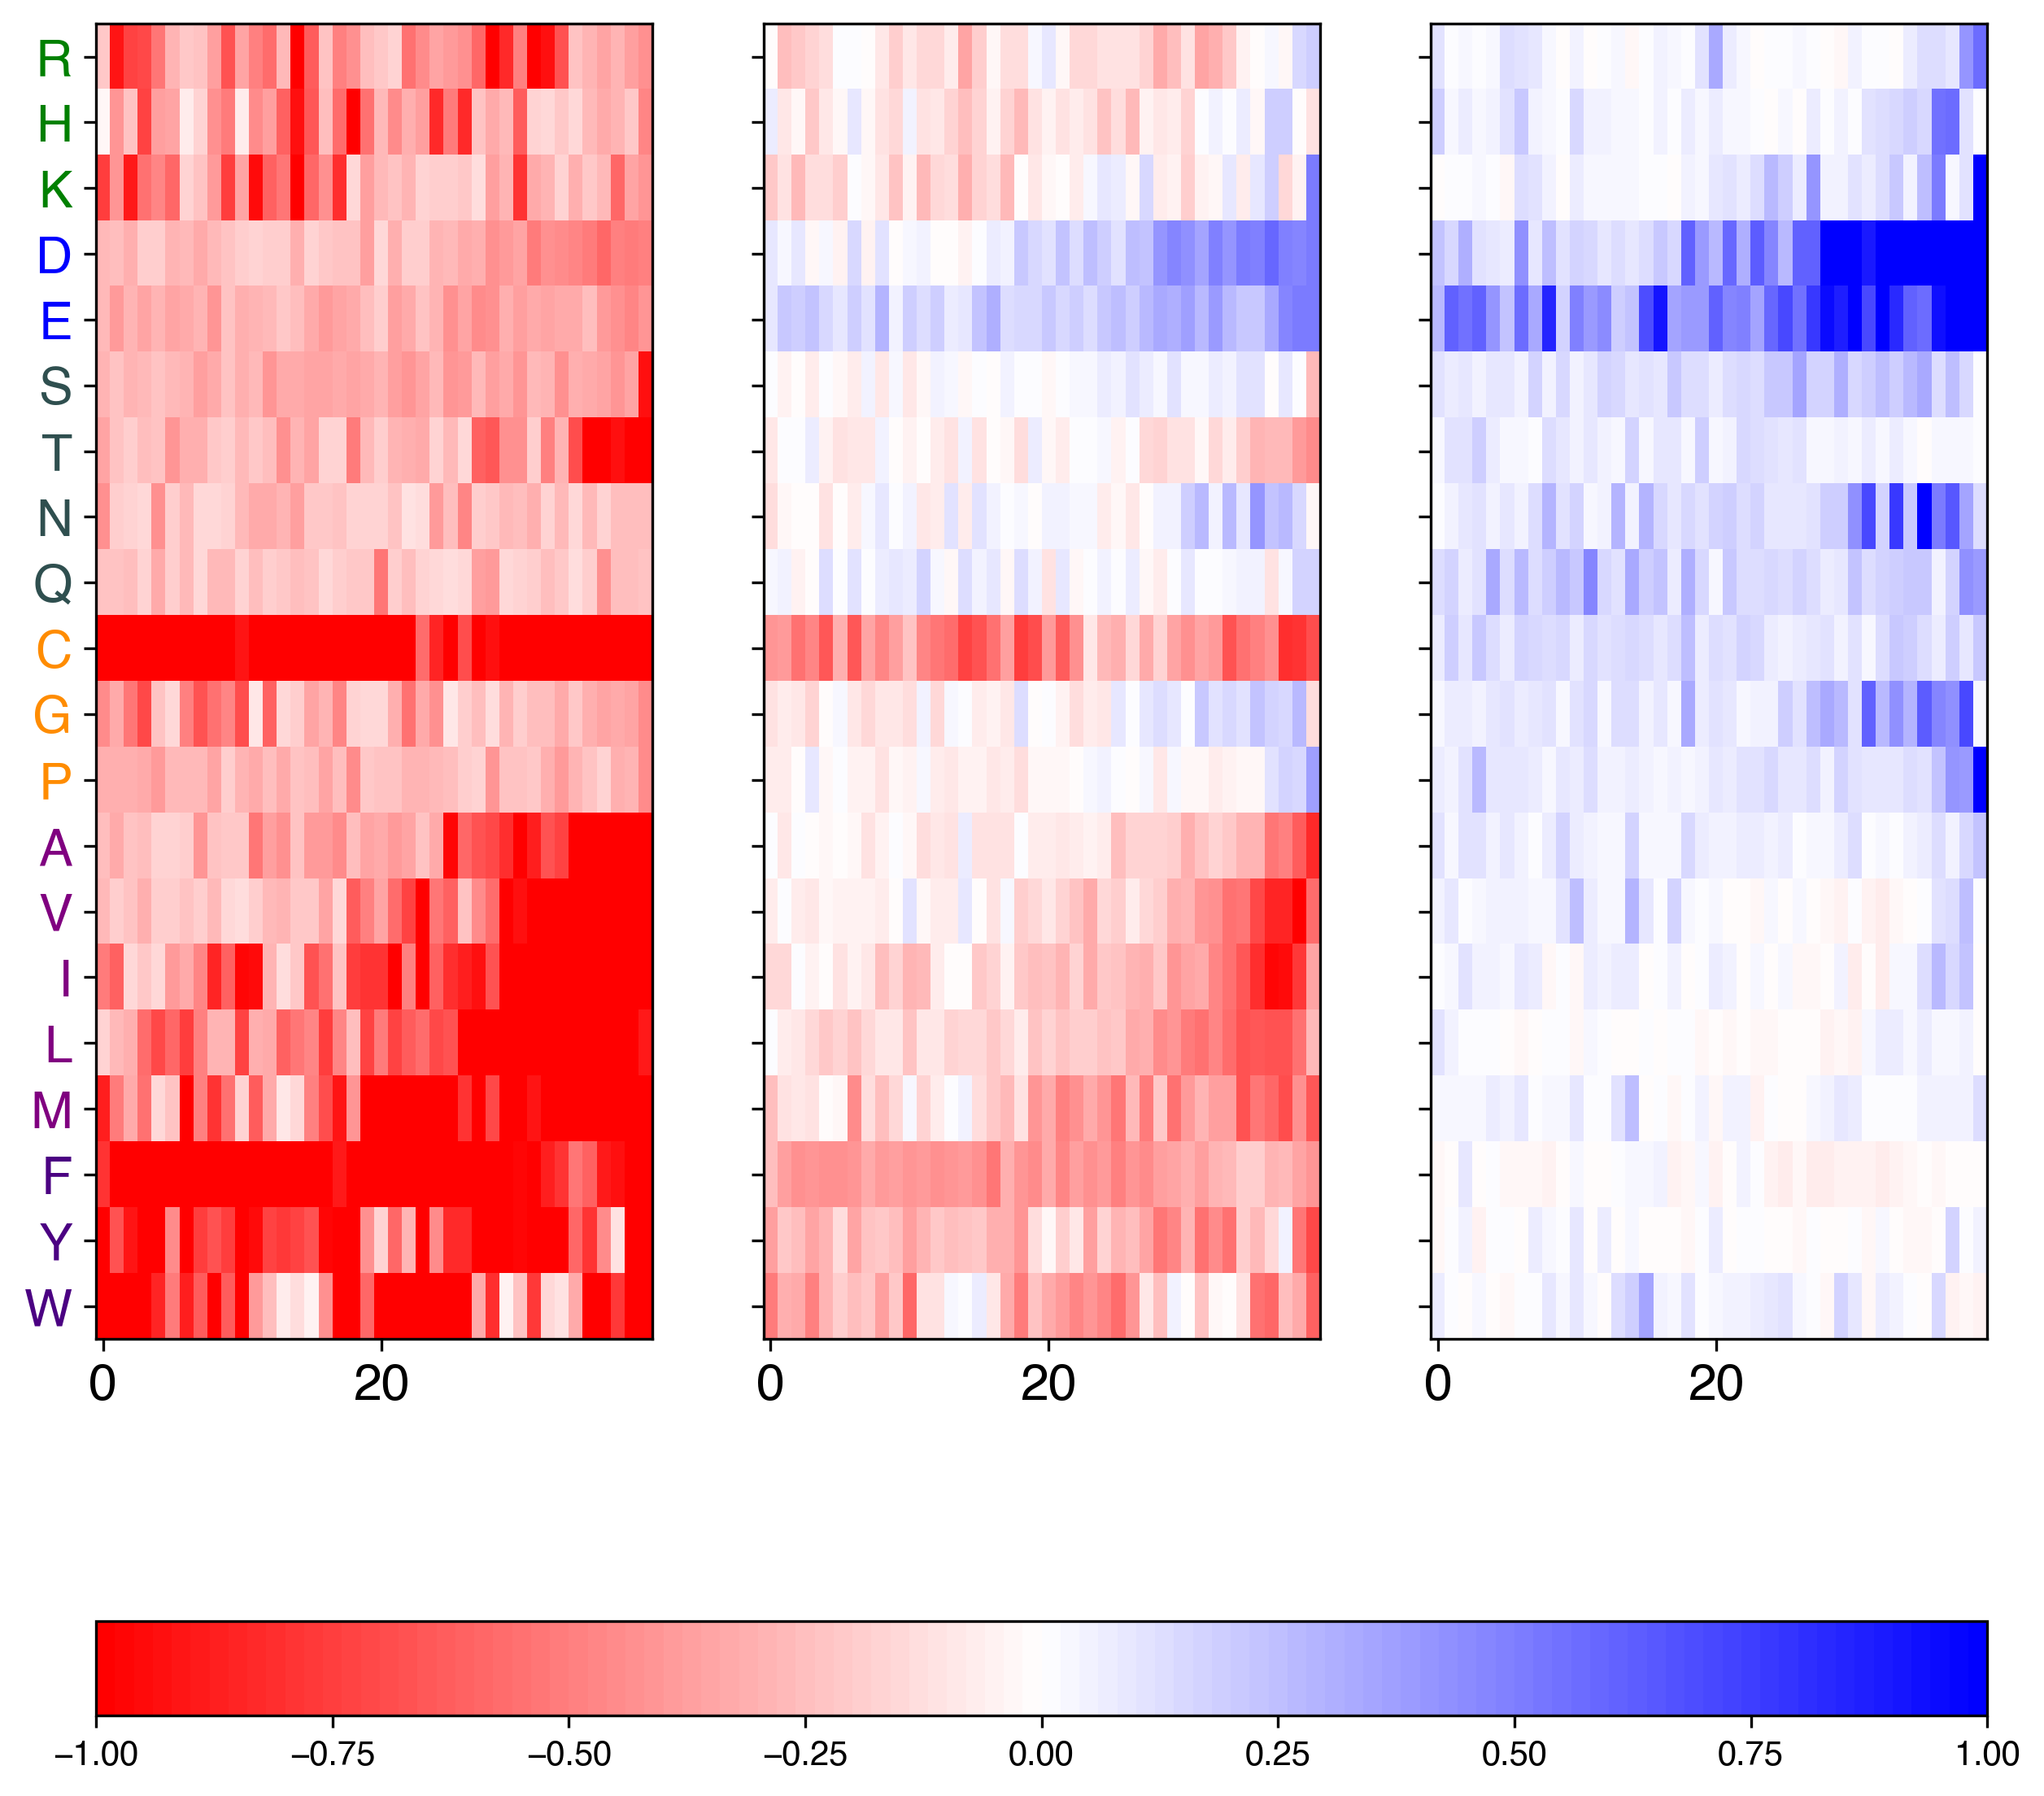

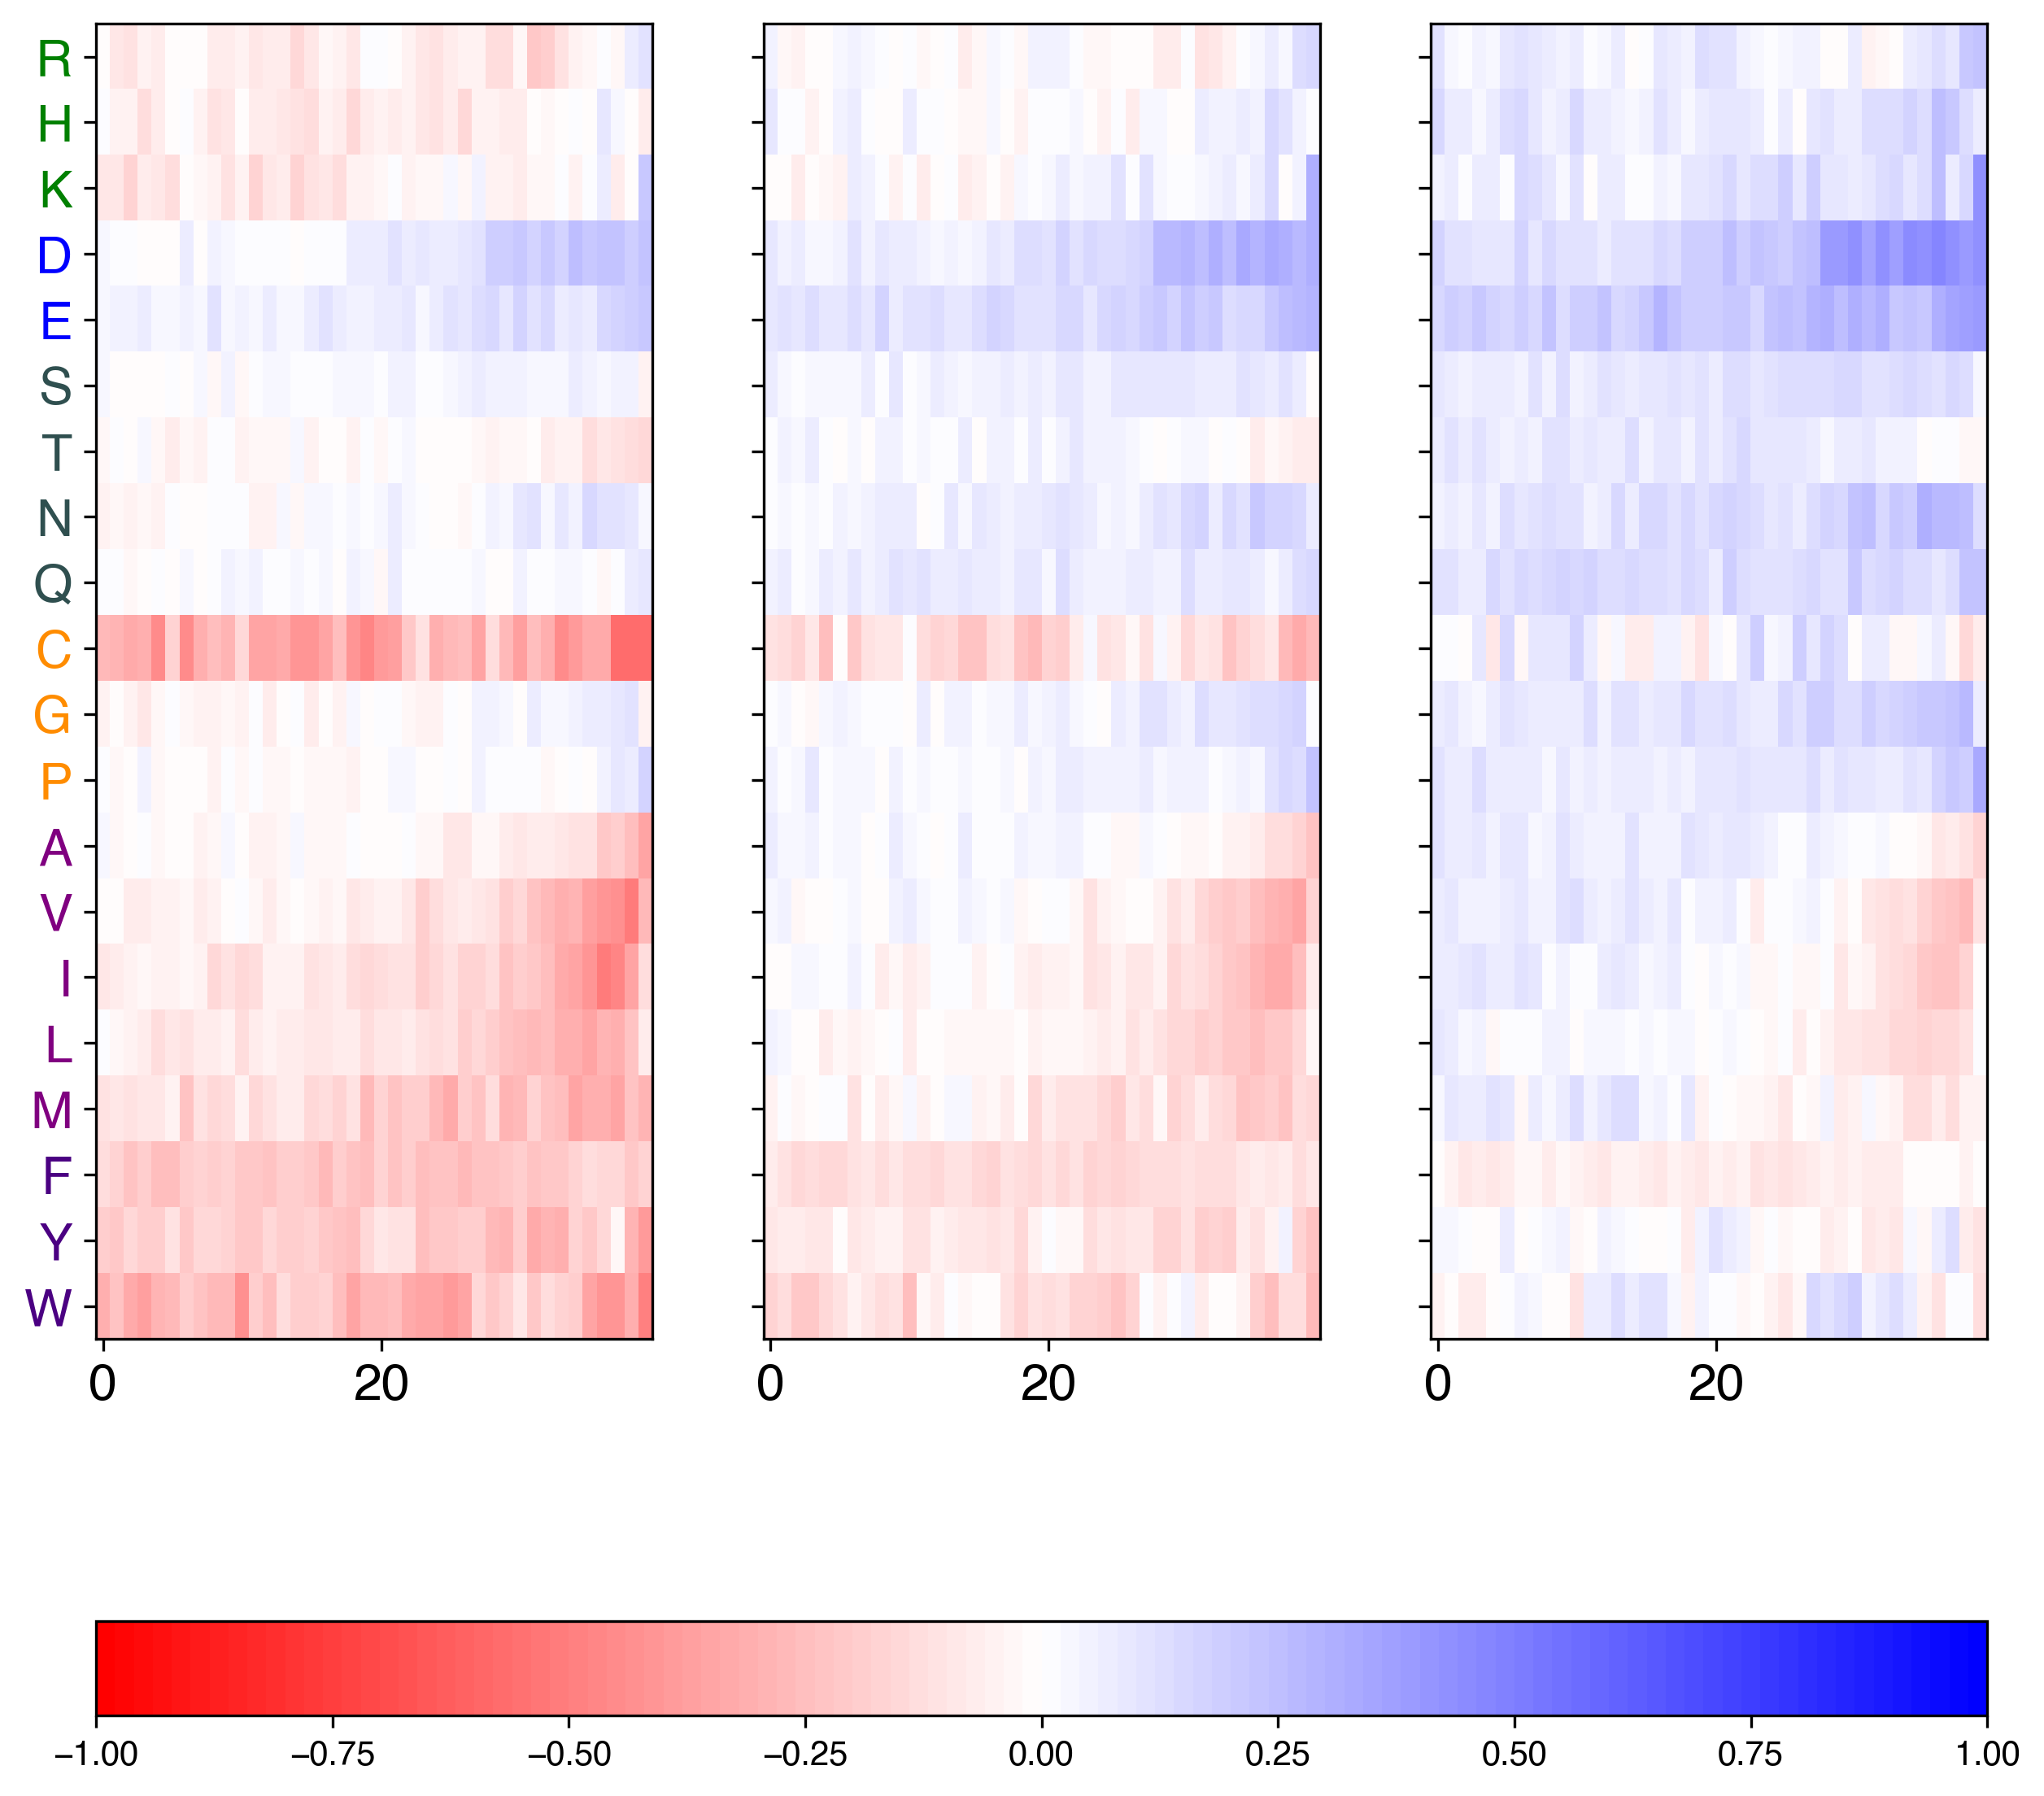

In [13]:
run_analysis(40, outfile_name="k40")

# Heatmap plots

In [92]:
def make_all_weight_heatmaps(k, model_results, bootstrap_results): 
    aa_order= ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    # Seed weight arrays
    seed_conv1_arr, seed_linear1_arr = get_weights_array(model_results, k_size=k, num_bootstraps=1, num_seeds=30, two_state=False, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')

    neg1_mask = (seed_linear1_arr < 0).any(axis=-1)
    neg1_mask = neg1_mask.reshape(30)


    negative1_conv1_filters = seed_conv1_arr[:, neg1_mask, :, :]

    pos_conv1_filters = seed_conv1_arr[:, ~neg1_mask, :, :]

    lim = max(seed_conv1_arr.min(), seed_conv1_arr.max())

    # First plot -- Seed K1
    fig, axs = plt.subplots(2, 20, figsize=(20, 4), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(0, 20):
        cax = axs[0, i].imshow(np.concatenate([pos_conv1_filters[0, :, :, i], negative1_conv1_filters[0, :, :, i]]), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
        axs[0, i].set_xticks([])
        axs[0, i].set_xlabel(aa_order[i])

        sim_matrix = cosine_similarity(seed_conv1_arr[0, :, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[1, i].hist(lower_vals)
        axs[1, i].text(0.05, 0.7, f"{np.abs(lower_vals).mean():.2}", transform=axs[1, i].transAxes)
        axs[1, i].set_xlabel(aa_order[i])
        if i != 0:
            axs[0, i].tick_params(labelleft=False)
            axs[1,i].sharey(axs[1,0])
            axs[1,i].sharex(axs[1,0])
            # axs[1, i].set_yticks([])
            axs[1, i].tick_params(labelleft=False)
        else:
            axs[0, 0].set_ylabel("NNs")
            axs[1, 0].set_ylabel("Count")
            axs[1, 0].set_xlim(-1, 1)


    fig.supxlabel("Cosine similarity between weights per amino acid", y=-0.1)
    fig.suptitle(r"NN weights per amino acid for predicting abundance. NNs were trained with different seeds")

    # fig.tight_layout()
    plt.savefig(f"figures/for_revision/k{k}_conv1_abund_seed_all_weights.pdf", format='pdf', bbox_inches='tight')


    # bootstrap weight arrays
    boostrap_conv1_arr, bootstrap_linear1_arr = get_weights_array(bootstrap_results[bootstrap_results['seed'] == 830654943], k_size=k, num_bootstraps=200, num_seeds=1, two_state=False, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')

    neg1_mask = (bootstrap_linear1_arr < 0).any(axis=-1)
    neg1_mask = neg1_mask.reshape(200)

    negative1_conv1_filters = boostrap_conv1_arr[neg1_mask, :, :, :]
    pos_conv1_filters = boostrap_conv1_arr[~neg1_mask, :, :, :]

    lim = max(boostrap_conv1_arr.min(), boostrap_conv1_arr.max())

    # Plotting bootstrap K1
    fig, axs = plt.subplots(2, 20, figsize=(20, 4), gridspec_kw={'height_ratios': [3, 1]})

    for i in range(0, 20):
        cax = axs[0, i].imshow(np.concatenate([pos_conv1_filters[:, 0, :, i], negative1_conv1_filters[:, 0, :, i]]), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
        axs[0, i].set_xticks([])
        axs[0, i].set_xlabel(aa_order[i])

        sim_matrix = cosine_similarity(boostrap_conv1_arr[:, 0, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[1, i].hist(lower_vals)
        axs[1, i].text(0.05, .7, f"{np.abs(lower_vals).mean():.2}", transform=axs[1, i].transAxes)
        axs[1, i].set_xlabel(aa_order[i])
        if i != 0:
            axs[0, i].tick_params(labelleft=False)
            axs[1,i].sharey(axs[1,0])
            axs[1,i].sharex(axs[1,0])
            # axs[1, i].set_yticks([])
            axs[1, i].tick_params(labelleft=False)
        else:
            axs[0, 0].set_ylabel("NNs")
            axs[1, 0].set_ylabel("Count")
            axs[1, 0].set_xlim(-1, 1)


    fig.supxlabel("Cosine similarity between weights per amino acid", y=-0.1)
    fig.suptitle(r"NN weights per amino acid for predicting abundance. NNs were trained with bootstrapped data")

    # fig.tight_layout()
    plt.savefig(f"figures/for_revision/k{k}_conv1_abund_bootstrap_all_weights.pdf", format='pdf', bbox_inches='tight')

    # Plotting all histograms
    fig, axs = plt.subplots(1, 20, figsize=(20, 1))
    bins = np.arange(-1.1, 1.1, 0.1)
    for i in range(0, 20):
        sim_matrix = cosine_similarity(boostrap_conv1_arr[:, 0, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[i].hist(lower_vals, density=True, bins=bins, color='teal')
        axs[i].text(0.05, .6, f"{np.abs(lower_vals).mean():.2}", transform=axs[i].transAxes, color='teal')
        axs[i].set_xlabel(aa_order[i])
        if i != 0:
            axs[i].tick_params(labelleft=False)
            axs[i].sharey(axs[0])
            axs[i].sharex(axs[0])
            # axs[1, i].set_yticks([])
            axs[i].tick_params(labelleft=False)
        else:
            axs[0].set_ylabel("Count")
            axs[0].set_xlim(-1, 1)

        sim_matrix = cosine_similarity(seed_conv1_arr[0, :, :, i])
        lower_vals = sim_matrix[np.tril_indices(sim_matrix.shape[0], k=-1)]
        axs[i].hist(lower_vals, density=True, bins=bins, color='orange', alpha=0.5)
        axs[i].text(0.05, .8, f"{np.abs(lower_vals).mean():.2}", transform=axs[i].transAxes, color='orange')
        axs[i].set_xlabel(aa_order[i])
        if i != 0:
            axs[i].tick_params(labelleft=False)
            axs[i].sharey(axs[0])
            axs[i].sharex(axs[0])
            # axs[1, i].set_yticks([])
            axs[i].tick_params(labelleft=False)
        else:
            axs[0].set_ylabel("Count")
            axs[0].set_xlim(-1, 1)


    fig.supxlabel("Cosine similarity between weights per amino acid", y=-0.5)
    fig.suptitle(f"Filter size = {k}", y=1.1)

    # fig.tight_layout()
    plt.savefig(f"figures/for_revision/k{k}_abund_conv1_histograms.pdf", format='pdf', bbox_inches='tight')


def make_c_term_weight_heatmaps(model_results, bootstrap_results): 
    aa_order= ["R","H","K","D","E","S","T","N","Q","C","G","P","A","V","I","L","M","F","Y","W"]

    # Colors for AA labels
    colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

    # Seed weight arrays
    pos_seed_weights = []
    neg_seed_weights = []

    pos_bootstrap_weights = []
    neg_bootstrap_weights = []
    for k in [5, 10, 15, 20, 30, 40]:
        seed_conv1_arr, seed_linear1_arr = get_weights_array(model_results, k_size=k, num_bootstraps=1, num_seeds=30, two_state=False, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')

        neg1_mask = (seed_linear1_arr < 0).any(axis=-1)
        neg1_mask = neg1_mask.reshape(30)

        negative1_conv1_filters = seed_conv1_arr[:, neg1_mask, -1, :]
        pos_conv1_filters = seed_conv1_arr[:, ~neg1_mask, -1, :]

        pos_seed_weights.append(pos_conv1_filters)
        neg_seed_weights.append(negative1_conv1_filters)

        boostrap_conv1_arr, bootstrap_linear1_arr = get_weights_array(bootstrap_results[bootstrap_results['seed'] == 830654943], k_size=k, num_bootstraps=200, num_seeds=1, two_state=False, abund_k=False, layer1='conv1.weight', layer2='linear1.weight')

        neg1_mask = (bootstrap_linear1_arr < 0).any(axis=-1)
        neg1_mask = neg1_mask.reshape(200)

        negative1_conv1_filters = boostrap_conv1_arr[neg1_mask, :, -1, :]
        pos_conv1_filters = boostrap_conv1_arr[~neg1_mask, :, -1, :]

        pos_bootstrap_weights.append(pos_conv1_filters)
        neg_bootstrap_weights.append(negative1_conv1_filters)
    
    print(len(neg_seed_weights))
    print(len(neg_bootstrap_weights))
    print(neg_bootstrap_weights)
    lim = max(seed_conv1_arr.min(), seed_conv1_arr.max())

    # First plot -- Seed K1
    fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 3))

    cax = ax1.imshow(np.concatenate(pos_seed_weights + neg_seed_weights, axis=1).T, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
    ax2.imshow(np.concatenate(neg_bootstrap_weights, axis=0).T.squeeze(1), cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)

    ax1.set_yticks(range(len(aa_order)), aa_order)  # Label x-axis with column names
    ax2.set_yticks(range(len(aa_order)), aa_order)
    
    # This is to color the amino acid labels
    for ytic in ax1.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax1.tick_params(axis='x', which='major', labelsize=15) 
    ax1.tick_params(axis='y', which='major', labelsize=8) 

    for ytic in ax2.get_yticklabels():
        if ytic.get_text() in colors.keys(): 
            ytic.set_color(colors[ytic.get_text()])
    ax2.tick_params(axis='x', which='major', labelsize=15) 
    ax2.tick_params(axis='y', which='major', labelsize=8) 

    fig.supxlabel("Neural network", y=-.1)
    fig.suptitle(r"Final position in convolutional filter for predicting abundance", y=1.1)

    ax1.set_title("Seeds")
    ax2.set_title("Bootstraps")

    plt.savefig(f"figures/for_revision/abund_final_pos_heatmaps.pdf", format='pdf', bbox_inches='tight')

100%|██████████| 200/200 [00:00<00:00, 1938.95it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


6
6
[array([[[0.123, 0.081, 0.400, 0.336, 0.377, 0.001, -0.135, 0.162, 0.196,
         -0.362, 0.098, 0.138, -0.164, -0.252, -0.232, -0.235, -0.101,
         -0.070, -0.168, -0.415]],

       [[0.108, 0.020, 0.277, 0.219, 0.293, 0.063, -0.077, 0.156, 0.160,
         -0.396, 0.069, 0.131, -0.152, -0.164, -0.132, -0.225, -0.088,
         -0.068, -0.256, -0.536]],

       [[0.074, 0.082, 0.145, 0.221, 0.252, 0.038, 0.022, 0.188, 0.098,
         -0.522, -0.036, 0.107, -0.086, -0.128, -0.101, -0.142, -0.038,
         -0.143, -0.117, -0.266]],

       [[0.103, 0.076, 0.408, 0.279, 0.397, 0.022, -0.063, 0.099, 0.100,
         -0.621, 0.133, 0.186, -0.170, -0.162, -0.193, -0.181, -0.117,
         -0.120, -0.206, -1.002]]]), array([[[0.049, 0.053, 0.032, 0.134, 0.213, -0.037, -0.102, 0.097,
         0.153, -0.304, 0.082, -0.035, -0.112, -0.228, -0.190, -0.235,
         -0.162, -0.021, -0.145, -0.421]]]), array([[[0.189, 0.074, 0.222, 0.395, 0.328, 0.041, -0.078, 0.184, 0.193,
         -0.568, 0

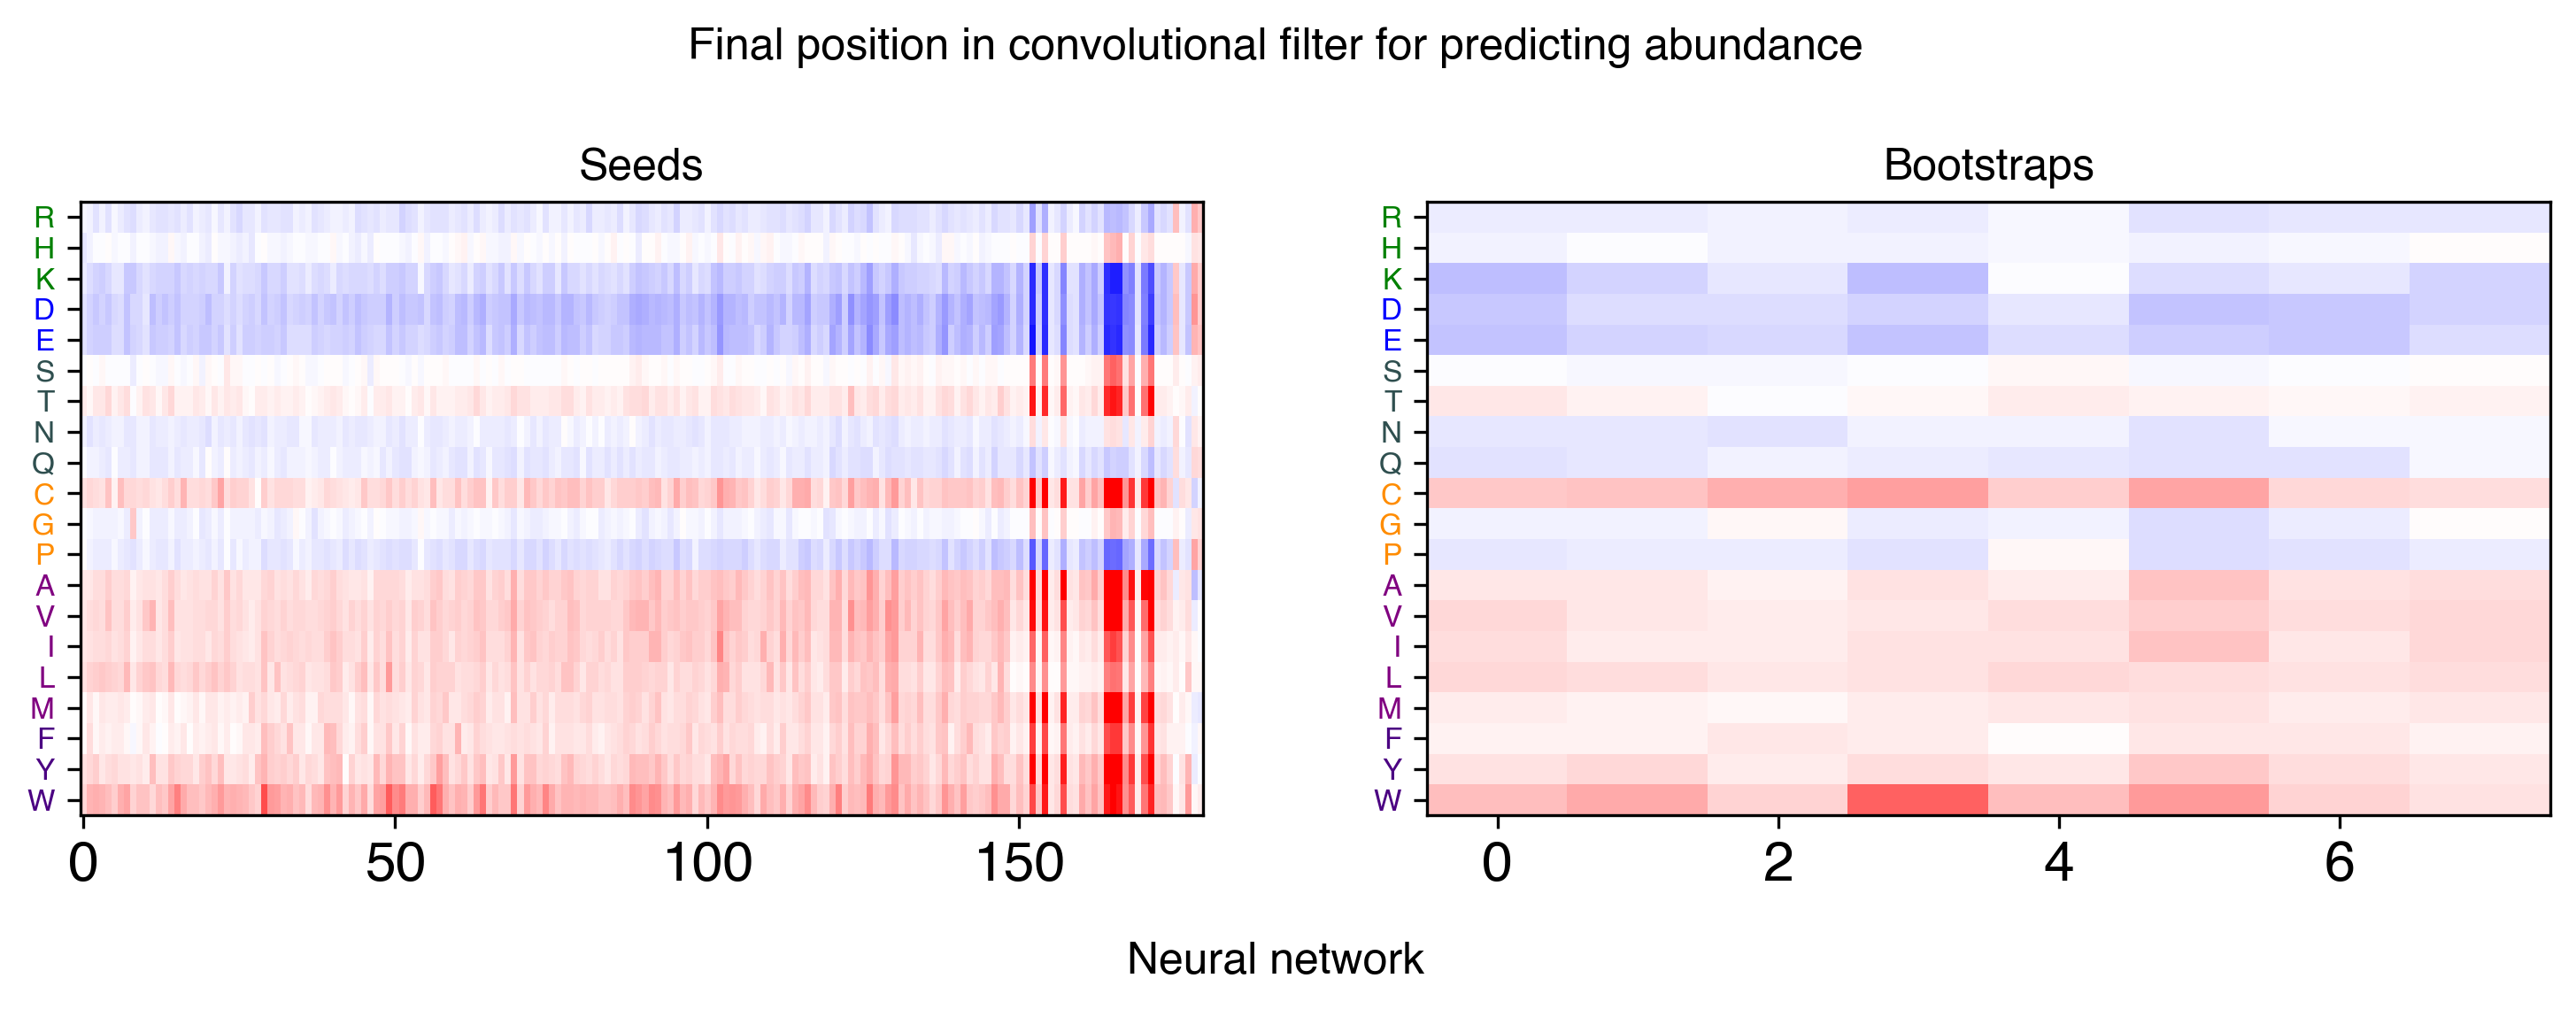

In [93]:
make_c_term_weight_heatmaps(simple_model_results, bootstrap_results)

100%|██████████| 30/30 [00:00<00:00, 912.21it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 1212.97it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


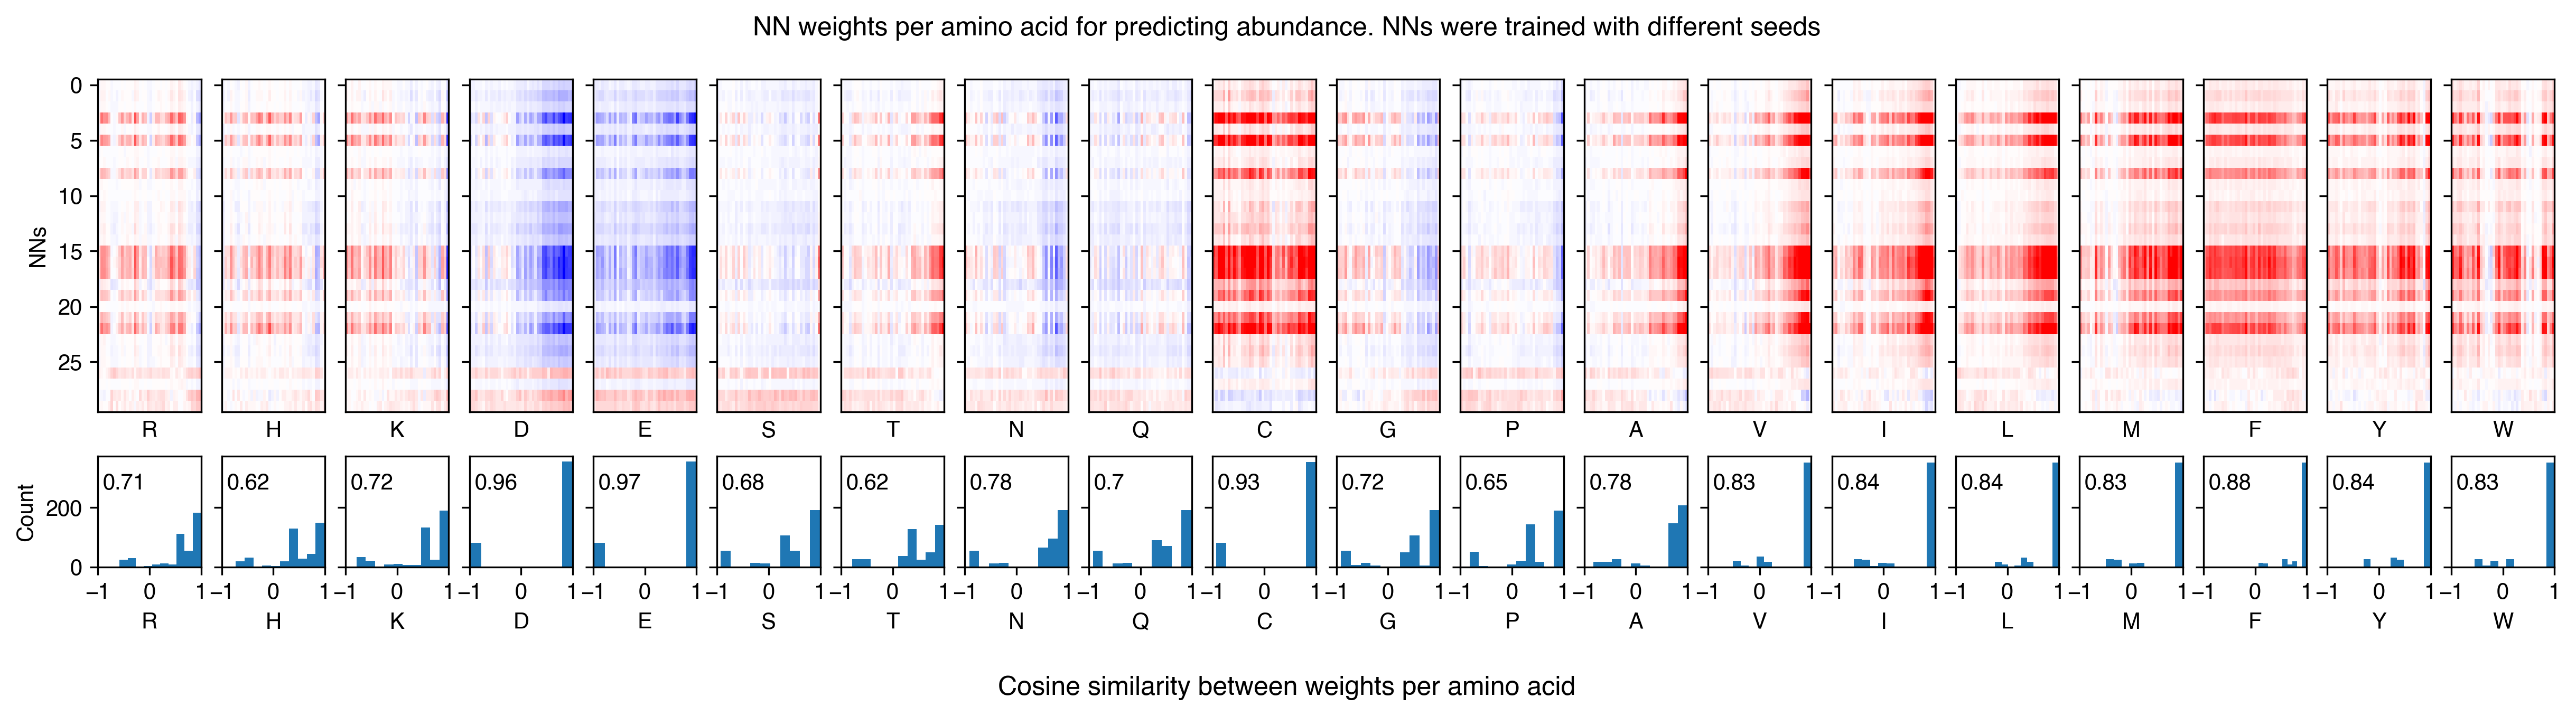

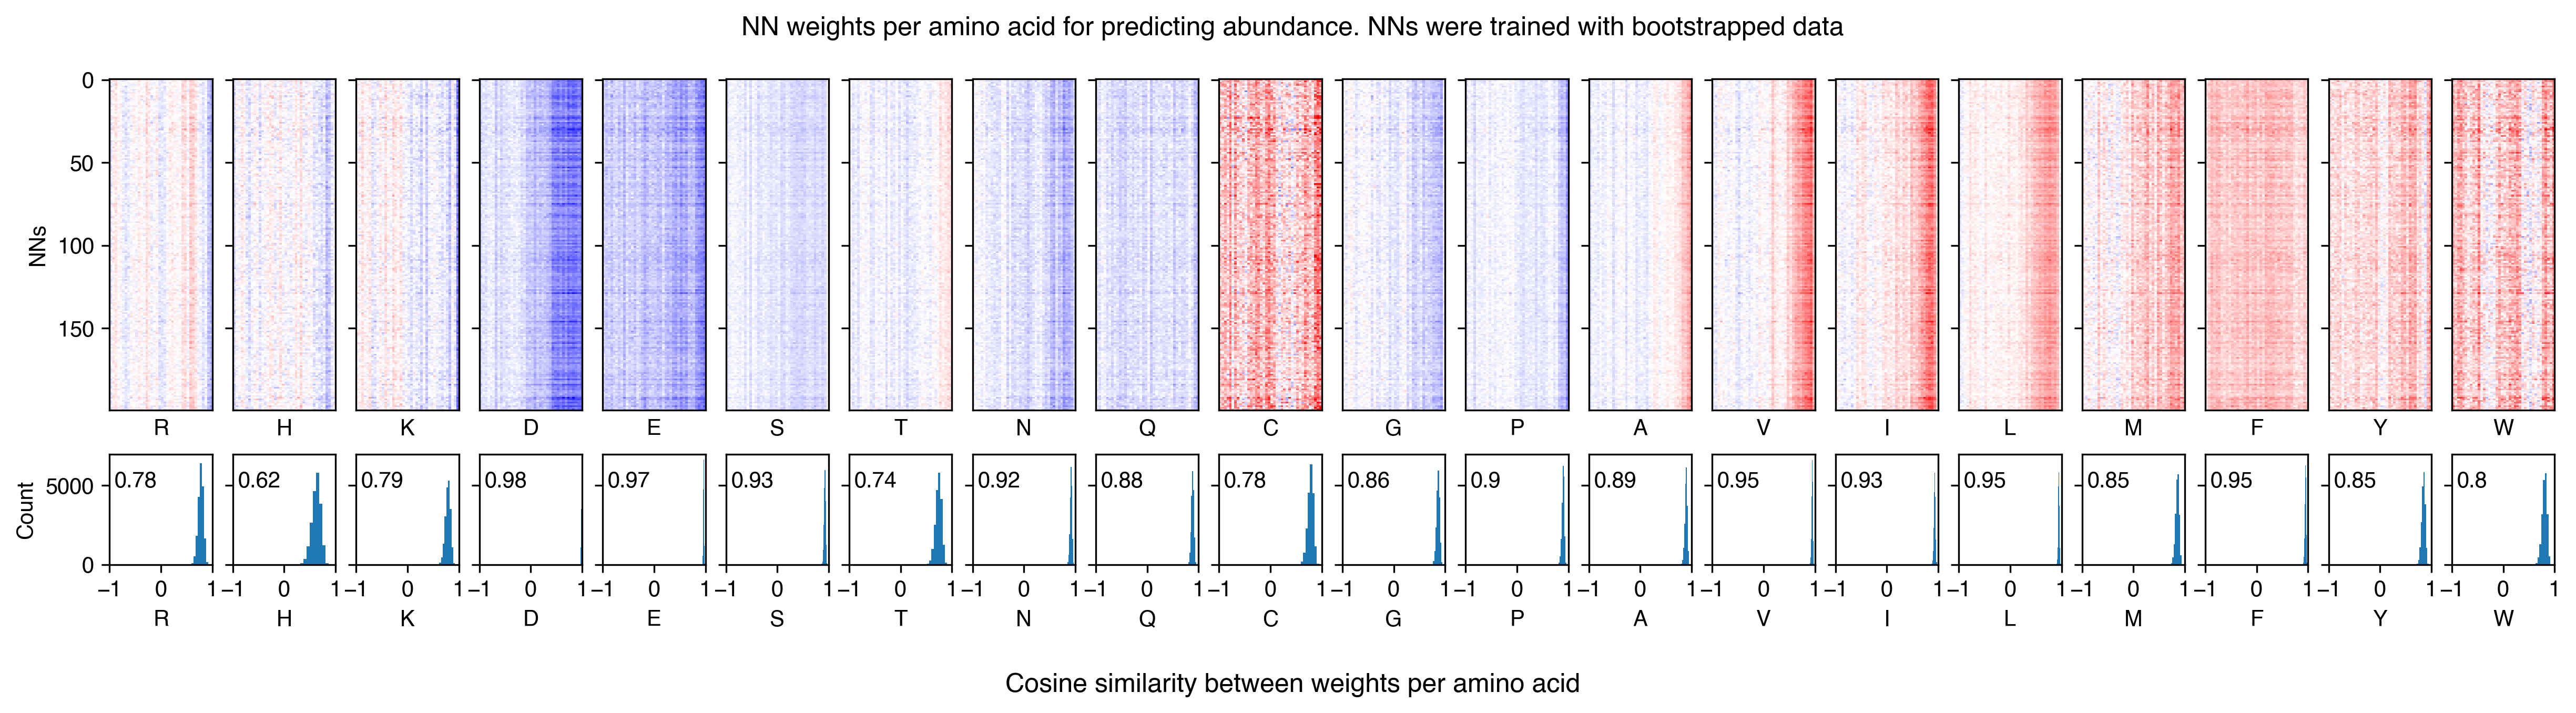

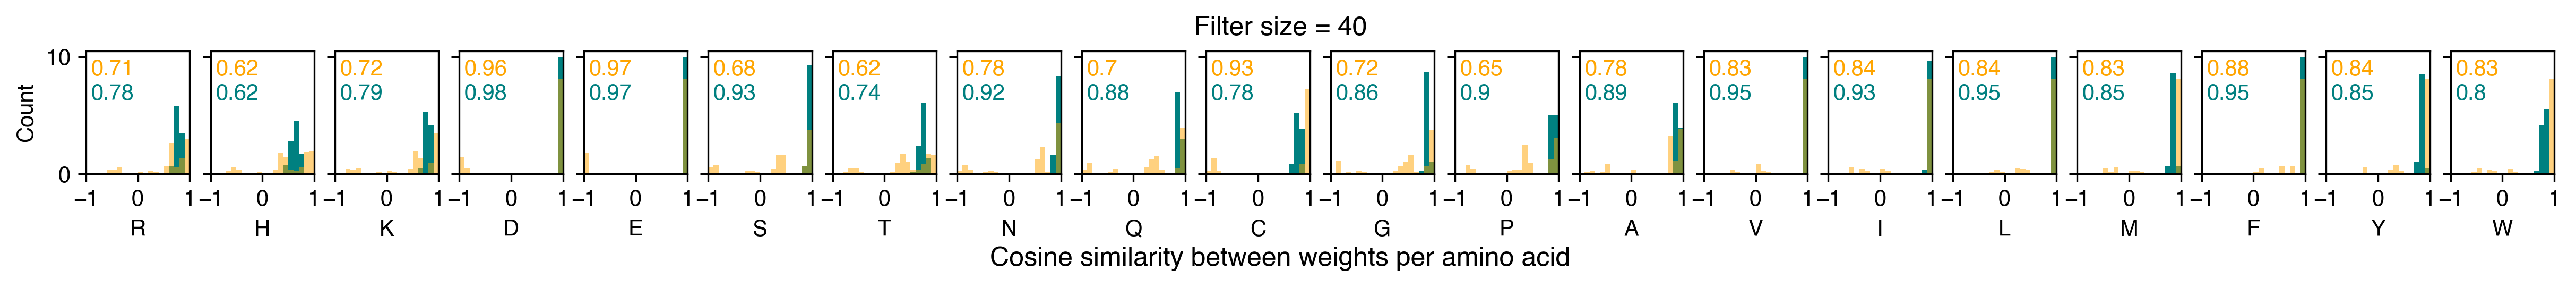

In [11]:
# TO DO: SAVE WEIGHTS so we don't have to reload every time
make_all_weight_heatmaps(40, simple_model_results, bootstrap_results)

100%|██████████| 30/30 [00:00<00:00, 825.01it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 1140.56it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


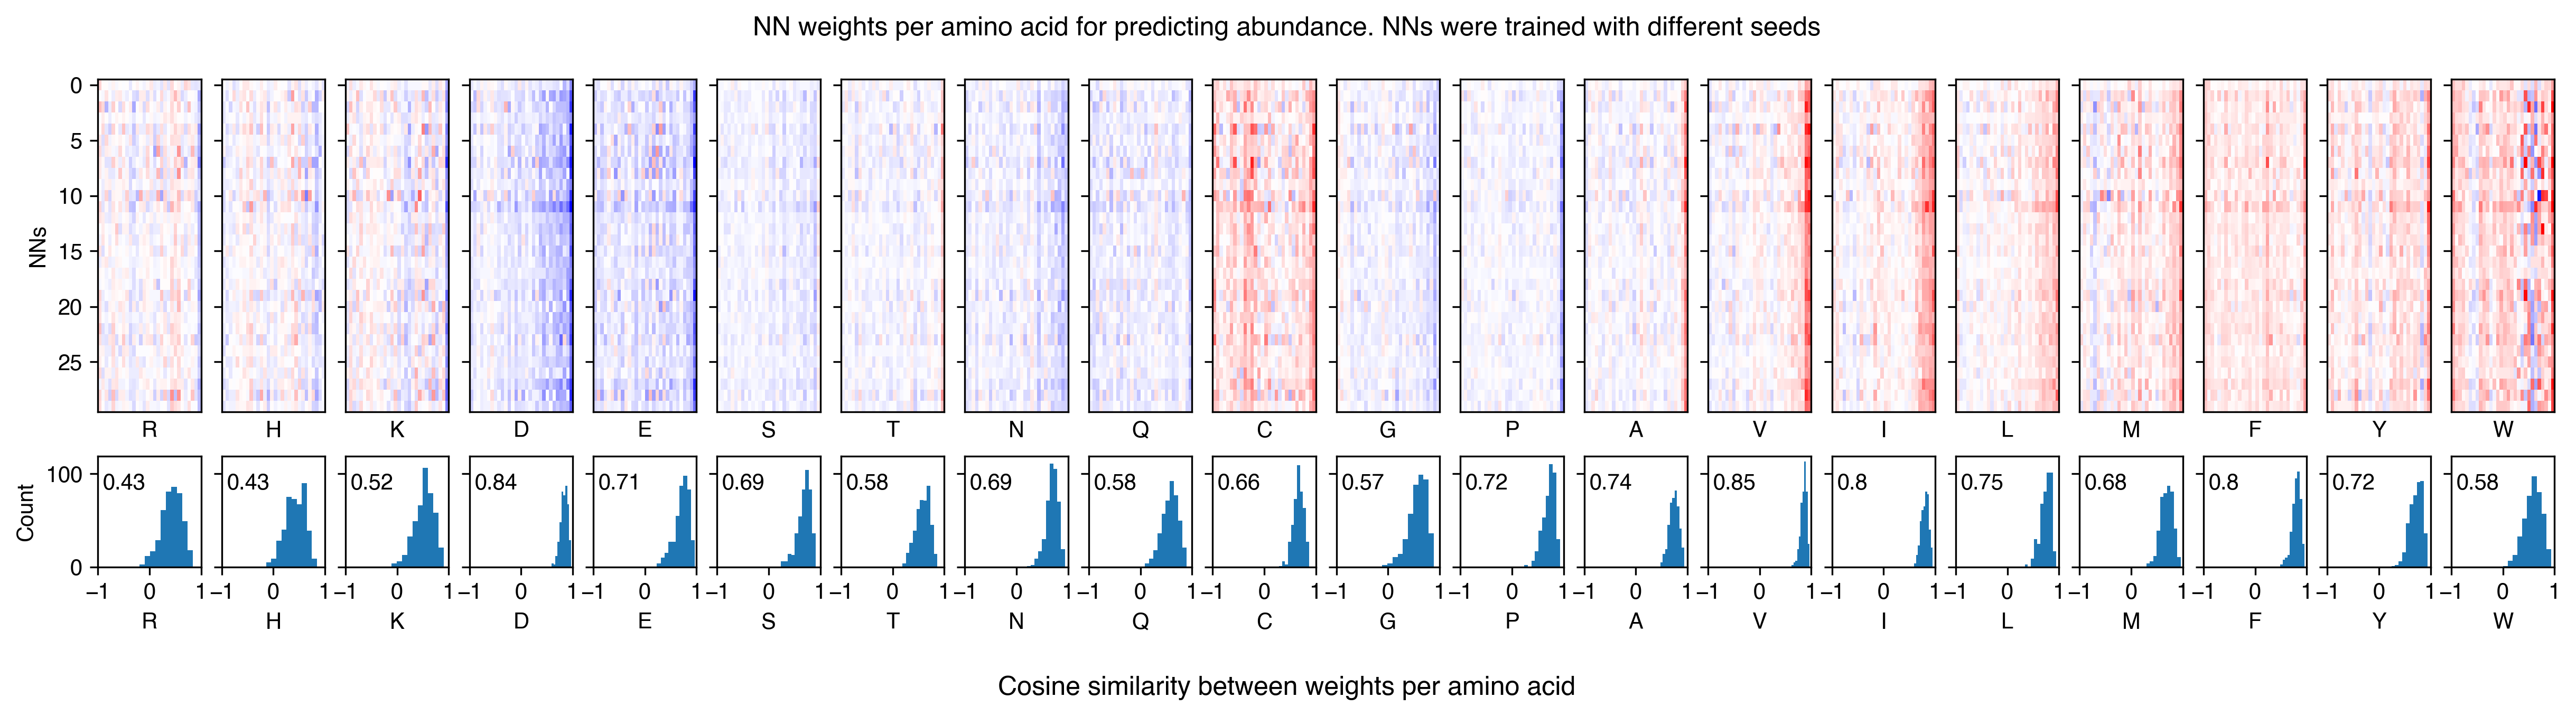

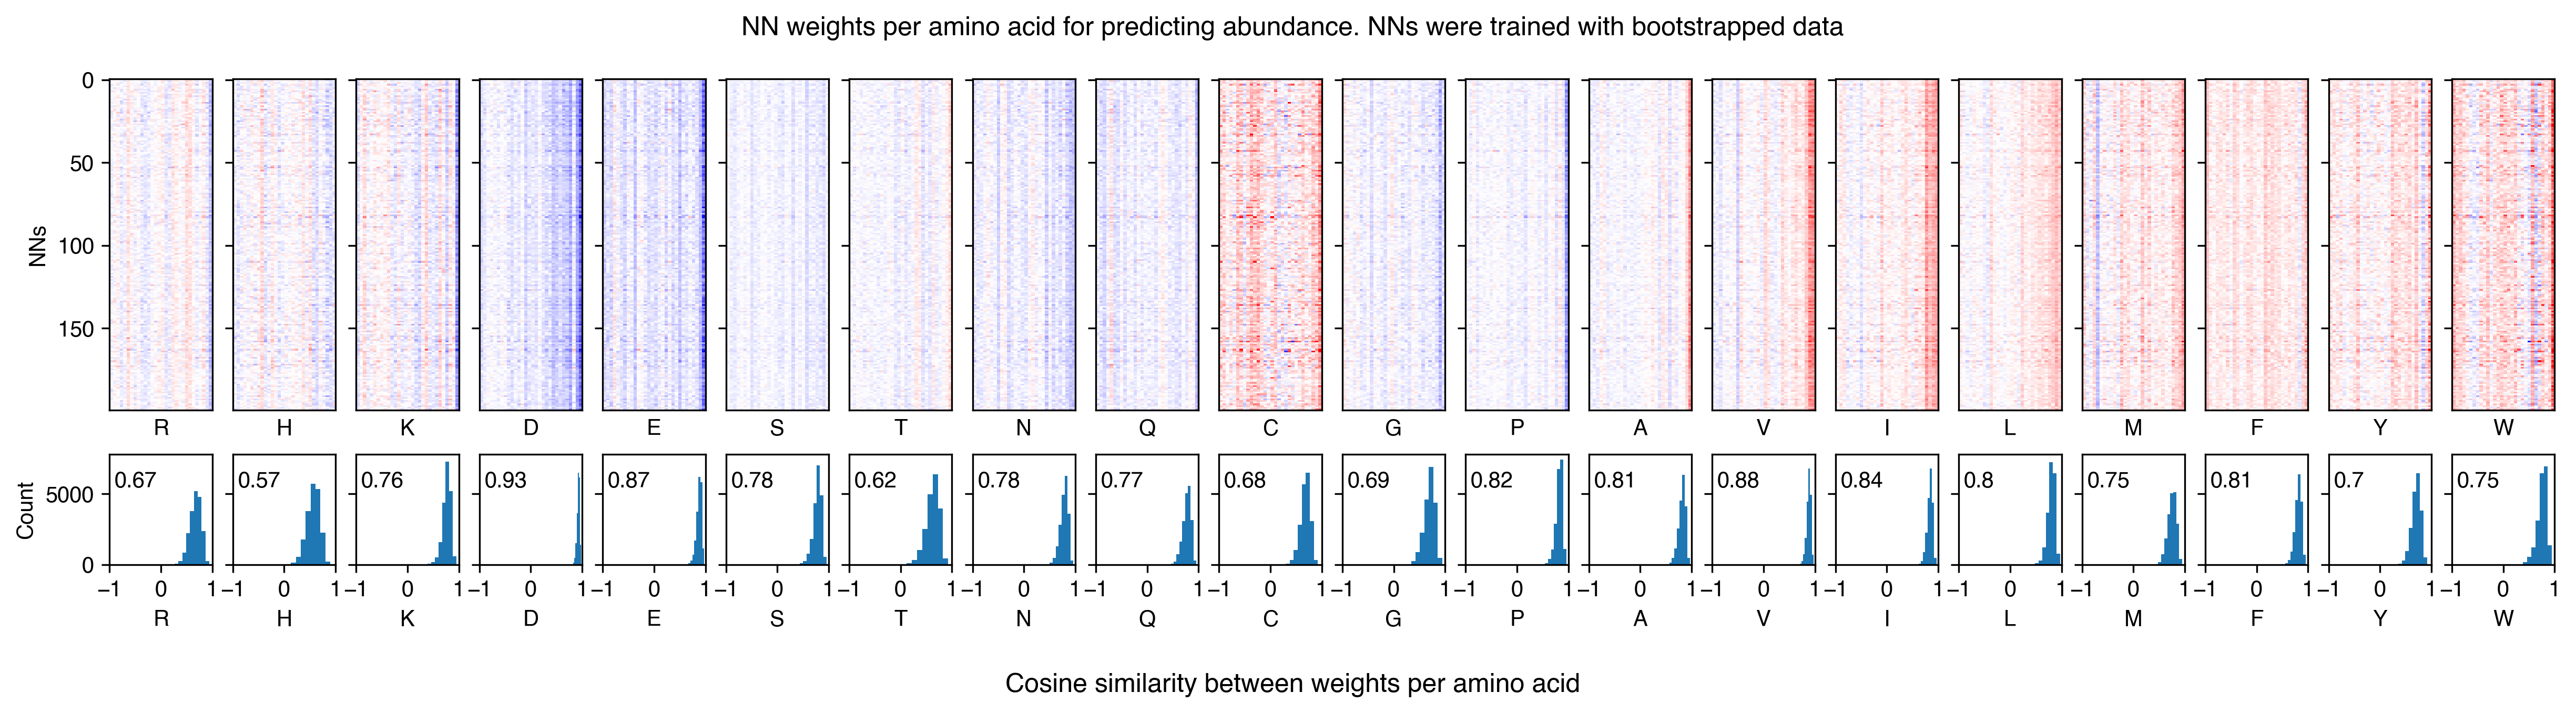

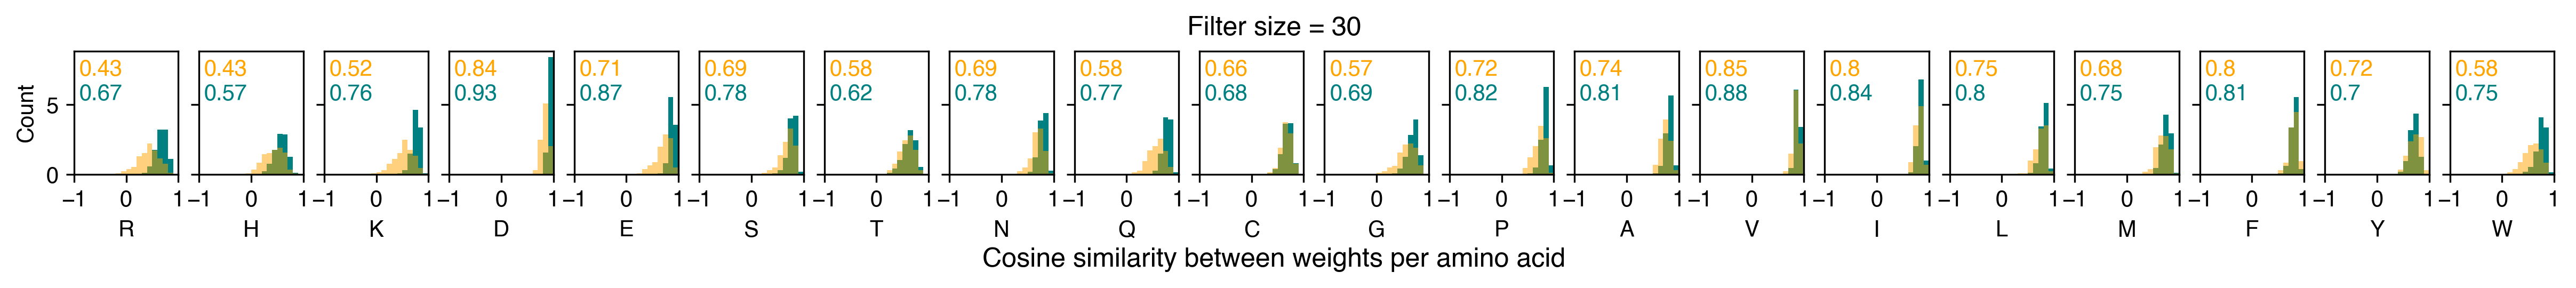

In [12]:
# TO DO: SAVE WEIGHTS so we don't have to reload every time
make_all_weight_heatmaps(30, simple_model_results, bootstrap_results)

100%|██████████| 30/30 [00:00<00:00, 683.56it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 1212.03it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


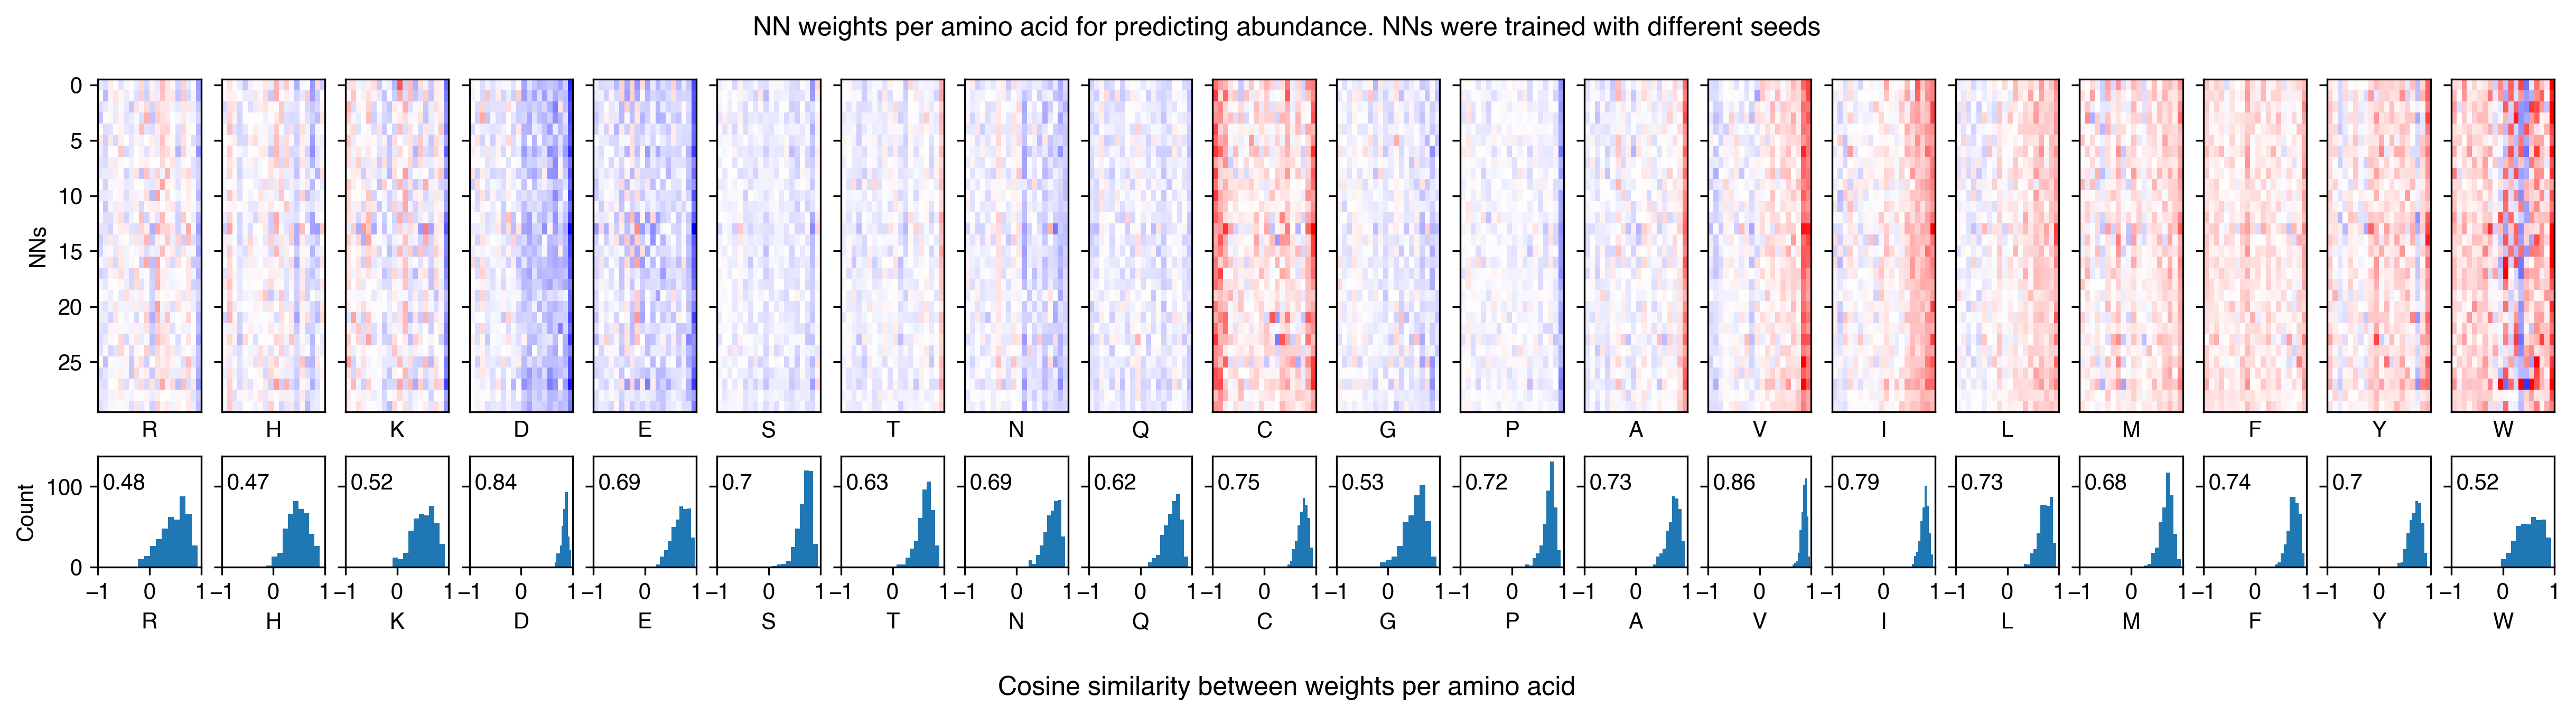

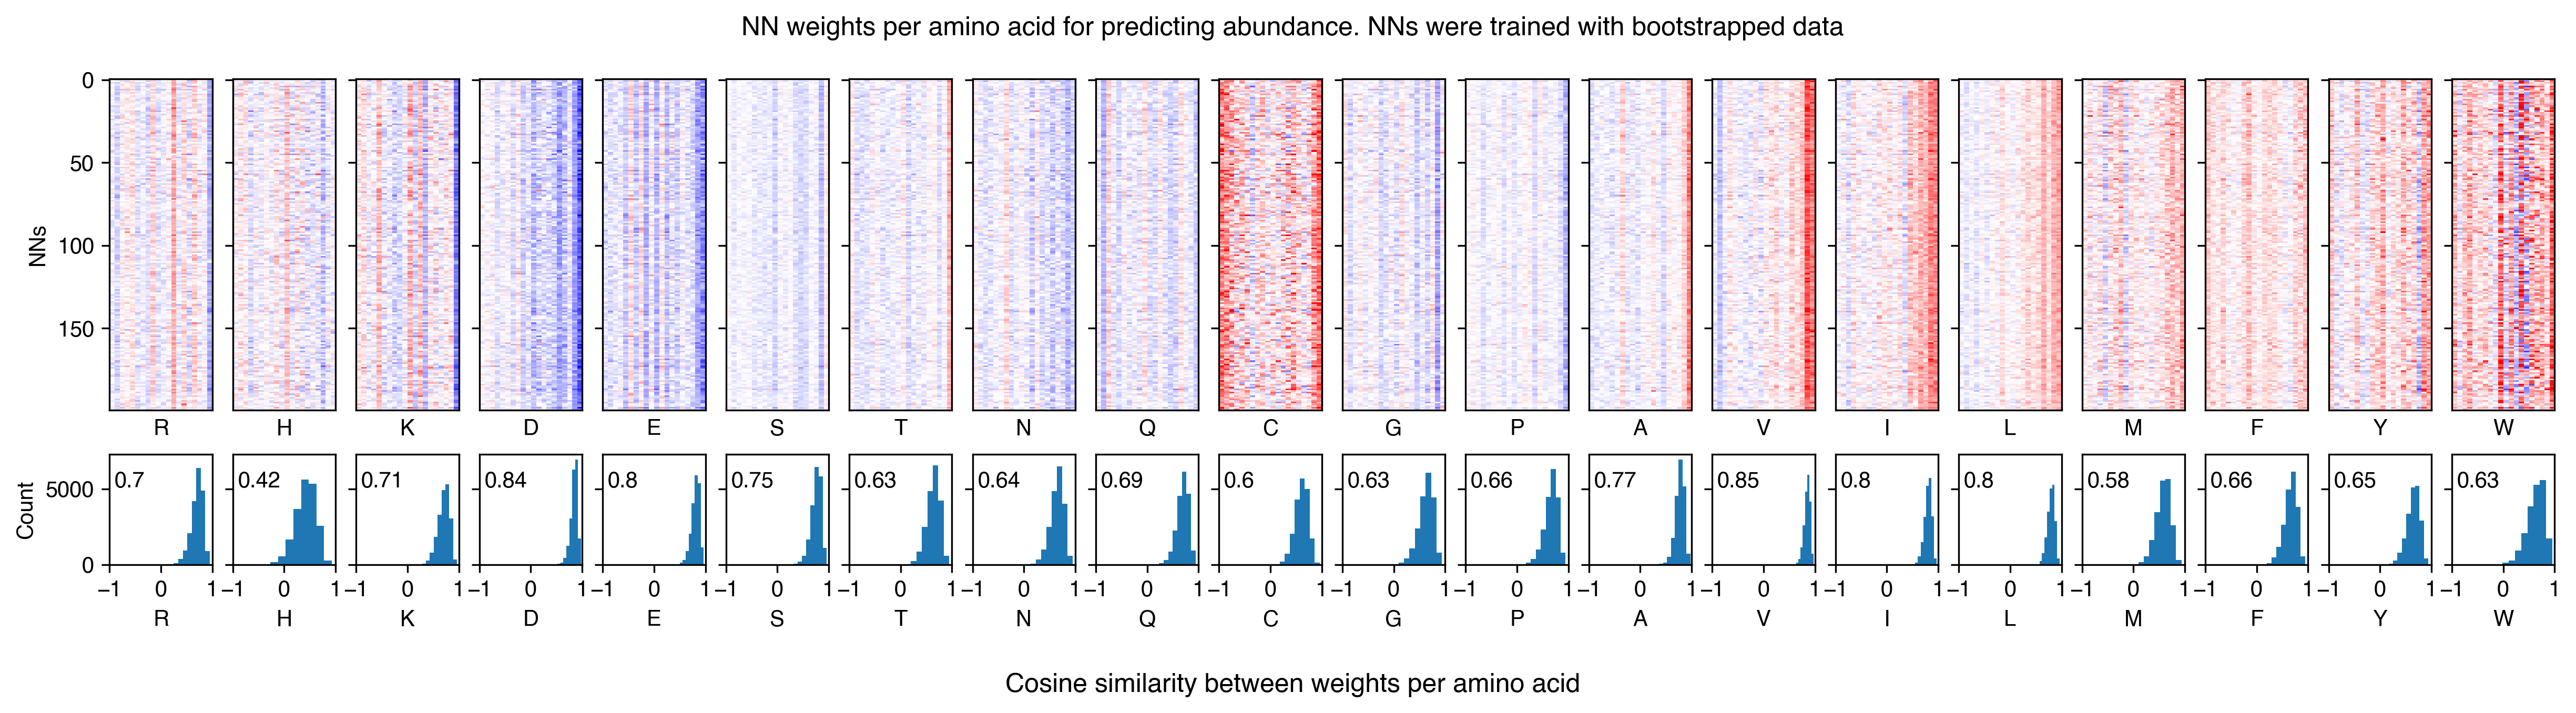

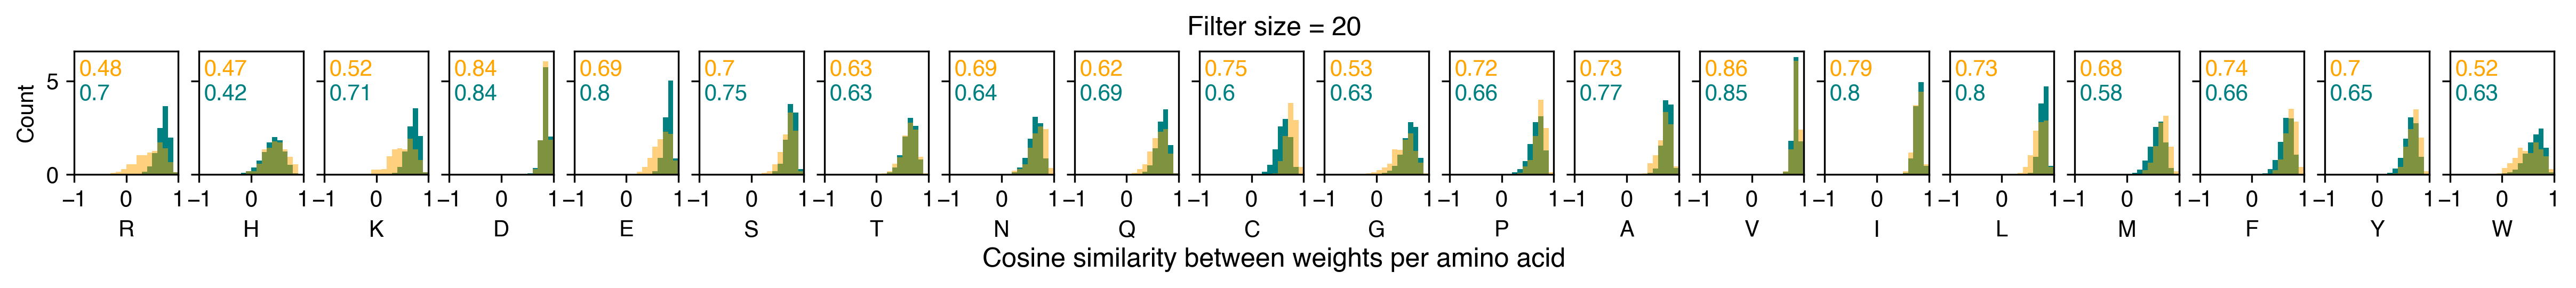

In [13]:
# TO DO: SAVE WEIGHTS so we don't have to reload every time
make_all_weight_heatmaps(20, simple_model_results, bootstrap_results)

100%|██████████| 30/30 [00:00<00:00, 597.66it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 1239.13it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


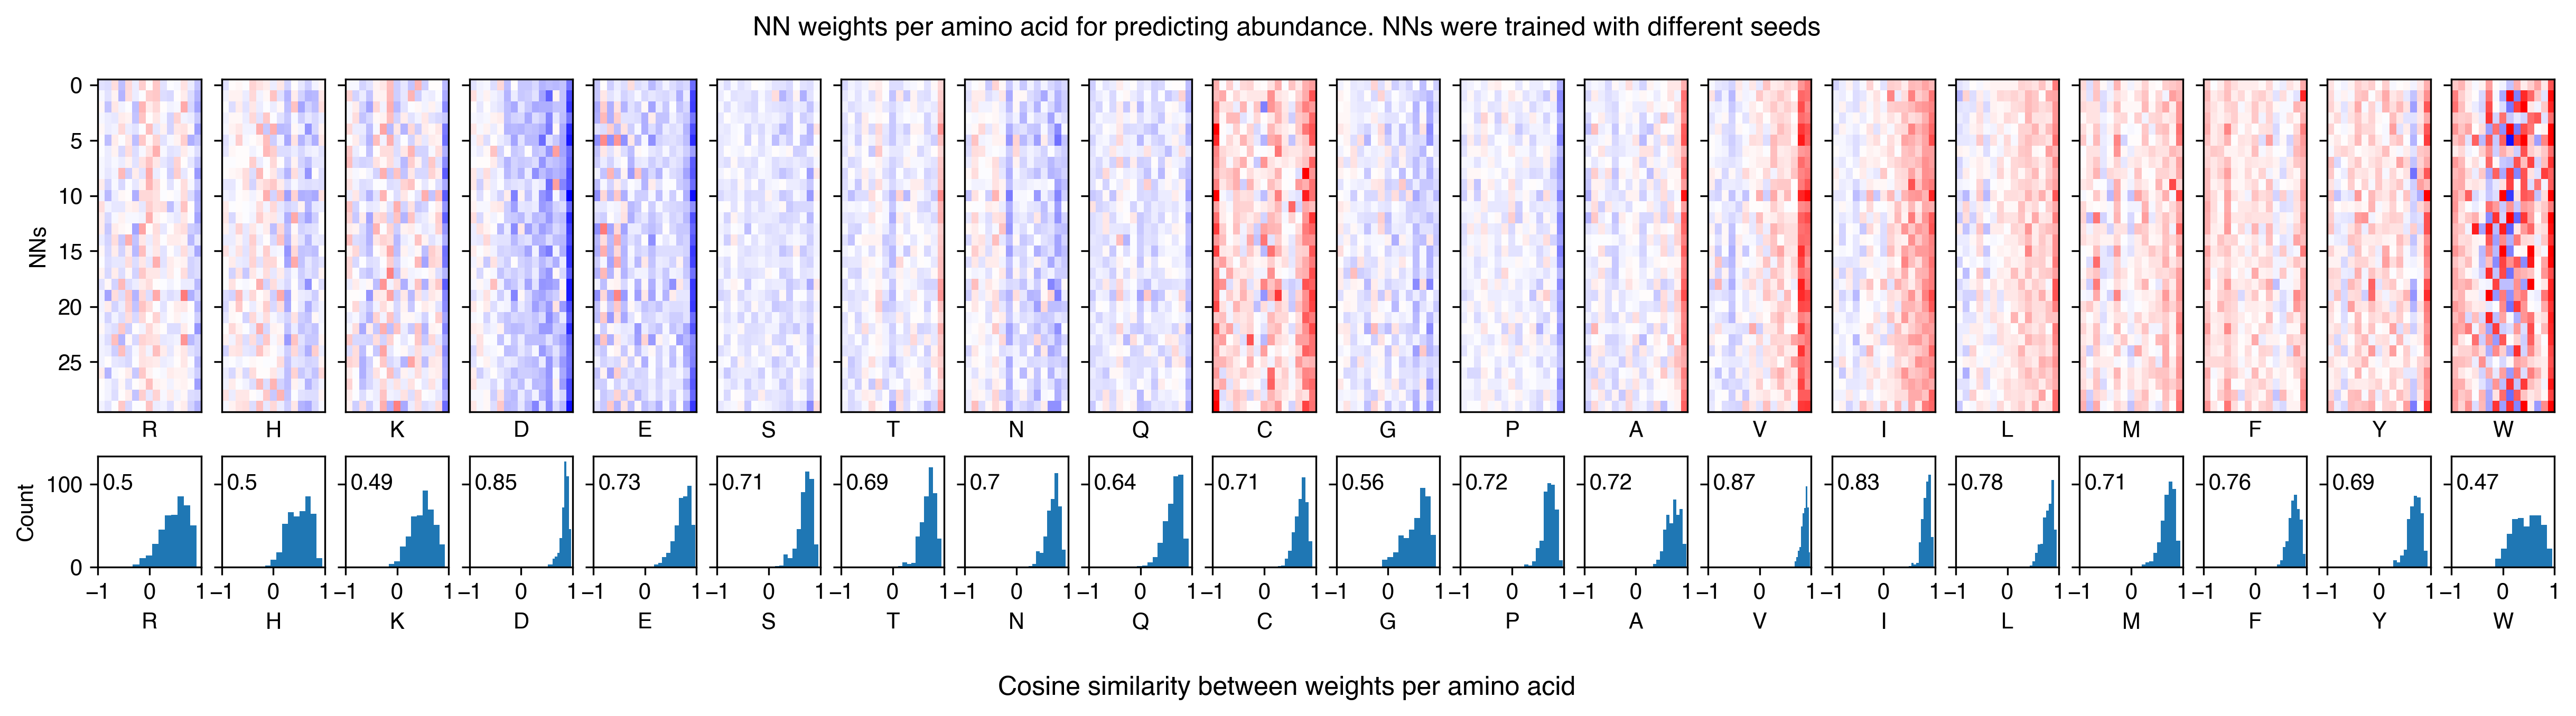

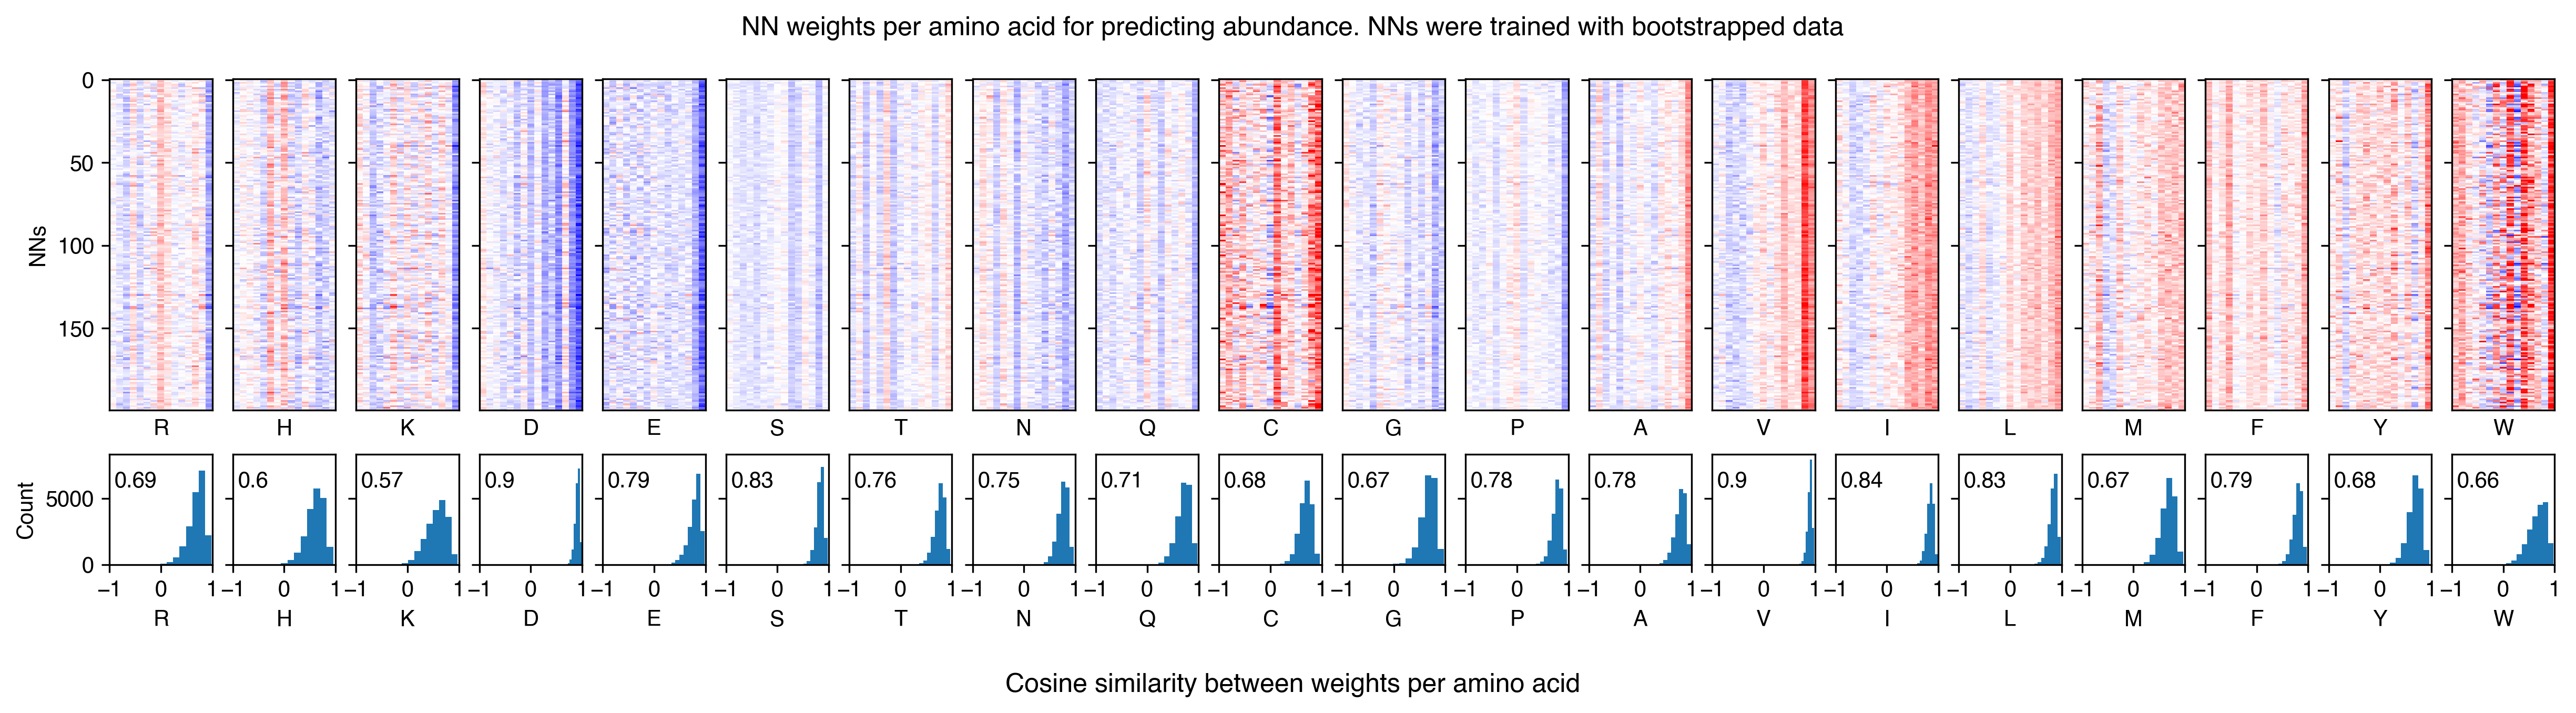

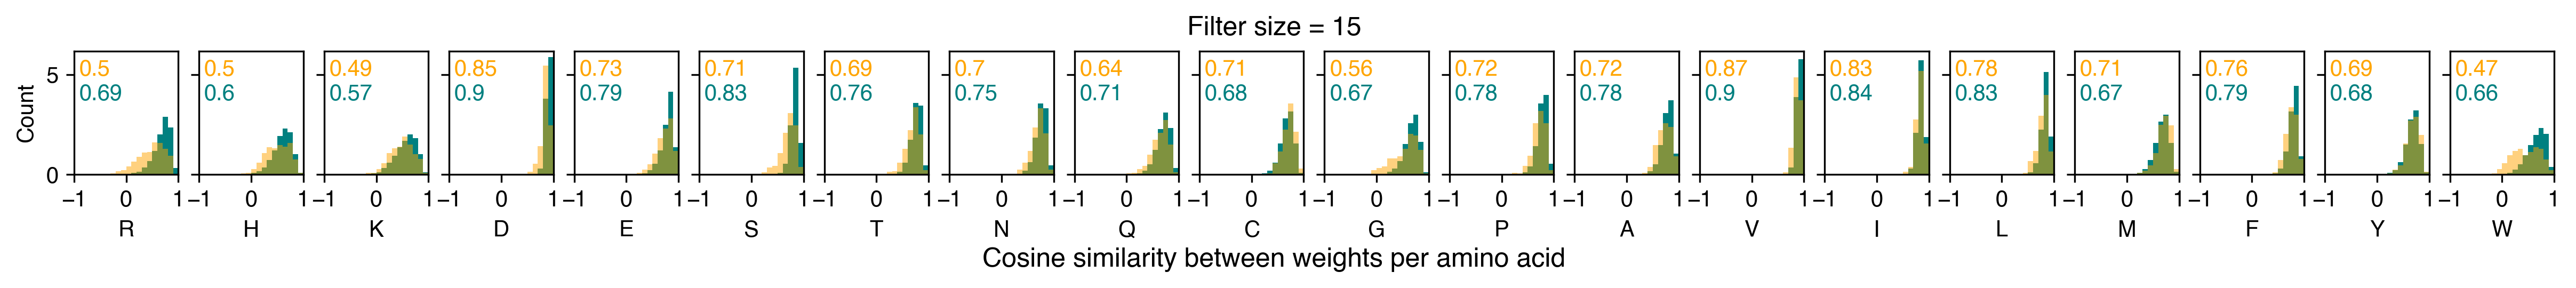

In [14]:
# TO DO: SAVE WEIGHTS so we don't have to reload every time
make_all_weight_heatmaps(15, simple_model_results, bootstrap_results)

100%|██████████| 30/30 [00:00<00:00, 722.99it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 1115.08it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


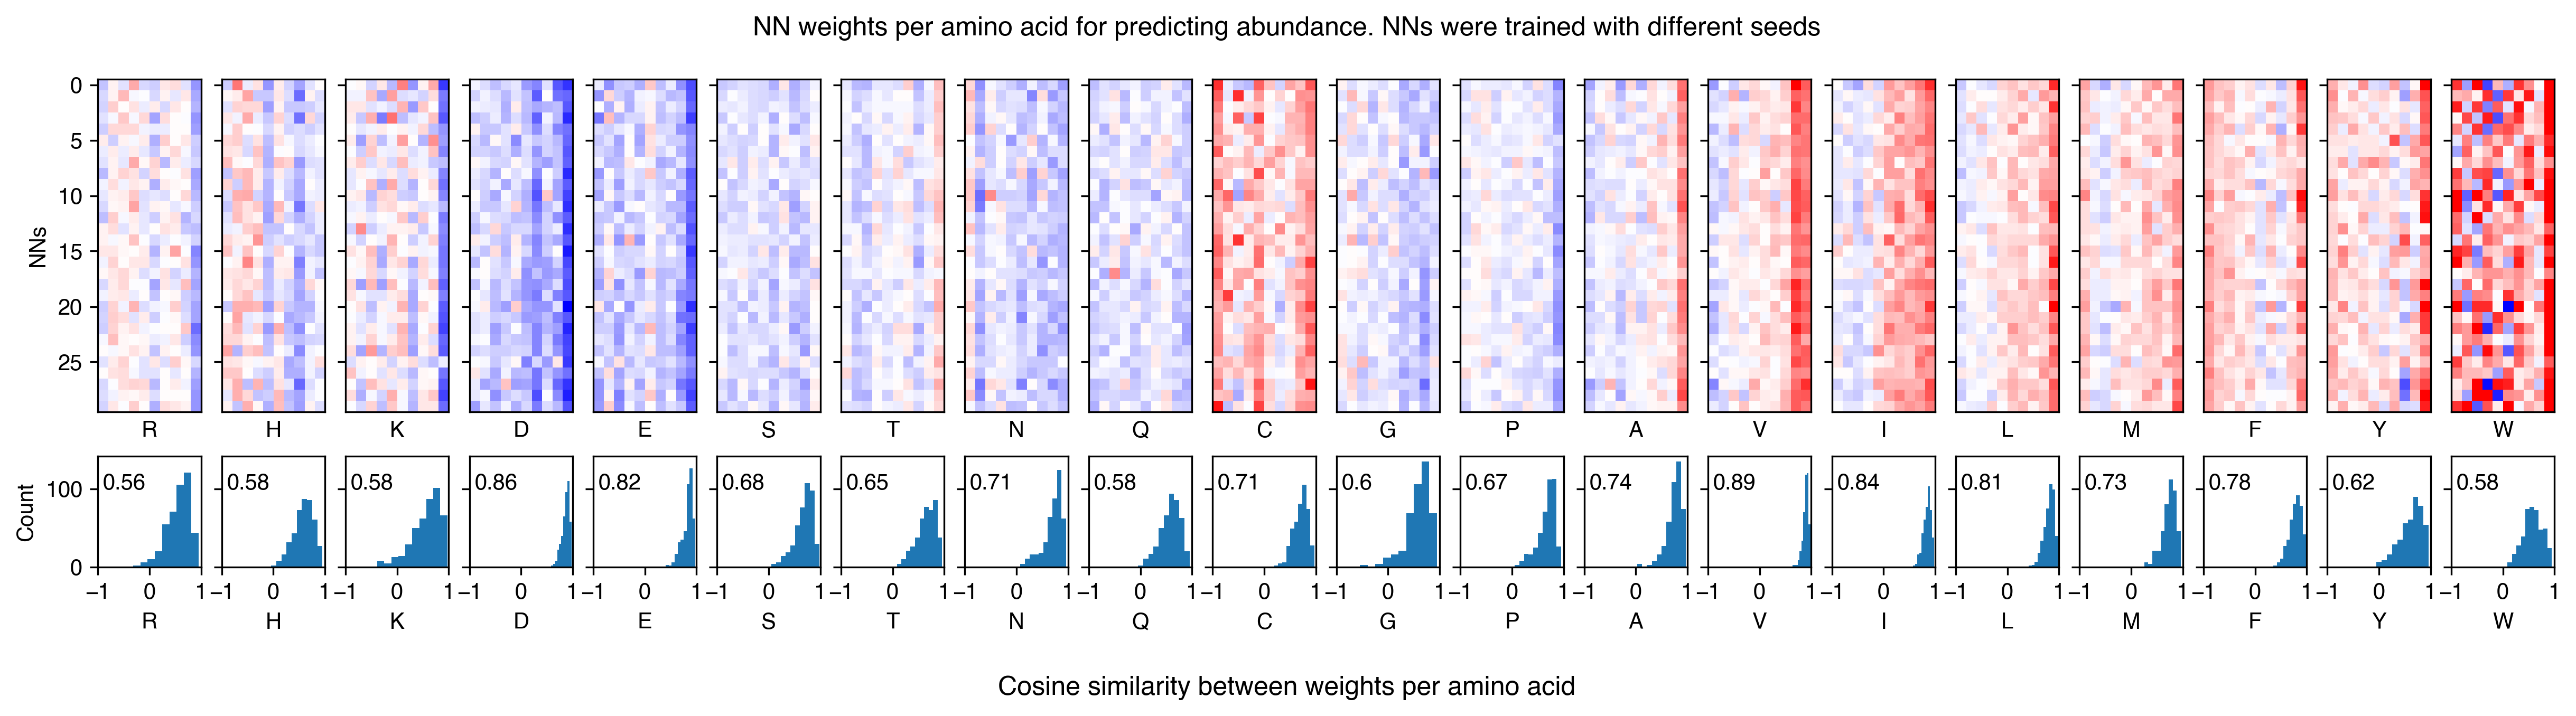

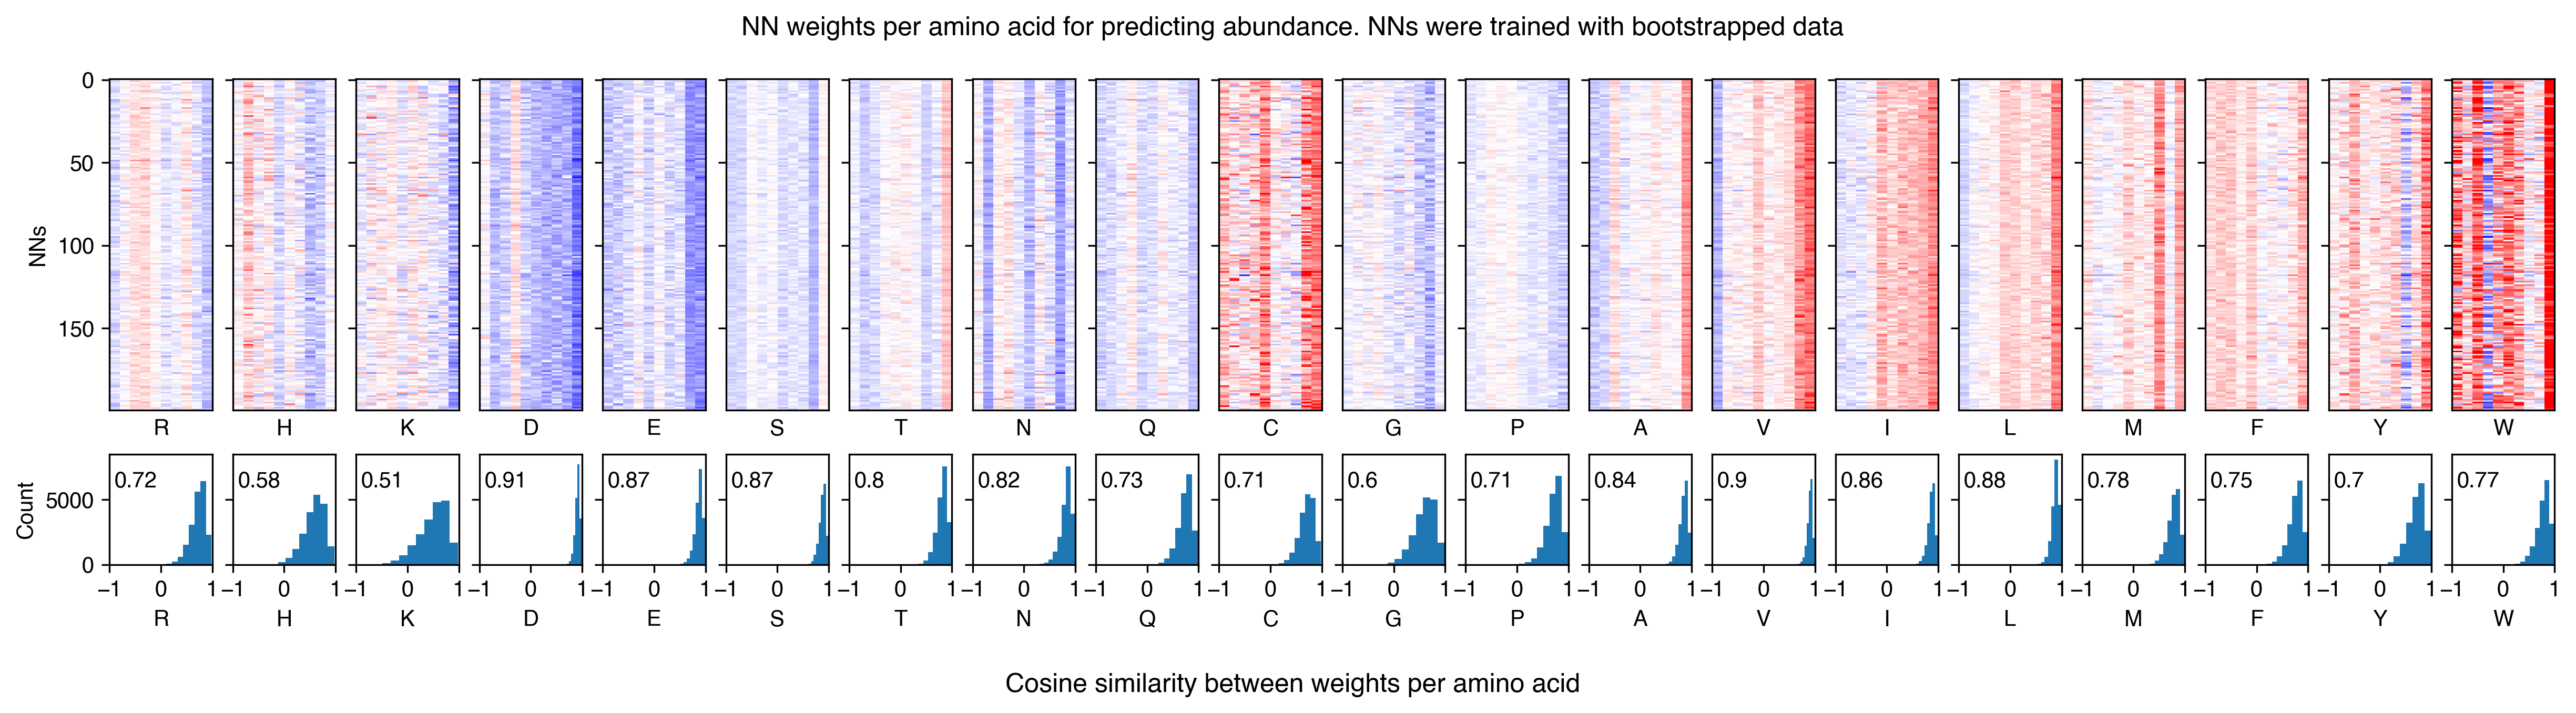

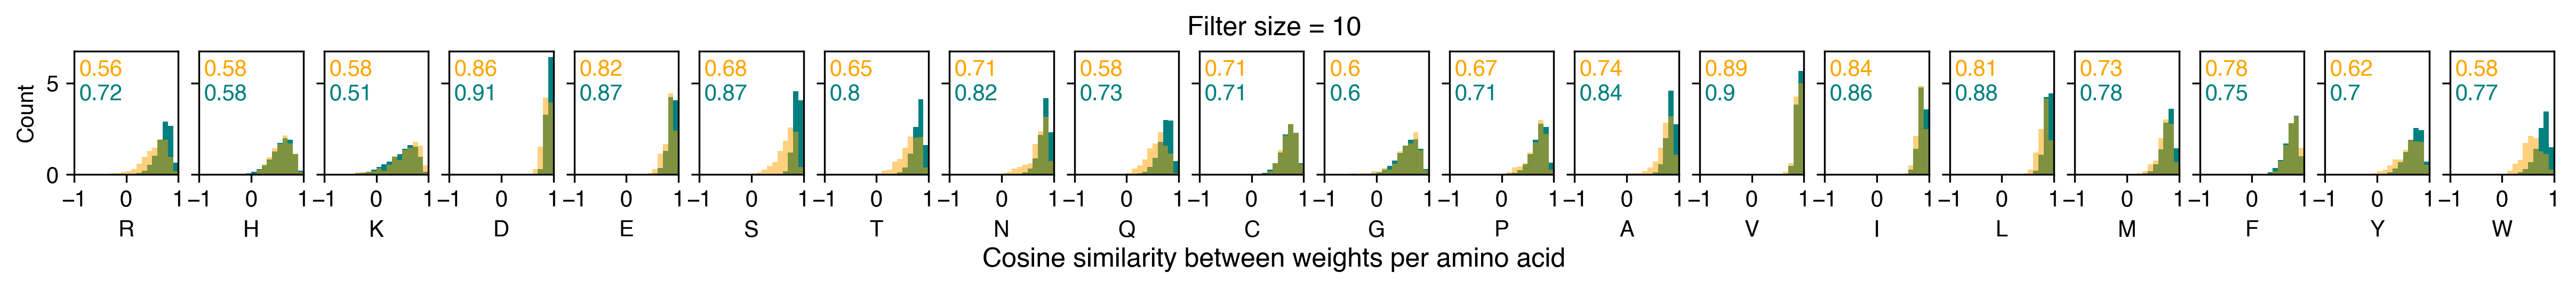

In [15]:
# TO DO: SAVE WEIGHTS so we don't have to reload every time
make_all_weight_heatmaps(10, simple_model_results, bootstrap_results)

100%|██████████| 30/30 [00:00<00:00, 636.85it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
100%|██████████| 200/200 [00:00<00:00, 1119.56it/s]
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


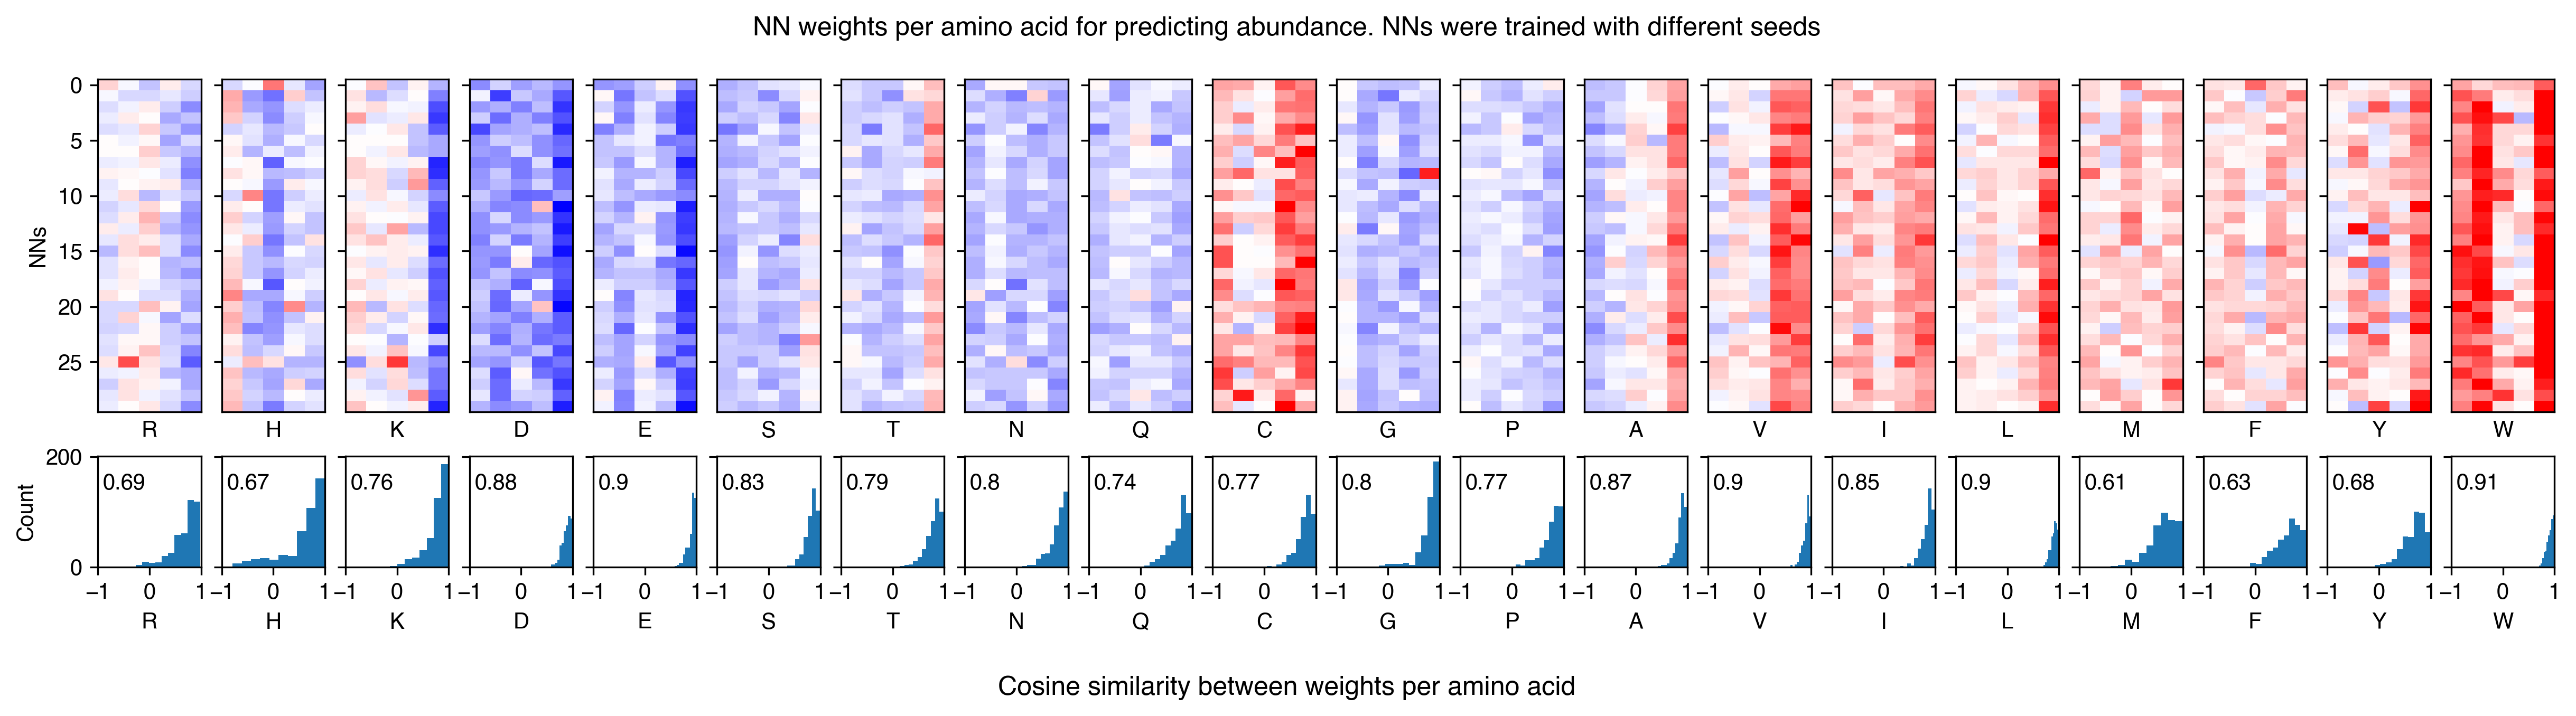

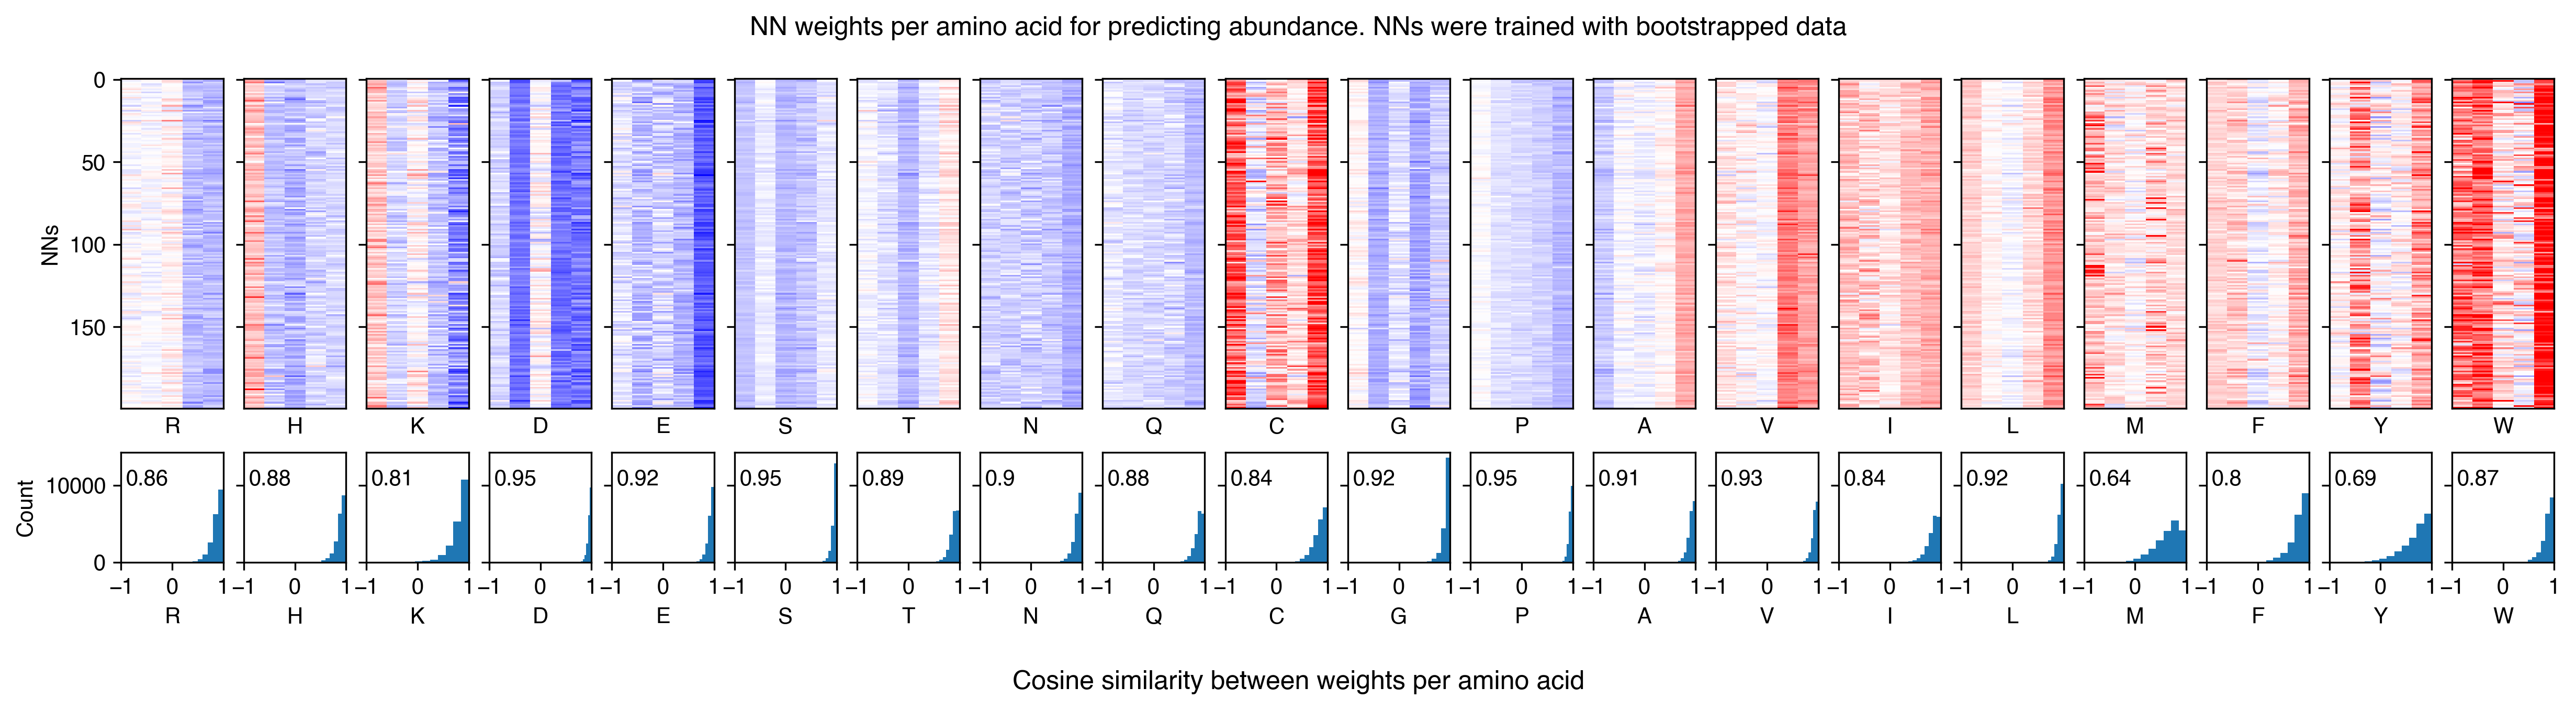

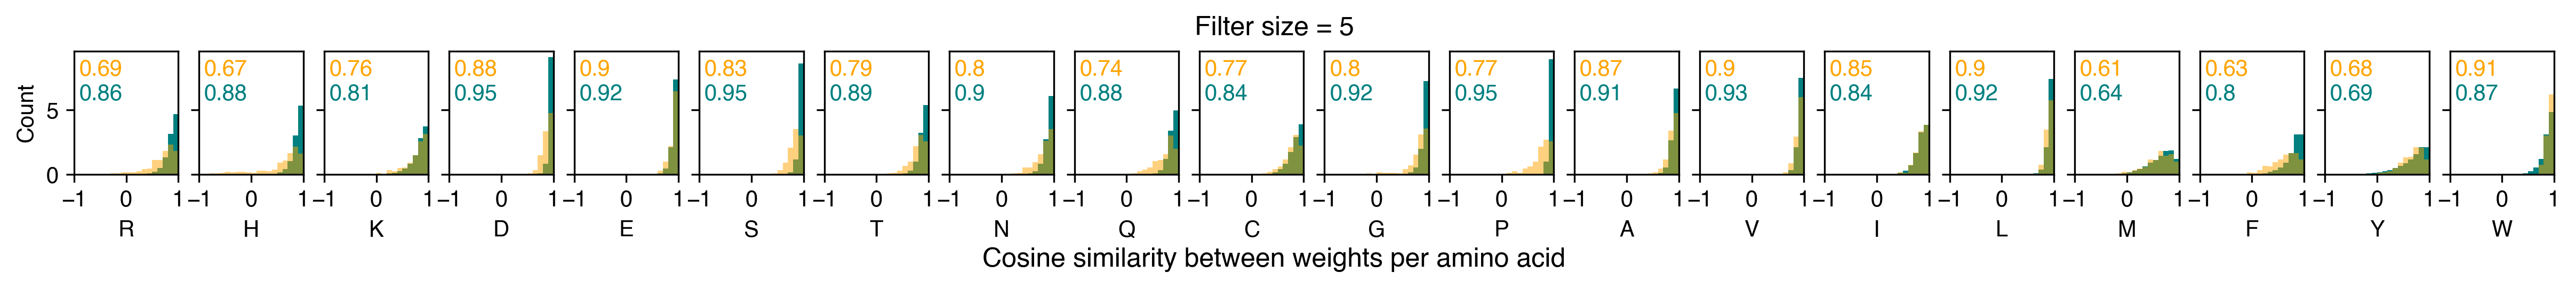

In [16]:
# TO DO: SAVE WEIGHTS so we don't have to reload every time
make_all_weight_heatmaps(5, simple_model_results, bootstrap_results)